In [41]:
# === cell 1 (fixed): setup, robust schema loader, prepare reference, define helpers ===
import os, json, gc, warnings
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
# -------------------- CONFIG --------------------
# Point to YOUR artifact_schema.json (the one you pasted)
SCHEMA_JSON = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/metrics_rpc_clamped/artifact_schema.json"
adata = sc.read_h5ad("/homes/olymp/julius.guntrum/tmp/Koeln/bone/bone_ref.h5ad")
# Where to write downstream analysis outputs
ANALYSIS_ROOT = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped"
os.makedirs(ANALYSIS_ROOT, exist_ok=True)
FIG_DIR = os.path.join(ANALYSIS_ROOT, "figures"); os.makedirs(FIG_DIR, exist_ok=True)

# Compute settings
N_PCS = 50
N_NEI = 20
LEIDEN_RES = 0.6
RANDOM_STATE = 0
N_JOBS = max(1, int(os.environ.get("OMP_NUM_THREADS", "8")))

# Try GPU UMAP if available
_USE_CUML = False
try:
    from cuml.manifold import UMAP as cuUMAP  # noqa: F401
    _USE_CUML = True
except Exception:
    _USE_CUML = False

sc.settings.verbosity = 2
warnings.filterwarnings("ignore", category=UserWarning)

# -------------------- SCHEMA / IO --------------------
def _coerce_schema(raw: dict):
    """
    Accepts either:
      - {
          "runs_index": {"path": "...", "columns": [...],
                         "reads_col_pattern": "...", "umis_col_pattern": "...",
                         "saturation_col_pattern": "..."},
          "metrics": {...}  # optional
        }
      - {
          "inputs": { "runs_index_csv": "...", ... },
          "outputs": {...}  # optional
        }
    """
    out = {}

    # branch 1: your artifact schema (with "runs_index")
    if isinstance(raw, dict) and "runs_index" in raw:
        ri = raw["runs_index"]
        out["runs_index_path"] = ri["path"]
        out["runs_index_columns"] = ri.get("columns", [])
        out["reads_col_pattern"] = ri.get("reads_col_pattern")
        out["umis_col_pattern"] = ri.get("umis_col_pattern")
        out["saturation_col_pattern"] = ri.get("saturation_col_pattern")
        if "metrics" in raw:
            out["metrics_path"] = raw["metrics"]["path"]
            out["metrics_columns"] = raw["metrics"].get("columns", [])
        return out

    # branch 2: my analysis schema variant (with "inputs": {"runs_index_csv": ...})
    if isinstance(raw, dict) and "inputs" in raw and isinstance(raw["inputs"], dict):
        inp = raw["inputs"]
        if "runs_index_csv" in inp:  # ← newer key
            out["runs_index_path"] = inp["runs_index_csv"]
        elif "runs_index" in inp:   # ← older key
            out["runs_index_path"] = inp["runs_index"]
        else:
            raise KeyError("Schema 'inputs' present but missing 'runs_index_csv' or 'runs_index'.")

        # optional patterns if present
        out["reads_col_pattern"] = inp.get("reads_col_pattern")
        out["umis_col_pattern"] = inp.get("umis_col_pattern")
        out["saturation_col_pattern"] = inp.get("saturation_col_pattern")

        if "outputs" in raw and isinstance(raw["outputs"], dict):
            outs = raw["outputs"]
            out["metrics_path"] = outs.get("clustering_metrics_csv")
        return out

    # helpful debug
    raise KeyError(f"Could not find runs_index path. Top-level keys: {list(raw.keys())}")

def load_schema(schema_path: str):
    with open(schema_path, "r") as f:
        raw = json.load(f)
    sch = _coerce_schema(raw)
    if not os.path.exists(sch["runs_index_path"]):
        raise FileNotFoundError(f"runs_index not found: {sch['runs_index_path']}")
    return sch

def read_runs_index(schema: dict) -> pd.DataFrame:
    """Expect columns: ['target_rpc','h5ad','p_keep'] in your CSV."""
    path = schema["runs_index_path"]
    df = pd.read_csv(path)

    # normalize: require 'target_rpc' and 'h5ad'
    if "target_rpc" not in df.columns:
        cand = [c for c in df.columns if "target" in c.lower() and "rpc" in c.lower()]
        assert cand, f"No 'target_rpc' column in {path}"
        df = df.rename(columns={cand[0]: "target_rpc"})
    if "h5ad" not in df.columns:
        cand = [c for c in df.columns if "h5ad" in c.lower()]
        assert cand, f"No 'h5ad' column in {path}"
        df = df.rename(columns={cand[0]: "h5ad"})
    if "p_keep" not in df.columns:
        df["p_keep"] = np.nan

    df["target_rpc"] = pd.to_numeric(df["target_rpc"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["target_rpc", "h5ad"]).reset_index(drop=True)
    df["h5ad"] = df["h5ad"].astype(str)
    df = df.sort_values("target_rpc").reset_index(drop=True)
    return df

def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _compute_hvgs_on_ref(ad_ref, n_top=3000, layer="lognorm"):
    sc.pp.highly_variable_genes(ad_ref, n_top_genes=n_top, flavor="seurat", layer=layer)
    if "highly_variable" not in ad_ref.var.columns or ad_ref.var["highly_variable"].sum() == 0:
        raise RuntimeError("Failed to compute HVGs on reference.")
    return ad_ref.var["highly_variable"].values

def _embed_and_cluster(ad, hvgs_mask=None, layer="lognorm",
                       n_pcs=N_PCS, n_neighbors=N_NEI,
                       leiden_res=LEIDEN_RES, random_state=RANDOM_STATE, n_jobs=N_JOBS):
    if hvgs_mask is not None:
        ad.var["highly_variable"] = hvgs_mask
    use_hvg = "highly_variable" in ad.var.columns and ad.var["highly_variable"].any()
    sc.pp.pca(ad, n_comps=n_pcs, zero_center=True, svd_solver="arpack",
              use_highly_variable=use_hvg, layer=layer, random_state=random_state)
    sc.pp.neighbors(ad, n_neighbors=n_neighbors, n_pcs=n_pcs, method="umap",
                    use_rep="X_pca", random_state=random_state)
    if _USE_CUML:
        try:
            from cuml.manifold import UMAP as cuUMAP
            umap = cuUMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.5,
                          random_state=random_state, verbose=False)
            emb = umap.fit_transform(ad.obsm["X_pca"])
            ad.obsm["X_umap"] = np.asarray(emb)
        except Exception:
            sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
    else:
        sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
    sc.tl.leiden(ad,flavor ="igraph", resolution=leiden_res, random_state=random_state, key_added="leiden")
    return ad

# -------------------- LOAD SCHEMA & REFERENCE --------------------
schema = load_schema(SCHEMA_JSON)
runs_df = read_runs_index(schema)
print(f"[loaded] {len(runs_df)} subsample runs from index: {schema['runs_index_path']}")
print(runs_df.head())

# Choose reference as the largest target_rpc
ref_row = runs_df.iloc[runs_df["target_rpc"].astype(int).argmax()]
REF_H5AD = ref_row["h5ad"]
if not os.path.exists(REF_H5AD):
    raise FileNotFoundError(f"Reference h5ad not found: {REF_H5AD}")

ad_ref = sc.read_h5ad(REF_H5AD)
print(f"[ref] {ad_ref.n_obs:,} cells × {ad_ref.n_vars:,} genes")
_ensure_lognorm(ad_ref, layer="lognorm")
hvg_mask = _compute_hvgs_on_ref(ad_ref, n_top=3000, layer="lognorm")
ad_ref = _embed_and_cluster(ad_ref, hvgs_mask=hvg_mask, layer="lognorm")

# keep a stable label name for downstream
ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden"].astype(str).values

# Save prepared reference
REF_OUT = os.path.join(ANALYSIS_ROOT, "reference_with_embedding.h5ad")
ad_ref.write_h5ad(REF_OUT)
print(f"[save] reference with clustering → {REF_OUT}")

# Persist a small analysis schema for next cells
analysis_schema = {
    "inputs": {
        "artifact_schema_json": SCHEMA_JSON,
        "runs_index_csv": schema["runs_index_path"],
        "reference_h5ad": REF_OUT,
        "reads_col_pattern": schema.get("reads_col_pattern"),
        "umis_col_pattern": schema.get("umis_col_pattern"),
        "saturation_col_pattern": schema.get("saturation_col_pattern"),
    },
    "params": {
        "n_pcs": N_PCS, "n_neighbors": N_NEI, "leiden_res": LEIDEN_RES,
        "random_state": RANDOM_STATE, "n_jobs": N_JOBS, "use_cuml_umap": bool(_USE_CUML),
    },
    "outputs": {
        "clustering_metrics_csv": os.path.join(ANALYSIS_ROOT, "clustering_stability_metrics.csv"),
        "deg_metrics_csv": os.path.join(ANALYSIS_ROOT, "deg_stability_metrics.csv"),
        "car_deg_traces_csv": os.path.join(ANALYSIS_ROOT, "car_deg_traces.csv"),
        "figures": {
            "stability_panel_png": os.path.join(FIG_DIR, "stability_vs_reads.png"),
            "car_deg_traces_png": os.path.join(FIG_DIR, "car_deg_traces.png"),
        },
    },
}
with open(os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json"), "w") as f:
    json.dump(analysis_schema, f, indent=2)
print(f"[save] analysis schema → {os.path.join(ANALYSIS_ROOT, 'analysis_artifact_schema.json')}")

gc.collect()
# READY for the next cell


[loaded] 10 subsample runs from index: /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/runs_rpc_clamped/subsample_runs_index.csv
   target_rpc                                               h5ad    p_keep
0           1  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.000642
1         174  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.111675
2         347  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.222708
3         520  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.333741
4         693  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.444774
[ref] 51,713 cells × 38,645 genes
extracting highly variable genes
    finished (0:00:00)
computing PCA
    with n_comps=50


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:01)
computing neighbors
    finished (0:00:08)
computing UMAP
    finished (0:01:02)
running Leiden clustering
    finished (0:00:03)
[save] reference with clustering → /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped/reference_with_embedding.h5ad
[save] analysis schema → /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped/analysis_artifact_schema.json


824

In [13]:
# === cell 2 (fixed): clustering/DE stability + CAR+ trajectories over total reads ===
import os, json, warnings, gc
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from scipy.sparse import issparse
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment  # <- use SciPy Hungarian
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# --------- locate the analysis schema produced in Cell 1 ----------
ANALYSIS_ROOT = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped"
ANALYSIS_SCHEMA_JSON = os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json")
assert os.path.exists(ANALYSIS_SCHEMA_JSON), f"Missing analysis schema: {ANALYSIS_SCHEMA_JSON}"

with open(ANALYSIS_SCHEMA_JSON, "r") as f:
    ASCH = json.load(f)

RUNS_CSV = ASCH["inputs"]["runs_index_csv"]
REF_H5AD = ASCH["inputs"]["reference_h5ad"]
READS_COL_PATTERN = ASCH["inputs"]["reads_col_pattern"]
UMIS_COL_PATTERN  = ASCH["inputs"]["umis_col_pattern"]
SAT_COL_PATTERN   = ASCH["inputs"]["saturation_col_pattern"]

OUT_CLUSTERING_CSV = ASCH["outputs"]["clustering_metrics_csv"]
OUT_DEG_CSV        = ASCH["outputs"]["deg_metrics_csv"]
OUT_CARTRACES_CSV  = ASCH["outputs"]["car_deg_traces_csv"]
FIG_STAB           = ASCH["outputs"]["figures"]["stability_panel_png"]
FIG_CAR            = ASCH["outputs"]["figures"]["car_deg_traces_png"]

os.makedirs(os.path.dirname(OUT_CLUSTERING_CSV), exist_ok=True)
os.makedirs(os.path.dirname(FIG_STAB), exist_ok=True)

# ---- compute params (kept in schema) ----
P = ASCH["params"]
N_PCS       = int(P.get("n_pcs", 50))
N_NEI       = int(P.get("n_neighbors", 20))
LEIDEN_RES  = float(P.get("leiden_res", 0.6))
RANDOM_STATE= int(P.get("random_state", 0))
N_JOBS      = int(P.get("n_jobs", 8))
USE_CUML    = bool(P.get("use_cuml_umap", False))

# ---------------- helpers ----------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _embed_and_cluster(ad, hvgs_mask=None, layer="lognorm",
                       n_pcs=N_PCS, n_neighbors=N_NEI,
                       leiden_res=LEIDEN_RES, random_state=RANDOM_STATE, n_jobs=N_JOBS,
                       do_umap=True):
    if hvgs_mask is not None:
        ad.var["highly_variable"] = hvgs_mask
    use_hvg = "highly_variable" in ad.var.columns and ad.var["highly_variable"].any()
    sc.pp.pca(ad, n_comps=n_pcs, zero_center=True, svd_solver="arpack",
              use_highly_variable=use_hvg, layer=layer, random_state=random_state)
    sc.pp.neighbors(ad, n_neighbors=n_neighbors, n_pcs=n_pcs, method="umap",
                    use_rep="X_pca", random_state=random_state)
    if do_umap:
        try:
            if USE_CUML:
                from cuml.manifold import UMAP as cuUMAP
                emb = cuUMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.5,
                             random_state=random_state).fit_transform(ad.obsm["X_pca"])
                ad.obsm["X_umap"] = np.asarray(emb)
            else:
                sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
        except Exception:
            sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
    sc.tl.leiden(ad, flavor="igraph", resolution=leiden_res, random_state=random_state, key_added="leiden")
    return ad

def _align_to_reference_order(ad_ref, ad_q):
    """Return (ref_sub, q_sub) restricted to common cells in ref order."""
    common = ad_ref.obs_names.intersection(ad_q.obs_names)
    ref_sub = ad_ref[common, :].copy()
    q_sub   = ad_q[common, :].copy()
    return ref_sub, q_sub

def _knn_sets(connectivities):
    """Return a list of neighbor index sets per cell from a CSR adjacency (exclude self)."""
    C = connectivities.tocsr()
    neigh_sets = []
    for i in range(C.shape[0]):
        row = C.indices[C.indptr[i]:C.indptr[i+1]]
        neigh_sets.append(set(int(j) for j in row if j != i))
    return neigh_sets

def _neighbor_jaccard(ad_ref, ad_q):
    """Mean Jaccard of kNN sets between ref and query (same cell order/size)."""
    A = _knn_sets(ad_ref.obsp["connectivities"])
    B = _knn_sets(ad_q.obsp["connectivities"])
    js = []
    for a, b in zip(A, B):
        u = len(a | b)
        if u == 0:
            js.append(np.nan)
        else:
            js.append(len(a & b) / u)
    return float(np.nanmean(js))

def _hungarian_match(y_true, y_pred):
    """Hungarian matching (max accuracy). Returns (mapping: pred_label->true_label, acc)."""
    classes_true = np.unique(y_true)
    classes_pred = np.unique(y_pred)
    # confusion table
    table = pd.crosstab(pd.Series(y_pred, name="pred"), pd.Series(y_true, name="true"))
    table = table.reindex(index=classes_pred, columns=classes_true, fill_value=0)
    # square padding if needed
    n = max(table.shape)
    if table.shape[0] < n:
        pad_rows = pd.Index([f"__padp{i}" for i in range(n - table.shape[0])])
        table = pd.concat([table, pd.DataFrame(0, index=pad_rows, columns=table.columns)], axis=0)
    if table.shape[1] < n:
        pad_cols = pd.Index([f"__padt{i}" for i in range(n - table.shape[1])])
        table = pd.concat([table, pd.DataFrame(0, index=table.index, columns=pad_cols)], axis=1)
    # cost = max - conf
    cost = table.max().max() - table.values
    r_idx, c_idx = linear_sum_assignment(cost)
    mapping, correct = {}, 0
    for r, c in zip(r_idx, c_idx):
        if r < len(classes_pred) and c < len(classes_true):
            pl = classes_pred[r]
            tl = classes_true[c]
            mapping[pl] = tl
            correct += table.values[r, c]
    acc = correct / table.values.sum() if table.values.sum() else np.nan
    return mapping, acc

def _topN_jaccard(list_a, list_b, N=20):
    if len(list_a)==0 and len(list_b)==0: return np.nan
    a = set(list_a[:N]); b = set(list_b[:N])
    u = len(a|b)
    return len(a&b)/u if u else np.nan

def _deg_table(ad, key, group):
    try:
        return sc.get.rank_genes_groups_df(ad, key=key, group=group)
    except Exception:
        rg = ad.uns[key]
        names = pd.Series(rg["names"][group], name="names")
        pvals_adj = pd.Series(rg["pvals_adj"][group], name="pvals_adj")
        logfc = pd.Series(rg["logfoldchanges"][group], name="logfoldchanges")
        return pd.DataFrame({"names": names, "pvals_adj": pvals_adj, "logfoldchanges": logfc})

def _total_reads_for_run(ad, target_rpc):
    if READS_COL_PATTERN:
        col = READS_COL_PATTERN.format(target_rpc=int(target_rpc))
        if col in ad.obs.columns:
            return float(np.asarray(ad.obs[col]).sum())
    cand = [c for c in ad.obs.columns if str(c).startswith("reads_sim_")]
    if cand:
        return float(np.asarray(ad.obs[cand[0]]).sum())
    return float(np.asarray(ad.X.sum(axis=1)).sum())

def _find_gene_index(ad, gene_name):
    if gene_name in ad.var_names:
        return ad.var_names.get_loc(gene_name)
    up = ad.var_names.str.upper() == gene_name.upper()
    if up.any():
        return int(np.where(up)[0][0])
    mask = ad.var_names.str.upper().str.contains(gene_name.upper())
    if mask.any():
        return int(np.where(mask)[0][0])
    return None

def _binary_group_DE(ad, pos_mask, layer="lognorm", key="de_binary", gpos="CARpos", gneg="CARneg", n_genes=200):
    ad = ad.copy()
    ad.obs["__bin__"] = np.where(pos_mask, gpos, gneg)
    sc.tl.rank_genes_groups(ad, groupby="__bin__", groups=[gpos], reference=gneg,
                            method="wilcoxon", use_raw=False, layer=layer, key_added=key,
                            n_genes=n_genes)
    return ad

def _log2fc_for_genes(ad, pos_mask, genes, layer="lognorm", eps=1e-9):
    X = ad.layers[layer] if layer in ad.layers else ad.X
    X = X.toarray() if issparse(X) else np.asarray(X)
    pos = X[pos_mask]
    neg = X[~pos_mask]
    gidx = [ad.var_names.get_loc(g) if g in ad.var_names else None for g in genes]
    out = []
    for g, j in zip(genes, gidx):
        if j is None:
            out.append(np.nan)
            continue
        mu_pos = float(np.mean(pos[:, j]))
        mu_neg = float(np.mean(neg[:, j]))
        out.append(np.log2((mu_pos + eps) / (mu_neg + eps)))
    return out

# ---------------- load reference & runs ----------------
runs = pd.read_csv(RUNS_CSV).sort_values("target_rpc")
ad_ref = sc.read_h5ad(REF_H5AD)
_ensure_lognorm(ad_ref, layer="lognorm")
if "highly_variable" not in ad_ref.var or ad_ref.var["highly_variable"].sum()==0:
    sc.pp.highly_variable_genes(ad_ref, n_top_genes=3000, flavor="seurat", layer="lognorm")
if "leiden_ref" not in ad_ref.obs.columns:
    if "leiden" in ad_ref.obs:
        ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden"].astype(str).values
    else:
        _embed_and_cluster(ad_ref, hvgs_mask=ad_ref.var["highly_variable"].values, layer="lognorm")
        ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden"].astype(str).values
if "de_ref" not in ad_ref.uns:
    sc.tl.rank_genes_groups(ad_ref, groupby="leiden_ref", method="wilcoxon",
                            use_raw=False, layer="lognorm", key_added="de_ref", n_genes=300)

# ---------------- iterate runs, compute metrics ----------------
metrics_rows = []
deg_rows = []

ref_hvg_mask = ad_ref.var["highly_variable"].values

for _, row in runs.iterrows():
    rpc = int(row["target_rpc"])
    h5ad_path = str(row["h5ad"])
    if not os.path.exists(h5ad_path):
        print(f"[skip] missing {h5ad_path}")
        continue
    print(f"[run] target_rpc={rpc} → {os.path.basename(h5ad_path)}")

    ad = sc.read_h5ad(h5ad_path)
    _ensure_lognorm(ad, layer="lognorm")

    # assume vars match (created from same scaffold). if not, subset to intersection.
    if not ad.var_names.equals(ad_ref.var_names):
        inter = ad.var_names.intersection(ad_ref.var_names)
        ad = ad[:, inter].copy()
        ad_ref_al = ad_ref[:, inter].copy()
    else:
        ad_ref_al = ad_ref

    _embed_and_cluster(ad, hvgs_mask=ref_hvg_mask[:ad.shape[1]] if len(ref_hvg_mask)!=ad.shape[1] else ref_hvg_mask,
                       layer="lognorm", n_pcs=N_PCS, n_neighbors=N_NEI,
                       leiden_res=LEIDEN_RES, random_state=RANDOM_STATE, n_jobs=N_JOBS, do_umap=True)

    ref_sub, ad_sub = _align_to_reference_order(ad_ref_al, ad)
    y_true = ref_sub.obs["leiden_ref"].astype(str).values
    y_pred = ad_sub.obs["leiden"].astype(str).values

    ARI = adjusted_rand_score(y_true, y_pred)
    NMI = normalized_mutual_info_score(y_true, y_pred)

    mapping, map_acc = _hungarian_match(y_true, y_pred)
    nnJ = _neighbor_jaccard(ref_sub, ad_sub)

    sc.tl.rank_genes_groups(ad_sub, groupby="leiden", method="wilcoxon",
                            use_raw=False, layer="lognorm", key_added="de_q", n_genes=300)

    jcats, rhos = [], []
    for qlab, tlab in mapping.items():
        df_ref = _deg_table(ref_sub, key="de_ref", group=tlab)
        df_q   = _deg_table(ad_sub,  key="de_q",  group=qlab)
        jcats.append(_topN_jaccard(df_ref.sort_values("pvals_adj")["names"].tolist(),
                                   df_q.sort_values("pvals_adj")["names"].tolist(), N=20))
        m = df_ref[["names","logfoldchanges"]].merge(
                df_q[["names","logfoldchanges"]],
                on="names", suffixes=("_ref","_q"))
        if len(m) >= 10:
            rhos.append(spearmanr(m["logfoldchanges_ref"], m["logfoldchanges_q"]).correlation)

    de_top20 = float(np.nanmean(jcats)) if jcats else np.nan
    de_rho   = float(np.nanmean(rhos))  if rhos else np.nan

    # totals
    def _total_reads_for_run_local(ad_here, trg):
        if READS_COL_PATTERN:
            col = READS_COL_PATTERN.format(target_rpc=int(trg))
            if col in ad_here.obs.columns:
                return float(np.asarray(ad_here.obs[col]).sum())
        cand = [c for c in ad_here.obs.columns if str(c).startswith("reads_sim_")]
        if cand:
            return float(np.asarray(ad_here.obs[cand[0]]).sum())
        return float(np.asarray(ad_here.X.sum(axis=1)).sum())

    total_reads = _total_reads_for_run_local(ad, rpc)
    reads_m = total_reads / 1e6

    metrics_rows.append(dict(
        target_rpc=rpc, total_reads=total_reads, reads_millions=reads_m,
        ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
        de_top20_jaccard=de_top20, de_logfc_spearman=de_rho,
        h5ad=h5ad_path
    ))

    for qlab, tlab in mapping.items():
        df_ref = _deg_table(ref_sub, "de_ref", tlab).sort_values("pvals_adj").head(20)
        df_q   = _deg_table(ad_sub,  "de_q",  qlab).sort_values("pvals_adj").head(20)
        j = _topN_jaccard(df_ref["names"].tolist(), df_q["names"].tolist(), N=20)
        deg_rows.append(dict(target_rpc=rpc, cluster_ref=str(tlab), cluster_q=str(qlab),
                             top20_jaccard=j, h5ad=h5ad_path))

    del ad, ref_sub, ad_sub, ad_ref_al
    gc.collect()

metrics_df = pd.DataFrame(metrics_rows).sort_values("reads_millions")
deg_df     = pd.DataFrame(deg_rows).sort_values(["target_rpc","cluster_ref"])
metrics_df.to_csv(OUT_CLUSTERING_CSV, index=False)
deg_df.to_csv(OUT_DEG_CSV, index=False)
print(f"[save] clustering metrics → {OUT_CLUSTERING_CSV}")
print(f"[save] per-cluster DE metrics → {OUT_DEG_CSV}")

# ---------------- CAR+ vs CAR- trajectories ----------------
CAR_GENE = "ciltacel"

if metrics_df.empty:
    raise RuntimeError("No runs processed; metrics_df is empty.")

rpc_max = int(metrics_df.iloc[metrics_df["reads_millions"].argmax()]["target_rpc"])
h5_max  = pd.read_csv(RUNS_CSV).set_index("target_rpc").loc[rpc_max, "h5ad"]

ad_max = sc.read_h5ad(h5_max)
_ensure_lognorm(ad_max, layer="lognorm")
def _find_gene_index(ad, gene_name):
    if gene_name in ad.var_names:
        return ad.var_names.get_loc(gene_name)
    up = ad.var_names.str.upper() == gene_name.upper()
    if up.any():
        return int(np.where(up)[0][0])
    mask = ad.var_names.str.upper().str.contains(gene_name.upper())
    if mask.any():
        return int(np.where(mask)[0][0])
    return None

j_car = _find_gene_index(ad_max, CAR_GENE)
if j_car is None:
    raise RuntimeError(f"Could not find CAR gene '{CAR_GENE}' in var_names.")

X_raw = ad_max.X
X_raw = X_raw.toarray() if issparse(X_raw) else np.asarray(X_raw)
car_pos_mask = X_raw[:, j_car] > 0

def _binary_group_DE(ad, pos_mask, layer="lognorm", key="de_binary", gpos="CARpos", gneg="CARneg", n_genes=200):
    ad = ad.copy()
    ad.obs["__bin__"] = np.where(pos_mask, gpos, gneg)
    sc.tl.rank_genes_groups(ad, groupby="__bin__", groups=[gpos], reference=gneg,
                            method="wilcoxon", use_raw=False, layer=layer, key_added=key,
                            n_genes=n_genes)
    return ad

ad_max_de = _binary_group_DE(ad_max, car_pos_mask, layer="lognorm", key="de_carmax", n_genes=1000)
df_max = sc.get.rank_genes_groups_df(ad_max_de, key="de_carmax", group="CARpos").sort_values("pvals_adj")
TOP10 = df_max["names"].head(10).tolist()
print(f"[CAR] top10 at max depth: {TOP10}")

def _log2fc_for_genes(ad, pos_mask, genes, layer="lognorm", eps=1e-9):
    X = ad.layers[layer] if layer in ad.layers else ad.X
    X = X.toarray() if issparse(X) else np.asarray(X)
    pos = X[pos_mask]
    neg = X[~pos_mask]
    gidx = [ad.var_names.get_loc(g) if g in ad.var_names else None for g in genes]
    out = []
    for g, j in zip(genes, gidx):
        if j is None:
            out.append(np.nan)
            continue
        mu_pos = float(np.mean(pos[:, j]))
        mu_neg = float(np.mean(neg[:, j]))
        out.append(np.log2((mu_pos + eps) / (mu_neg + eps)))
    return out

trace_rows = []
runs_df = pd.read_csv(RUNS_CSV).sort_values("target_rpc")
for _, row in runs_df.iterrows():
    rpc = int(row["target_rpc"]); h5ad = str(row["h5ad"])
    if not os.path.exists(h5ad): continue
    ad = sc.read_h5ad(h5ad)
    _ensure_lognorm(ad, layer="lognorm")
    if not ad.var_names.equals(ad_max.var_names):
        inter = ad.var_names.intersection(ad_max.var_names)
        ad = ad[:, inter].copy()
        # recompute CAR index on this run's var space
        j_local = _find_gene_index(ad, CAR_GENE)
    else:
        j_local = j_car
    Xr = ad.X
    Xr = Xr.toarray() if issparse(Xr) else np.asarray(Xr)
    car_mask = Xr[:, j_local] > 0
    log2fcs = _log2fc_for_genes(ad, car_mask, TOP10, layer="lognorm")
    # reads
    col = READS_COL_PATTERN.format(target_rpc=int(rpc)) if READS_COL_PATTERN else None
    if col and col in ad.obs.columns:
        total_reads = float(np.asarray(ad.obs[col]).sum())
    else:
        cand = [c for c in ad.obs.columns if str(c).startswith("reads_sim_")]
        total_reads = float(np.asarray(ad.obs[cand[0]]).sum()) if cand else float(np.asarray(ad.X.sum(axis=1)).sum())
    reads_m = total_reads/1e6
    for g, l2 in zip(TOP10, log2fcs):
        trace_rows.append(dict(target_rpc=rpc, reads_millions=reads_m, gene=g, log2FC=l2))
    del ad
    gc.collect()

traces_df = pd.DataFrame(trace_rows).sort_values(["gene","reads_millions"])
traces_df.to_csv(OUT_CARTRACES_CSV, index=False)
print(f"[save] CAR+ trajectories → {OUT_CARTRACES_CSV}")

# ---------------- figures ----------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()
X = metrics_df["reads_millions"].to_numpy()

axes[0].plot(X, metrics_df["ARI"], marker="o"); axes[0].set_title("ARI vs total reads"); axes[0].set_xlabel("Reads (M)"); axes[0].grid(True, alpha=0.3)
axes[1].plot(X, metrics_df["NMI"], marker="o"); axes[1].set_title("NMI vs total reads"); axes[1].set_xlabel("Reads (M)"); axes[1].grid(True, alpha=0.3)
axes[2].plot(X, metrics_df["cluster_map_acc"], marker="o"); axes[2].set_title("Cluster map accuracy (Hungarian)"); axes[2].set_xlabel("Reads (M)"); axes[2].grid(True, alpha=0.3)
axes[3].plot(X, metrics_df["neighbor_jaccard"], marker="o"); axes[3].set_title(f"kNN Jaccard (k={N_NEI})"); axes[3].set_xlabel("Reads (M)"); axes[3].grid(True, alpha=0.3)

plt.savefig(FIG_STAB, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] stability panel → {FIG_STAB}")

plt.figure(figsize=(12, 7))
for g, df_g in traces_df.groupby("gene"):
    plt.plot(df_g["reads_millions"], df_g["log2FC"], marker="o", label=g)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Total reads (millions)")
plt.ylabel("log2FC (CAR+ vs CAR−), lognorm")
plt.title("Top-10 CAR⁺ DE genes at max depth: log2FC vs reads")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.savefig(FIG_CAR, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] CAR traces → {FIG_CAR}")

print("[done] Cell 2 complete.")


ranking genes
    finished (0:02:57)
[run] target_rpc=269 → subsample_MAPPED_rpc269.h5ad
computing PCA
    with n_comps=50


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:01)
computing neighbors
    finished (0:00:09)
running Leiden clustering
    finished (0:00:02)
ranking genes
    finished (0:02:53)
[run] target_rpc=538 → subsample_MAPPED_rpc538.h5ad
computing PCA
    with n_comps=50


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:01)
computing neighbors
    finished (0:00:09)
running Leiden clustering
    finished (0:00:03)
ranking genes
    finished (0:02:53)
[run] target_rpc=807 → subsample_MAPPED_rpc807.h5ad
computing PCA
    with n_comps=50


...

    finished (0:00:02)
computing neighbors
    finished (0:00:09)
running Leiden clustering
    finished (0:00:03)
ranking genes
    finished (0:03:01)
[run] target_rpc=2421 → subsample_MAPPED_rpc2421.h5ad
computing PCA
    with n_comps=50


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:02)
computing neighbors
    finished (0:00:09)
running Leiden clustering
    finished (0:00:03)
ranking genes
    finished (0:02:59)
[run] target_rpc=2690 → subsample_MAPPED_rpc2690.h5ad
computing PCA
    with n_comps=50


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:02)
computing neighbors
    finished (0:00:09)
running Leiden clustering
    finished (0:00:04)
ranking genes
    finished (0:02:56)
[save] clustering metrics → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/clustering_stability_metrics.csv
[save] per-cluster DE metrics → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/deg_stability_metrics.csv
ranking genes
    finished (0:03:11)
[CAR] top10 at max depth: ['ciltacel', 'CCL5', 'TRBC2', 'TRAC', 'ACTB', 'GZMK', 'APOE', 'CD74', 'TMSB4X', 'TMSB10']
[save] CAR+ trajectories → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/car_deg_traces.csv
[save] stability panel → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/figures/stability_vs_reads.png
[save] CAR traces → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/figures/car_deg_tra

In [16]:
# ============================
# Plot stability metrics (no thresholds)
# ============================
# Uses the paths from your previous run:
#   BASE = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling"
#   cluster CSV:  {BASE}/analysis_rpc_clamped/clustering_stability_metrics.csv
#   DE CSV:       {BASE}/analysis_rpc_clamped/deg_stability_metrics.csv
#   figures out:  {BASE}/analysis_rpc_clamped/figures
#
# Produces one PNG per metric (no subplots, default matplotlib styling).
# ----------------------------------------

import os
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling"
CLUSTER_CSV = f"{BASE}/analysis_rpc_clamped/clustering_stability_metrics.csv"
DEG_CSV     = f"{BASE}/analysis_rpc_clamped/deg_stability_metrics.csv"
OUT_DIR     = f"{BASE}/analysis_rpc_clamped/figures"
os.makedirs(OUT_DIR, exist_ok=True)

# Which metrics to attempt (will only plot those actually present in the CSVs)
CLUSTER_METRICS = [
    ("ARI", "Adjusted Rand Index (ARI)"),
    ("NMI", "Normalized Mutual Information (NMI)"),
    ("neighbor_jaccard", "kNN overlap (Jaccard)"),
    ("cluster_map_acc", "Hungarian-matched cluster accuracy"),
]
DE_METRICS = [
    ("top20_jaccard", "DE Top-20 Jaccard"),
    ("logfc_spearman", "DE log2FC Spearman"),
]

def _pick_x_axis(df: pd.DataFrame):
    """
    Choose x-axis column and label from the available options.
    Preference: 'reads_millions' -> 'total_reads' (converted to M) -> 'target_rpc'.
    Returns (x_values_series, x_label, x_suffix_for_filename).
    """
    if "reads_millions" in df.columns:
        return df["reads_millions"].astype(float), "Total reads (millions)", "reads"
    if "total_reads" in df.columns:
        return (df["total_reads"].astype(float) / 1e6), "Total reads (millions)", "reads"
    if "target_rpc" in df.columns:
        return df["target_rpc"].astype(float), "Reads per cell (RPC)", "rpc"
    raise KeyError("No suitable x-axis column found (expected one of: reads_millions, total_reads, target_rpc).")

def _save_columns_preview(cluster_df, deg_df, out_dir: str):
    preview = {
        "cluster_csv": CLUSTER_CSV,
        "cluster_columns": list(cluster_df.columns) if cluster_df is not None else [],
        "deg_csv": DEG_CSV,
        "deg_columns": list(deg_df.columns) if deg_df is not None else [],
        "figures_out_dir": out_dir,
    }
    with open(os.path.join(out_dir, "columns_preview.json"), "w") as f:
        json.dump(preview, f, indent=2)

def _plot_series(x, y, x_label, y_label, out_path):
    s = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    if s.empty:
        return False
    plt.figure(figsize=(6.0, 4.0))
    plt.plot(s["x"], s["y"], marker="o")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close()
    return True

def plot_stability_metrics(cluster_csv=CLUSTER_CSV, deg_csv=DEG_CSV, out_dir=OUT_DIR):
    saved = []

    # Load CSVs if present
    cluster_df = pd.read_csv(cluster_csv) if os.path.exists(cluster_csv) else None
    deg_df     = pd.read_csv(deg_csv)     if os.path.exists(deg_csv) else None

    # Persist a tiny schema of the columns present (handy for later re-loading)
    _save_columns_preview(cluster_df, deg_df, out_dir)

    # CLUSTERING METRICS
    if cluster_df is not None:
        x_vals, x_label, x_suffix = _pick_x_axis(cluster_df)
        for col, label in CLUSTER_METRICS:
            if col in cluster_df.columns:
                ok = _plot_series(
                    x_vals,
                    cluster_df[col].astype(float),
                    x_label,
                    label,
                    os.path.join(out_dir, f"{col}_vs_{x_suffix}.png"),
                )
                if ok:
                    saved.append(os.path.join(out_dir, f"{col}_vs_{x_suffix}.png"))

    # DE METRICS
    if deg_df is not None:
        x_vals, x_label, x_suffix = _pick_x_axis(deg_df)
        for col, label in DE_METRICS:
            if col in deg_df.columns:
                ok = _plot_series(
                    x_vals,
                    deg_df[col].astype(float),
                    x_label,
                    label,
                    os.path.join(out_dir, f"{col}_vs_{x_suffix}.png"),
                )
                if ok:
                    saved.append(os.path.join(out_dir, f"{col}_vs_{x_suffix}.png"))

    print("[saved figures]")
    for p in saved:
        print(" ", p)
    if not saved:
        print("No figures saved (no matching columns found).")

# ---- run ----
plot_stability_metrics()


[saved figures]
  /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/figures/ARI_vs_reads.png
  /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/figures/NMI_vs_reads.png
  /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/figures/neighbor_jaccard_vs_reads.png
  /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/figures/cluster_map_acc_vs_reads.png
  /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/figures/top20_jaccard_vs_rpc.png


In [42]:
# === cell 2 (revised): save embeddings to H5ADs, add DE plots, CAR+ padj traces, and UMAP grid ===
import os, json, warnings, gc, math
from math import ceil, sqrt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.sparse import issparse
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment  # Hungarian
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
print("import")
warnings.filterwarnings("ignore", category=UserWarning)

# --------- locate the analysis schema produced earlier ----------
ANALYSIS_ROOT = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped"
ANALYSIS_SCHEMA_JSON = os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json")
assert os.path.exists(ANALYSIS_SCHEMA_JSON), f"Missing analysis schema: {ANALYSIS_SCHEMA_JSON}"

with open(ANALYSIS_SCHEMA_JSON, "r") as f:
    ASCH = json.load(f)

RUNS_CSV = ASCH["inputs"]["runs_index_csv"]
REF_H5AD = ASCH["inputs"]["reference_h5ad"]
READS_COL_PATTERN = ASCH["inputs"]["reads_col_pattern"]
UMIS_COL_PATTERN  = ASCH["inputs"]["umis_col_pattern"]
SAT_COL_PATTERN   = ASCH["inputs"]["saturation_col_pattern"]

OUT_CLUSTERING_CSV = ASCH["outputs"]["clustering_metrics_csv"]
OUT_DEG_CSV        = ASCH["outputs"]["deg_metrics_csv"]
OUT_CARTRACES_FC_CSV   = ASCH["outputs"].get("car_deg_traces_csv",
                          os.path.join(ANALYSIS_ROOT, "car_deg_traces_log2fc.csv"))
OUT_CARTRACES_PADJ_CSV = os.path.join(ANALYSIS_ROOT, "car_deg_traces_padj.csv")
print("locating...")
# Figures (some may not exist in schema; fallback to defaults)
FIG_STAB = ASCH["outputs"]["figures"]["stability_panel_png"]
FIG_CAR  = ASCH["outputs"]["figures"]["car_deg_traces_png"]
FIG_DE   = ASCH["outputs"]["figures"].get("de_metrics_panel_png",
            os.path.join(ANALYSIS_ROOT, "figures", "de_metrics_panel.png"))
FIG_GRID = ASCH["outputs"]["figures"].get("umap_grid_png",
            os.path.join(ANALYSIS_ROOT, "figures", "umap_grid.png"))
FIG_CAR_PADJ = os.path.join(ANALYSIS_ROOT, "figures", "car_deg_traces_padj.png")

for p in [OUT_CLUSTERING_CSV, OUT_DEG_CSV, OUT_CARTRACES_FC_CSV, OUT_CARTRACES_PADJ_CSV,
          FIG_STAB, FIG_CAR, FIG_DE, FIG_GRID, FIG_CAR_PADJ]:
    os.makedirs(os.path.dirname(p), exist_ok=True)
print("locating...")
# ---- compute params (kept in schema) ----
P = ASCH["params"]
N_PCS       = int(P.get("n_pcs", 50))
N_NEI       = int(P.get("n_neighbors", 20))
LEIDEN_RES  = float(P.get("leiden_res", 0.6))
RANDOM_STATE= int(P.get("random_state", 0))
N_JOBS      = int(P.get("n_jobs", 15))
USE_CUML    = bool(P.get("use_cuml_umap", False))

# ---------------- helpers ----------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _save_basic_qc_to_obs(ad):
    X = ad.X
    if issparse(X):
        n_counts = np.asarray(X.sum(axis=1)).ravel()
        n_genes  = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        n_counts = X.sum(axis=1).ravel()
        n_genes  = (X > 0).sum(axis=1).ravel()
    ad.obs["total_counts"] = n_counts
    ad.obs["n_genes_by_counts"] = n_genes

def _embed_and_cluster(ad, hvgs_mask=None, layer="lognorm",
                       n_pcs=N_PCS, n_neighbors=N_NEI,
                       leiden_res=LEIDEN_RES, random_state=RANDOM_STATE,
                       do_umap=True):
    if hvgs_mask is not None:
        print("HVR")
        ad.var["highly_variable"] = hvgs_mask
    use_hvg = "highly_variable" in ad.var.columns and ad.var["highly_variable"].any()
    sc.pp.pca(ad, n_comps=n_pcs, zero_center=True, svd_solver="arpack",
              use_highly_variable=use_hvg, layer=layer, random_state=random_state)
    sc.pp.neighbors(ad, n_neighbors=n_neighbors, n_pcs=n_pcs, method="umap",
                    use_rep="X_pca", random_state=random_state)

    print("UMAP...")
    if do_umap:
        try:
            if USE_CUML:
                from cuml.manifold import UMAP as cuUMAP
                emb = cuUMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.5,
                             random_state=random_state).fit_transform(ad.obsm["X_pca"])
                ad.obsm["X_umap"] = np.asarray(emb)
            else:
                sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
        except Exception:
            sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
            print("UMAP done")
    sc.tl.leiden(ad, flavor="igraph", resolution=leiden_res,
                 random_state=random_state, key_added="leiden")
    return ad

def _align_to_reference_order(ad_ref, ad_q):
    common = ad_ref.obs_names.intersection(ad_q.obs_names)
    ref_sub = ad_ref[common, :].copy()
    q_sub   = ad_q[common, :].copy()
    return ref_sub, q_sub

def _knn_sets(connectivities):
    C = connectivities.tocsr()
    neigh_sets = []
    for i in range(C.shape[0]):
        row = C.indices[C.indptr[i]:C.indptr[i+1]]
        neigh_sets.append(set(int(j) for j in row if j != i))
    return neigh_sets

def _neighbor_jaccard(ad_ref, ad_q):
    A = _knn_sets(ad_ref.obsp["connectivities"])
    B = _knn_sets(ad_q.obsp["connectivities"])
    js = []
    for a, b in zip(A, B):
        u = len(a | b)
        js.append(np.nan if u==0 else len(a & b) / u)
    return float(np.nanmean(js))

def _hungarian_match(y_true, y_pred):
    classes_true = np.unique(y_true)
    classes_pred = np.unique(y_pred)
    table = pd.crosstab(pd.Series(y_pred, name="pred"), pd.Series(y_true, name="true"))
    table = table.reindex(index=classes_pred, columns=classes_true, fill_value=0)
    n = max(table.shape)
    if table.shape[0] < n:
        pad_rows = pd.Index([f"__padp{i}" for i in range(n - table.shape[0])])
        table = pd.concat([table, pd.DataFrame(0, index=pad_rows, columns=table.columns)], axis=0)
    if table.shape[1] < n:
        pad_cols = pd.Index([f"__padt{i}" for i in range(n - table.shape[1])])
        table = pd.concat([table, pd.DataFrame(0, index=table.index, columns=pad_cols)], axis=1)
    cost = table.max().max() - table.values
    r_idx, c_idx = linear_sum_assignment(cost)
    mapping, correct = {}, 0
    for r, c in zip(r_idx, c_idx):
        if r < len(classes_pred) and c < len(classes_true):
            pl = classes_pred[r]; tl = classes_true[c]
            mapping[pl] = tl
            correct += table.values[r, c]
    acc = correct / table.values.sum() if table.values.sum() else np.nan
    return mapping, acc

def _topN_jaccard(list_a, list_b, N=20):
    if len(list_a)==0 and len(list_b)==0: return np.nan
    a = set(list_a[:N]); b = set(list_b[:N])
    u = len(a|b)
    return len(a&b)/u if u else np.nan

def _deg_table(ad, key, group):
    try:
        return sc.get.rank_genes_groups_df(ad, key=key, group=group)
    except Exception:
        rg = ad.uns[key]
        names = pd.Series(rg["names"][group], name="names")
        pvals_adj = pd.Series(rg["pvals_adj"][group], name="pvals_adj")
        logfc = pd.Series(rg["logfoldchanges"][group], name="logfoldchanges")
        return pd.DataFrame({"names": names, "pvals_adj": pvals_adj, "logfoldchanges": logfc})

def _find_gene_index(ad, gene_name):
    if gene_name in ad.var_names:
        return ad.var_names.get_loc(gene_name)
    up = ad.var_names.str.upper() == gene_name.upper()
    if up.any():
        return int(np.where(up)[0][0])
    mask = ad.var_names.str.upper().str.contains(gene_name.upper())
    if mask.any():
        return int(np.where(mask)[0][0])
    return None

def _total_reads_for_run(ad, target_rpc):
    if READS_COL_PATTERN:
        col = READS_COL_PATTERN.format(target_rpc=int(target_rpc))
        if col in ad.obs.columns:
            return float(np.asarray(ad.obs[col]).sum())
    cand = [c for c in ad.obs.columns if str(c).startswith("reads_sim_")]
    if cand:
        return float(np.asarray(ad.obs[cand[0]]).sum())
    return float(np.asarray(ad.X.sum(axis=1)).sum())

# ---------------- load reference & runs ----------------
print("load ref...")
runs = pd.read_csv(RUNS_CSV).sort_values("target_rpc").reset_index(drop=True)
ad_ref = sc.read_h5ad(REF_H5AD)
_ensure_lognorm(ad_ref, layer="lognorm")
print("ref loaded")
if "highly_variable" not in ad_ref.var or ad_ref.var["highly_variable"].sum()==0:
    sc.pp.highly_variable_genes(ad_ref, n_top_genes=3000, flavor="seurat", layer="lognorm")
    print("HVR")

# reference clustering if missing
if "leiden_ref" not in ad_ref.obs.columns:
    if "leiden" in ad_ref.obs:
        ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden"].astype(str).values
    else:
        _embed_and_cluster(ad_ref,
                           hvgs_mask=ad_ref.var["highly_variable"].values,
                           layer="lognorm")
        ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden"].astype(str).values
        print("leiden")

# reference DE by cluster (for cluster-to-cluster comparison)
if "de_ref" not in ad_ref.uns:
    sc.tl.rank_genes_groups(ad_ref, groupby="leiden_ref", method="wilcoxon",
                            use_raw=False, layer="lognorm", key_added="de_ref", n_genes=300)

# ---------------- iterate runs, compute metrics, and SAVE back into H5AD ----------------
metrics_rows, deg_rows = [], []

ref_hvg_mask = ad_ref.var["highly_variable"].values
print("start iter...")
for _, row in runs.iterrows():
    rpc = int(row["target_rpc"])
    h5ad_path = str(row["h5ad"])
    if not os.path.exists(h5ad_path):
        print(f"[skip] missing {h5ad_path}")
        continue
    print(f"[run] target_rpc={rpc} → {os.path.basename(h5ad_path)}")

    # load and ensure lognorm + QC stats
    ad = sc.read_h5ad(h5ad_path)
    _ensure_lognorm(ad, layer="lognorm")
    _save_basic_qc_to_obs(ad)

    # align gene order to ref if needed (keeps full ad for saving)
    if not ad.var_names.equals(ad_ref.var_names):
        inter = ad.var_names.intersection(ad_ref.var_names)
        ad       = ad[:, inter].copy()
        ad_ref_al= ad_ref[:, inter].copy()
        hvg_mask = ad_ref_al.var["highly_variable"].values if "highly_variable" in ad_ref_al.var else None
    else:
        ad_ref_al= ad_ref
        hvg_mask = ref_hvg_mask
    print("run embedd")
    # embed/cluster on the full run and SAVE results back to the file
    _embed_and_cluster(ad, hvgs_mask=hvg_mask, layer="lognorm",
                       n_pcs=N_PCS, n_neighbors=N_NEI,
                       leiden_res=LEIDEN_RES, random_state=RANDOM_STATE, do_umap=True)

    # Save per-run DE (full object) for later reuse; key 'de_leiden'
    try:
        sc.tl.rank_genes_groups(ad, groupby="leiden", method="wilcoxon",
                                use_raw=False, layer="lognorm", key_added="de_leiden", n_genes=300)
    except Exception:
        pass

    # compute totals for records
    total_reads = _total_reads_for_run(ad, rpc)
    reads_m = total_reads / 1e6

    # store run-level meta in .uns for future inspection
    if "subsample_metrics" not in ad.uns:
        ad.uns["subsample_metrics"] = {}
    ad.uns["subsample_metrics"].update({
        "target_rpc": rpc,
        "reads_millions": reads_m,
        "params": dict(n_pcs=N_PCS, n_neighbors=N_NEI, leiden_res=LEIDEN_RES,
                       random_state=RANDOM_STATE, use_cuml_umap=USE_CUML)
    })

    # --------- metrics vs reference (aligned to common cells) ---------
    ref_sub, ad_sub = _align_to_reference_order(ad_ref_al, ad)
    y_true = ref_sub.obs["leiden_ref"].astype(str).values
    y_pred = ad_sub.obs["leiden"].astype(str).values

    ARI = adjusted_rand_score(y_true, y_pred)
    NMI = normalized_mutual_info_score(y_true, y_pred)
    mapping, map_acc = _hungarian_match(y_true, y_pred)
    nnJ = _neighbor_jaccard(ref_sub, ad_sub)

    print("DE")
    # DE for aligned subset (for fair comparison to reference)
    sc.tl.rank_genes_groups(ad_sub, groupby="leiden", method="wilcoxon",
                            use_raw=False, layer="lognorm", key_added="de_q_aligned", n_genes=300)

    # aggregate DE stability metrics (mean across matched clusters)
    jcats, rhos = [], []
    for qlab, tlab in mapping.items():
        df_ref = _deg_table(ref_sub, key="de_ref", group=tlab)
        df_q   = _deg_table(ad_sub,  key="de_q_aligned",  group=qlab)
        jcats.append(_topN_jaccard(df_ref.sort_values("pvals_adj")["names"].tolist(),
                                   df_q.sort_values("pvals_adj")["names"].tolist(), N=20))
        m = df_ref[["names","logfoldchanges"]].merge(
                df_q[["names","logfoldchanges"]],
                on="names", suffixes=("_ref","_q"))
        if len(m) >= 10:
            rhos.append(spearmanr(m["logfoldchanges_ref"], m["logfoldchanges_q"]).correlation)

        # per-cluster jaccard (keep for drill-down)
        deg_rows.append(dict(target_rpc=rpc, cluster_ref=str(tlab), cluster_q=str(qlab),
                             top20_jaccard=_topN_jaccard(
                                 df_ref.sort_values("pvals_adj")["names"].tolist(),
                                 df_q.sort_values("pvals_adj")["names"].tolist(), N=20
                             ),
                             h5ad=h5ad_path))

    de_top20 = float(np.nanmean(jcats)) if jcats else np.nan
    de_rho   = float(np.nanmean(rhos))  if rhos else np.nan

    metrics_rows.append(dict(
        target_rpc=rpc, total_reads=total_reads, reads_millions=reads_m,
        ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
        de_top20_jaccard=de_top20, de_logfc_spearman=de_rho,
        h5ad=h5ad_path
    ))

    # also stash these summary metrics in the H5AD for convenience
    ad.uns["subsample_metrics"].update(dict(
        ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
        de_top20_jaccard=de_top20, de_logfc_spearman=de_rho
    ))

    # persist updated object back to the same path (embeddings, neighbors, leiden, DE, QC in obs)
    ad.write_h5ad(h5ad_path)  # default compression

    # cleanup
    del ad, ref_sub, ad_sub, ad_ref_al
    gc.collect()

# ---------- save metric CSVs ----------
metrics_df = pd.DataFrame(metrics_rows).sort_values("reads_millions")
deg_df     = pd.DataFrame(deg_rows).sort_values(["target_rpc","cluster_ref"])
metrics_df.to_csv(OUT_CLUSTERING_CSV, index=False)
deg_df.to_csv(OUT_DEG_CSV, index=False)
print(f"[save] clustering metrics → {OUT_CLUSTERING_CSV}")
print(f"[save] per-cluster DE metrics → {OUT_DEG_CSV}")

# ---------------- CAR+ vs CAR- trajectories ----------------
CAR_GENE = "ciltacel"  # marker used to define CAR+ cells; do NOT plot this gene

if metrics_df.empty:
    raise RuntimeError("No runs processed; metrics_df is empty.")

# use the deepest run (max reads) to derive the top-10 genes (excluding the CAR marker)
runs_df = pd.read_csv(RUNS_CSV).sort_values("target_rpc")
rpc_max = int(metrics_df.iloc[metrics_df["reads_millions"].argmax()]["target_rpc"])
h5_max  = runs_df.set_index("target_rpc").loc[rpc_max, "h5ad"]

ad_max = sc.read_h5ad(h5_max)
_ensure_lognorm(ad_max, layer="lognorm")
j_car = _find_gene_index(ad_max, CAR_GENE)
if j_car is None:
    raise RuntimeError(f"Could not find CAR gene '{CAR_GENE}' in var_names.")

X_raw = ad_max.X
X_raw = X_raw.toarray() if issparse(X_raw) else np.asarray(X_raw)
car_pos_mask = X_raw[:, j_car] > 0

# DE at max depth for CAR+ vs CAR-
ad_max = ad_max.copy()
ad_max.obs["__bin__"] = np.where(car_pos_mask, "CARpos", "CARneg")
sc.tl.rank_genes_groups(ad_max, groupby="__bin__", groups=["CARpos"], reference="CARneg",
                        method="wilcoxon", use_raw=False, layer="lognorm",
                        key_added="de_carmax", n_genes=1000)
df_max = sc.get.rank_genes_groups_df(ad_max, key="de_carmax", group="CARpos").sort_values("pvals_adj")

# exclude the CAR marker itself
TOP10 = [g for g in df_max["names"].tolist() if g != CAR_GENE][:10]
print(f"[CAR] top10 at max depth (excluding {CAR_GENE}): {TOP10}")

def _log2fc_for_genes(ad, pos_mask, genes, layer="lognorm", eps=1e-9):
    X = ad.layers[layer] if layer in ad.layers else ad.X
    X = X.toarray() if issparse(X) else np.asarray(X)
    pos = X[pos_mask]
    neg = X[~pos_mask]
    gidx = [ad.var_names.get_loc(g) if g in ad.var_names else None for g in genes]
    out = []
    for g, j in zip(genes, gidx):
        if j is None:
            out.append(np.nan)
            continue
        mu_pos = float(np.mean(pos[:, j]))
        mu_neg = float(np.mean(neg[:, j]))
        out.append(np.log2((mu_pos + eps) / (mu_neg + eps)))
    return out

fc_rows, padj_rows = [], []

for _, r in runs_df.iterrows():
    rpc = int(r["target_rpc"]); h5ad = str(r["h5ad"])
    if not os.path.exists(h5ad): 
        continue
    ad = sc.read_h5ad(h5ad)
    _ensure_lognorm(ad, layer="lognorm")

    # recompute CAR mask in each run's own var space
    j_local = _find_gene_index(ad, CAR_GENE)
    if j_local is None:
        continue
    Xr = ad.X
    Xr = Xr.toarray() if issparse(Xr) else np.asarray(Xr)
    car_mask = Xr[:, j_local] > 0

    # per-run DE CAR+ vs CAR-
    ad_tmp = ad.copy()
    ad_tmp.obs["__bin__"] = np.where(car_mask, "CARpos", "CARneg")
    sc.tl.rank_genes_groups(ad_tmp, groupby="__bin__", groups=["CARpos"], reference="CARneg",
                            method="wilcoxon", use_raw=False, layer="lognorm",
                            key_added="de_car", n_genes=1000)
    df_run = sc.get.rank_genes_groups_df(ad_tmp, key="de_car", group="CARpos")

    # reads
    total_reads = _total_reads_for_run(ad, rpc)
    reads_m = total_reads / 1e6

    # log2FC traces
    log2fcs = _log2fc_for_genes(ad, car_mask, TOP10, layer="lognorm")
    for g, l2 in zip(TOP10, log2fcs):
        fc_rows.append(dict(target_rpc=rpc, reads_millions=reads_m, gene=g, log2FC=l2))

    # padj traces (store both padj and -log10 padj for plotting)
    padj_map = dict(zip(df_run["names"], df_run["pvals_adj"]))
    for g in TOP10:
        padj = float(padj_map.get(g, np.nan))
        neglog10 = -np.log10(padj) if (padj is not None and padj > 0) else np.nan
        padj_rows.append(dict(target_rpc=rpc, reads_millions=reads_m, gene=g,
                              padj=padj, neglog10_padj=neglog10))

    del ad, ad_tmp
    gc.collect()

traces_fc_df   = pd.DataFrame(fc_rows).sort_values(["gene","reads_millions"])
traces_padj_df = pd.DataFrame(padj_rows).sort_values(["gene","reads_millions"])
traces_fc_df.to_csv(OUT_CARTRACES_FC_CSV, index=False)
traces_padj_df.to_csv(OUT_CARTRACES_PADJ_CSV, index=False)
print(f"[save] CAR+ log2FC trajectories → {OUT_CARTRACES_FC_CSV}")
print(f"[save] CAR+ padj trajectories → {OUT_CARTRACES_PADJ_CSV}")

# ---------------- figures: clustering stability ----------------
fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.ravel()
X = metrics_df["reads_millions"].to_numpy()

axes[0].plot(X, metrics_df["ARI"], marker="o"); axes[0].set_title("ARI vs total reads"); axes[0].set_xlabel("Reads (M)"); axes[0].grid(True, alpha=0.3)
axes[1].plot(X, metrics_df["NMI"], marker="o"); axes[1].set_title("NMI vs total reads"); axes[1].set_xlabel("Reads (M)"); axes[1].grid(True, alpha=0.3)
axes[2].plot(X, metrics_df["cluster_map_acc"], marker="o"); axes[2].set_title("Cluster map accuracy (Hungarian)"); axes[2].set_xlabel("Reads (M)"); axes[2].grid(True, alpha=0.3)
axes[3].plot(X, metrics_df["neighbor_jaccard"], marker="o"); axes[3].set_title(f"kNN Jaccard (k={N_NEI})"); axes[3].set_xlabel("Reads (M)"); axes[3].grid(True, alpha=0.3)
axes[4].plot(X, metrics_df["de_top20_jaccard"], marker="o"); axes[4].set_title("DE Top-20 Jaccard"); axes[4].set_xlabel("Reads (M)"); axes[4].grid(True, alpha=0.3)
axes[5].plot(X, metrics_df["de_logfc_spearman"], marker="o"); axes[5].set_title("DE log2FC Spearman"); axes[5].set_xlabel("Reads (M)"); axes[5].grid(True, alpha=0.3)

plt.savefig(FIG_STAB, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] stability panel → {FIG_STAB}")

# ---------------- figures: (separate) DE metrics panel ----------------
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(X, metrics_df["de_top20_jaccard"], marker="o")
plt.title("DE Top-20 Jaccard"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(X, metrics_df["de_logfc_spearman"], marker="o")
plt.title("DE log2FC Spearman"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DE, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] DE metrics panel → {FIG_DE}")

# ---------------- figures: CAR traces (log2FC) ----------------
plt.figure(figsize=(12, 7))
for g, df_g in traces_fc_df.groupby("gene"):
    plt.plot(df_g["reads_millions"], df_g["log2FC"], marker="o", label=g)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Total reads (millions)")
plt.ylabel("log2FC (CAR+ vs CAR−), lognorm")
plt.title("Top-10 CAR⁺ DE genes at max depth (excluding ciltacel): log2FC vs reads")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.savefig(FIG_CAR, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] CAR log2FC traces → {FIG_CAR}")

# ---------------- figures: CAR traces (padj as -log10) ----------------
plt.figure(figsize=(12, 7))
for g, df_g in traces_padj_df.groupby("gene"):
    plt.plot(df_g["reads_millions"], df_g["neglog10_padj"], marker="o", label=g)
plt.xlabel("Total reads (millions)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Top-10 CAR⁺ DE genes at max depth (excluding ciltacel): significance vs reads")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.savefig(FIG_CAR_PADJ, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] CAR padj traces → {FIG_CAR_PADJ}")

# ---------------- UMAP grid over all runs ----------------
# We assume UMAP & Leiden are now stored back in each H5AD. If missing, we fall back to computing.
paths = runs["h5ad"].tolist()
n = len(paths)
if n > 0:
    ncols = int(ceil(sqrt(n)))
    nrows = int(ceil(n / ncols))

    # determine global axis limits to keep panels aligned
    mins = np.array([np.inf, np.inf])
    maxs = np.array([-np.inf, -np.inf])

    coords_cache = []
    for pth in paths:
        if not os.path.exists(pth): 
            coords_cache.append((None, None, None)); continue
        ad = sc.read_h5ad(pth)
        if "X_umap" not in ad.obsm_keys():
            _ensure_lognorm(ad, layer="lognorm")
            _embed_and_cluster(ad, layer="lognorm", do_umap=True)
            ad.write_h5ad(pth)
        Xumap = np.asarray(ad.obsm["X_umap"])
        labs  = ad.obs["leiden"].astype(str).values if "leiden" in ad.obs else None
        coords_cache.append((Xumap, labs, os.path.basename(pth)))
        mins = np.minimum(mins, Xumap.min(axis=0))
        maxs = np.maximum(maxs, Xumap.max(axis=0))
        del ad
        gc.collect()

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8*ncols, 3.8*nrows), squeeze=False)
    axlist = axes.ravel()
    for i, (Xumap, labs, title) in enumerate(coords_cache):
        ax = axlist[i]
        if Xumap is None:
            ax.axis("off"); continue
        if labs is None:
            ax.scatter(Xumap[:,0], Xumap[:,1], s=1, alpha=0.7)
        else:
            # simple discrete colors by label (matplotlib default cycle)
            # plot per label to avoid large legend; keep clean
            for lab in np.unique(labs):
                mask = (labs == lab)
                ax.scatter(Xumap[mask,0], Xumap[mask,1], s=1, alpha=0.7)
        ax.set_title(title, fontsize=9)
        ax.set_xlim(mins[0], maxs[0]); ax.set_ylim(mins[1], maxs[1])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(""); ax.set_ylabel("")
    # turn off unused axes
    for j in range(len(coords_cache), len(axlist)):
        axlist[j].axis("off")

    plt.tight_layout()
    plt.savefig(FIG_GRID, dpi=160, bbox_inches="tight"); plt.close()
    print(f"[save] UMAP grid → {FIG_GRID}")

print("[done] Cell 2 complete: embeddings saved to H5ADs, metrics/plots written.")


import
locating...
locating...
load ref...
ref loaded
ranking genes


KeyboardInterrupt: 

In [43]:
# === cell 2 (revised): save embeddings to H5ADs, add DE plots, CAR+ padj traces, and UMAP grid ===
import os, json, warnings, gc, math
from math import ceil, sqrt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.sparse import issparse
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment  # Hungarian
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
print("import")
warnings.filterwarnings("ignore", category=UserWarning)

# --------- locate the analysis schema produced earlier ----------
ANALYSIS_ROOT = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped"
ANALYSIS_SCHEMA_JSON = os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json")
assert os.path.exists(ANALYSIS_SCHEMA_JSON), f"Missing analysis schema: {ANALYSIS_SCHEMA_JSON}"

with open(ANALYSIS_SCHEMA_JSON, "r") as f:
    ASCH = json.load(f)

RUNS_CSV = ASCH["inputs"]["runs_index_csv"]
REF_H5AD = ASCH["inputs"]["reference_h5ad"]
READS_COL_PATTERN = ASCH["inputs"]["reads_col_pattern"]
UMIS_COL_PATTERN  = ASCH["inputs"]["umis_col_pattern"]
SAT_COL_PATTERN   = ASCH["inputs"]["saturation_col_pattern"]

OUT_CLUSTERING_CSV = ASCH["outputs"]["clustering_metrics_csv"]
OUT_DEG_CSV        = ASCH["outputs"]["deg_metrics_csv"]
OUT_CARTRACES_FC_CSV   = ASCH["outputs"].get("car_deg_traces_csv",
                          os.path.join(ANALYSIS_ROOT, "car_deg_traces_log2fc.csv"))
OUT_CARTRACES_PADJ_CSV = os.path.join(ANALYSIS_ROOT, "car_deg_traces_padj.csv")
print("locating...")
# Figures (some may not exist in schema; fallback to defaults)
FIG_STAB = ASCH["outputs"]["figures"]["stability_panel_png"]
FIG_CAR  = ASCH["outputs"]["figures"]["car_deg_traces_png"]
FIG_DE   = ASCH["outputs"]["figures"].get("de_metrics_panel_png",
            os.path.join(ANALYSIS_ROOT, "figures", "de_metrics_panel.png"))
FIG_GRID = ASCH["outputs"]["figures"].get("umap_grid_png",
            os.path.join(ANALYSIS_ROOT, "figures", "umap_grid.png"))
FIG_CAR_PADJ = os.path.join(ANALYSIS_ROOT, "figures", "car_deg_traces_padj.png")

for p in [OUT_CLUSTERING_CSV, OUT_DEG_CSV, OUT_CARTRACES_FC_CSV, OUT_CARTRACES_PADJ_CSV,
          FIG_STAB, FIG_CAR, FIG_DE, FIG_GRID, FIG_CAR_PADJ]:
    os.makedirs(os.path.dirname(p), exist_ok=True)
print("locating...")
# ---- compute params (kept in schema) ----
P = ASCH["params"]
N_PCS       = int(P.get("n_pcs", 50))
N_NEI       = int(P.get("n_neighbors", 20))
LEIDEN_RES  = float(P.get("leiden_res", 0.6))
RANDOM_STATE= int(P.get("random_state", 0))
N_JOBS      = int(P.get("n_jobs", 15))
USE_CUML    = bool(P.get("use_cuml_umap", False))

# ---------------- helpers ----------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _save_basic_qc_to_obs(ad):
    X = ad.X
    if issparse(X):
        n_counts = np.asarray(X.sum(axis=1)).ravel()
        n_genes  = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        n_counts = X.sum(axis=1).ravel()
        n_genes  = (X > 0).sum(axis=1).ravel()
    ad.obs["total_counts"] = n_counts
    ad.obs["n_genes_by_counts"] = n_genes

def _embed_and_cluster(ad, hvgs_mask=None, layer="lognorm",
                       n_pcs=N_PCS, n_neighbors=N_NEI,
                       leiden_res=LEIDEN_RES, random_state=RANDOM_STATE,
                       do_umap=True):
    if hvgs_mask is not None:
        print("HVR")
        ad.var["highly_variable"] = hvgs_mask
    use_hvg = "highly_variable" in ad.var.columns and ad.var["highly_variable"].any()
    sc.pp.pca(ad, n_comps=n_pcs, zero_center=True, svd_solver="arpack",
              use_highly_variable=use_hvg, layer=layer, random_state=random_state)
    sc.pp.neighbors(ad, n_neighbors=n_neighbors, n_pcs=n_pcs, method="umap",
                    use_rep="X_pca", random_state=random_state)

    print("UMAP...")
    if do_umap:
        try:
            if USE_CUML:
                from cuml.manifold import UMAP as cuUMAP
                emb = cuUMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.5,
                             random_state=random_state).fit_transform(ad.obsm["X_pca"])
                ad.obsm["X_umap"] = np.asarray(emb)
            else:
                sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
        except Exception:
            sc.tl.umap(ad, min_dist=0.5, random_state=random_state)
            print("UMAP done")
    sc.tl.leiden(ad, flavor="igraph", resolution=leiden_res,
                 random_state=random_state, key_added="leiden")
    return ad

def _align_to_reference_order(ad_ref, ad_q):
    common = ad_ref.obs_names.intersection(ad_q.obs_names)
    ref_sub = ad_ref[common, :].copy()
    q_sub   = ad_q[common, :].copy()
    return ref_sub, q_sub

def _knn_sets(connectivities):
    C = connectivities.tocsr()
    neigh_sets = []
    for i in range(C.shape[0]):
        row = C.indices[C.indptr[i]:C.indptr[i+1]]
        neigh_sets.append(set(int(j) for j in row if j != i))
    return neigh_sets

def _neighbor_jaccard(ad_ref, ad_q):
    A = _knn_sets(ad_ref.obsp["connectivities"])
    B = _knn_sets(ad_q.obsp["connectivities"])
    js = []
    for a, b in zip(A, B):
        u = len(a | b)
        js.append(np.nan if u==0 else len(a & b) / u)
    return float(np.nanmean(js))

def _hungarian_match(y_true, y_pred):
    classes_true = np.unique(y_true)
    classes_pred = np.unique(y_pred)
    table = pd.crosstab(pd.Series(y_pred, name="pred"), pd.Series(y_true, name="true"))
    table = table.reindex(index=classes_pred, columns=classes_true, fill_value=0)
    n = max(table.shape)
    if table.shape[0] < n:
        pad_rows = pd.Index([f"__padp{i}" for i in range(n - table.shape[0])])
        table = pd.concat([table, pd.DataFrame(0, index=pad_rows, columns=table.columns)], axis=0)
    if table.shape[1] < n:
        pad_cols = pd.Index([f"__padt{i}" for i in range(n - table.shape[1])])
        table = pd.concat([table, pd.DataFrame(0, index=table.index, columns=pad_cols)], axis=1)
    cost = table.max().max() - table.values
    r_idx, c_idx = linear_sum_assignment(cost)
    mapping, correct = {}, 0
    for r, c in zip(r_idx, c_idx):
        if r < len(classes_pred) and c < len(classes_true):
            pl = classes_pred[r]; tl = classes_true[c]
            mapping[pl] = tl
            correct += table.values[r, c]
    acc = correct / table.values.sum() if table.values.sum() else np.nan
    return mapping, acc

def _topN_jaccard(list_a, list_b, N=20):
    if len(list_a)==0 and len(list_b)==0: return np.nan
    a = set(list_a[:N]); b = set(list_b[:N])
    u = len(a|b)
    return len(a&b)/u if u else np.nan

def _deg_table(ad, key, group):
    try:
        return sc.get.rank_genes_groups_df(ad, key=key, group=group)
    except Exception:
        rg = ad.uns[key]
        names = pd.Series(rg["names"][group], name="names")
        pvals_adj = pd.Series(rg["pvals_adj"][group], name="pvals_adj")
        logfc = pd.Series(rg["logfoldchanges"][group], name="logfoldchanges")
        return pd.DataFrame({"names": names, "pvals_adj": pvals_adj, "logfoldchanges": logfc})

def _find_gene_index(ad, gene_name):
    if gene_name in ad.var_names:
        return ad.var_names.get_loc(gene_name)
    up = ad.var_names.str.upper() == gene_name.upper()
    if up.any():
        return int(np.where(up)[0][0])
    mask = ad.var_names.str.upper().str.contains(gene_name.upper())
    if mask.any():
        return int(np.where(mask)[0][0])
    return None

def _total_reads_for_run(ad, target_rpc):
    if READS_COL_PATTERN:
        col = READS_COL_PATTERN.format(target_rpc=int(target_rpc))
        if col in ad.obs.columns:
            return float(np.asarray(ad.obs[col]).sum())
    cand = [c for c in ad.obs.columns if str(c).startswith("reads_sim_")]
    if cand:
        return float(np.asarray(ad.obs[cand[0]]).sum())
    return float(np.asarray(ad.X.sum(axis=1)).sum())

# ---------------- load reference & runs ----------------
print("load ref...")
runs = pd.read_csv(RUNS_CSV).sort_values("target_rpc").reset_index(drop=True)
ad_ref = sc.read_h5ad(REF_H5AD)
_ensure_lognorm(ad_ref, layer="lognorm")
print("ref loaded")
if "highly_variable" not in ad_ref.var or ad_ref.var["highly_variable"].sum()==0:
    sc.pp.highly_variable_genes(ad_ref, n_top_genes=3000, flavor="seurat", layer="lognorm")
    print("HVR")

# reference clustering if missing
if "leiden_ref" not in ad_ref.obs.columns:
    if "leiden" in ad_ref.obs:
        ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden"].astype(str).values
    else:
        _embed_and_cluster(ad_ref,
                           hvgs_mask=ad_ref.var["highly_variable"].values,
                           layer="lognorm")
        ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden"].astype(str).values
        print("leiden")

# reference DE by cluster (for cluster-to-cluster comparison)
if "de_ref" not in ad_ref.uns:
    sc.tl.rank_genes_groups(ad_ref, groupby="leiden_ref", method="wilcoxon",
                            use_raw=False, layer="lognorm", key_added="de_ref", n_genes=300)

# ---------------- iterate runs, compute metrics, and SAVE back into H5AD ----------------
metrics_rows, deg_rows = [], []

ref_hvg_mask = ad_ref.var["highly_variable"].values
print("start iter...")
for _, row in runs.iterrows():
    rpc = int(row["target_rpc"])
    h5ad_path = str(row["h5ad"])
    if not os.path.exists(h5ad_path):
        print(f"[skip] missing {h5ad_path}")
        continue
    print(f"[run] target_rpc={rpc} → {os.path.basename(h5ad_path)}")

    # load and ensure lognorm + QC stats
    ad = sc.read_h5ad(h5ad_path)
    _ensure_lognorm(ad, layer="lognorm")
    _save_basic_qc_to_obs(ad)

    # align gene order to ref if needed (keeps full ad for saving)
    if not ad.var_names.equals(ad_ref.var_names):
        inter = ad.var_names.intersection(ad_ref.var_names)
        ad       = ad[:, inter].copy()
        ad_ref_al= ad_ref[:, inter].copy()
        hvg_mask = ad_ref_al.var["highly_variable"].values if "highly_variable" in ad_ref_al.var else None
    else:
        ad_ref_al= ad_ref
        hvg_mask = ref_hvg_mask
    print("run embedd")
    # embed/cluster on the full run and SAVE results back to the file
    _embed_and_cluster(ad, hvgs_mask=hvg_mask, layer="lognorm",
                       n_pcs=N_PCS, n_neighbors=N_NEI,
                       leiden_res=LEIDEN_RES, random_state=RANDOM_STATE, do_umap=True)

    # Save per-run DE (full object) for later reuse; key 'de_leiden'
    try:
        sc.tl.rank_genes_groups(ad, groupby="leiden", method="wilcoxon",
                                use_raw=False, layer="lognorm", key_added="de_leiden", n_genes=300)
    except Exception:
        pass

    # compute totals for records
    total_reads = _total_reads_for_run(ad, rpc)
    reads_m = total_reads / 1e6

    # store run-level meta in .uns for future inspection
    if "subsample_metrics" not in ad.uns:
        ad.uns["subsample_metrics"] = {}
    ad.uns["subsample_metrics"].update({
        "target_rpc": rpc,
        "reads_millions": reads_m,
        "params": dict(n_pcs=N_PCS, n_neighbors=N_NEI, leiden_res=LEIDEN_RES,
                       random_state=RANDOM_STATE, use_cuml_umap=USE_CUML)
    })

    # --------- metrics vs reference (aligned to common cells) ---------
    ref_sub, ad_sub = _align_to_reference_order(ad_ref_al, ad)
    y_true = ref_sub.obs["leiden_ref"].astype(str).values
    y_pred = ad_sub.obs["leiden"].astype(str).values

    ARI = adjusted_rand_score(y_true, y_pred)
    NMI = normalized_mutual_info_score(y_true, y_pred)
    mapping, map_acc = _hungarian_match(y_true, y_pred)
    nnJ = _neighbor_jaccard(ref_sub, ad_sub)

    print("DE")
    # DE for aligned subset (for fair comparison to reference)
    sc.tl.rank_genes_groups(ad_sub, groupby="leiden", method="wilcoxon",
                            use_raw=False, layer="lognorm", key_added="de_q_aligned", n_genes=300)

    # aggregate DE stability metrics (mean across matched clusters)
    jcats, rhos = [], []
    for qlab, tlab in mapping.items():
        df_ref = _deg_table(ref_sub, key="de_ref", group=tlab)
        df_q   = _deg_table(ad_sub,  key="de_q_aligned",  group=qlab)
        jcats.append(_topN_jaccard(df_ref.sort_values("pvals_adj")["names"].tolist(),
                                   df_q.sort_values("pvals_adj")["names"].tolist(), N=20))
        m = df_ref[["names","logfoldchanges"]].merge(
                df_q[["names","logfoldchanges"]],
                on="names", suffixes=("_ref","_q"))
        if len(m) >= 10:
            rhos.append(spearmanr(m["logfoldchanges_ref"], m["logfoldchanges_q"]).correlation)

        # per-cluster jaccard (keep for drill-down)
        deg_rows.append(dict(target_rpc=rpc, cluster_ref=str(tlab), cluster_q=str(qlab),
                             top20_jaccard=_topN_jaccard(
                                 df_ref.sort_values("pvals_adj")["names"].tolist(),
                                 df_q.sort_values("pvals_adj")["names"].tolist(), N=20
                             ),
                             h5ad=h5ad_path))

    de_top20 = float(np.nanmean(jcats)) if jcats else np.nan
    de_rho   = float(np.nanmean(rhos))  if rhos else np.nan

    metrics_rows.append(dict(
        target_rpc=rpc, total_reads=total_reads, reads_millions=reads_m,
        ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
        de_top20_jaccard=de_top20, de_logfc_spearman=de_rho,
        h5ad=h5ad_path
    ))

    # also stash these summary metrics in the H5AD for convenience
    ad.uns["subsample_metrics"].update(dict(
        ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
        de_top20_jaccard=de_top20, de_logfc_spearman=de_rho
    ))

    # persist updated object back to the same path (embeddings, neighbors, leiden, DE, QC in obs)
    ad.write_h5ad(h5ad_path)  # default compression

    # cleanup
    del ad, ref_sub, ad_sub, ad_ref_al
    gc.collect()

# ---------- save metric CSVs ----------
metrics_df = pd.DataFrame(metrics_rows).sort_values("reads_millions")
deg_df     = pd.DataFrame(deg_rows).sort_values(["target_rpc","cluster_ref"])
metrics_df.to_csv(OUT_CLUSTERING_CSV, index=False)
deg_df.to_csv(OUT_DEG_CSV, index=False)
print(f"[save] clustering metrics → {OUT_CLUSTERING_CSV}")
print(f"[save] per-cluster DE metrics → {OUT_DEG_CSV}")

# ---------------- CAR+ vs CAR- trajectories ----------------
CAR_GENE = "ciltacel"  # marker used to define CAR+ cells; do NOT plot this gene

if metrics_df.empty:
    raise RuntimeError("No runs processed; metrics_df is empty.")

# use the deepest run (max reads) to derive the top-10 genes (excluding the CAR marker)
runs_df = pd.read_csv(RUNS_CSV).sort_values("target_rpc")
rpc_max = int(metrics_df.iloc[metrics_df["reads_millions"].argmax()]["target_rpc"])
h5_max  = runs_df.set_index("target_rpc").loc[rpc_max, "h5ad"]

ad_max = sc.read_h5ad(h5_max)
_ensure_lognorm(ad_max, layer="lognorm")
j_car = _find_gene_index(ad_max, CAR_GENE)
if j_car is None:
    raise RuntimeError(f"Could not find CAR gene '{CAR_GENE}' in var_names.")

X_raw = ad_max.X
X_raw = X_raw.toarray() if issparse(X_raw) else np.asarray(X_raw)
car_pos_mask = X_raw[:, j_car] > 0

# DE at max depth for CAR+ vs CAR-
ad_max = ad_max.copy()
ad_max.obs["__bin__"] = np.where(car_pos_mask, "CARpos", "CARneg")
sc.tl.rank_genes_groups(ad_max, groupby="__bin__", groups=["CARpos"], reference="CARneg",
                        method="wilcoxon", use_raw=False, layer="lognorm",
                        key_added="de_carmax", n_genes=1000)
df_max = sc.get.rank_genes_groups_df(ad_max, key="de_carmax", group="CARpos").sort_values("pvals_adj")

# exclude the CAR marker itself
TOP10 = [g for g in df_max["names"].tolist() if g != CAR_GENE][:10]
print(f"[CAR] top10 at max depth (excluding {CAR_GENE}): {TOP10}")

def _log2fc_for_genes(ad, pos_mask, genes, layer="lognorm", eps=1e-9):
    X = ad.layers[layer] if layer in ad.layers else ad.X
    X = X.toarray() if issparse(X) else np.asarray(X)
    pos = X[pos_mask]
    neg = X[~pos_mask]
    gidx = [ad.var_names.get_loc(g) if g in ad.var_names else None for g in genes]
    out = []
    for g, j in zip(genes, gidx):
        if j is None:
            out.append(np.nan)
            continue
        mu_pos = float(np.mean(pos[:, j]))
        mu_neg = float(np.mean(neg[:, j]))
        out.append(np.log2((mu_pos + eps) / (mu_neg + eps)))
    return out

fc_rows, padj_rows = [], []

for _, r in runs_df.iterrows():
    rpc = int(r["target_rpc"]); h5ad = str(r["h5ad"])
    if not os.path.exists(h5ad): 
        continue
    ad = sc.read_h5ad(h5ad)
    _ensure_lognorm(ad, layer="lognorm")

    # recompute CAR mask in each run's own var space
    j_local = _find_gene_index(ad, CAR_GENE)
    if j_local is None:
        continue
    Xr = ad.X
    Xr = Xr.toarray() if issparse(Xr) else np.asarray(Xr)
    car_mask = Xr[:, j_local] > 0

    # per-run DE CAR+ vs CAR-
    ad_tmp = ad.copy()
    ad_tmp.obs["__bin__"] = np.where(car_mask, "CARpos", "CARneg")
    sc.tl.rank_genes_groups(ad_tmp, groupby="__bin__", groups=["CARpos"], reference="CARneg",
                            method="wilcoxon", use_raw=False, layer="lognorm",
                            key_added="de_car", n_genes=1000)
    df_run = sc.get.rank_genes_groups_df(ad_tmp, key="de_car", group="CARpos")

    # reads
    total_reads = _total_reads_for_run(ad, rpc)
    reads_m = total_reads / 1e6

    # log2FC traces
    log2fcs = _log2fc_for_genes(ad, car_mask, TOP10, layer="lognorm")
    for g, l2 in zip(TOP10, log2fcs):
        fc_rows.append(dict(target_rpc=rpc, reads_millions=reads_m, gene=g, log2FC=l2))

    # padj traces (store both padj and -log10 padj for plotting)
    padj_map = dict(zip(df_run["names"], df_run["pvals_adj"]))
    for g in TOP10:
        padj = float(padj_map.get(g, np.nan))
        neglog10 = -np.log10(padj) if (padj is not None and padj > 0) else np.nan
        padj_rows.append(dict(target_rpc=rpc, reads_millions=reads_m, gene=g,
                              padj=padj, neglog10_padj=neglog10))

    del ad, ad_tmp
    gc.collect()

traces_fc_df   = pd.DataFrame(fc_rows).sort_values(["gene","reads_millions"])
traces_padj_df = pd.DataFrame(padj_rows).sort_values(["gene","reads_millions"])
traces_fc_df.to_csv(OUT_CARTRACES_FC_CSV, index=False)
traces_padj_df.to_csv(OUT_CARTRACES_PADJ_CSV, index=False)
print(f"[save] CAR+ log2FC trajectories → {OUT_CARTRACES_FC_CSV}")
print(f"[save] CAR+ padj trajectories → {OUT_CARTRACES_PADJ_CSV}")

# ---------------- figures: clustering stability ----------------
fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.ravel()
X = metrics_df["reads_millions"].to_numpy()

axes[0].plot(X, metrics_df["ARI"], marker="o"); axes[0].set_title("ARI vs total reads"); axes[0].set_xlabel("Reads (M)"); axes[0].grid(True, alpha=0.3)
axes[1].plot(X, metrics_df["NMI"], marker="o"); axes[1].set_title("NMI vs total reads"); axes[1].set_xlabel("Reads (M)"); axes[1].grid(True, alpha=0.3)
axes[2].plot(X, metrics_df["cluster_map_acc"], marker="o"); axes[2].set_title("Cluster map accuracy (Hungarian)"); axes[2].set_xlabel("Reads (M)"); axes[2].grid(True, alpha=0.3)
axes[3].plot(X, metrics_df["neighbor_jaccard"], marker="o"); axes[3].set_title(f"kNN Jaccard (k={N_NEI})"); axes[3].set_xlabel("Reads (M)"); axes[3].grid(True, alpha=0.3)
axes[4].plot(X, metrics_df["de_top20_jaccard"], marker="o"); axes[4].set_title("DE Top-20 Jaccard"); axes[4].set_xlabel("Reads (M)"); axes[4].grid(True, alpha=0.3)
axes[5].plot(X, metrics_df["de_logfc_spearman"], marker="o"); axes[5].set_title("DE log2FC Spearman"); axes[5].set_xlabel("Reads (M)"); axes[5].grid(True, alpha=0.3)

plt.savefig(FIG_STAB, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] stability panel → {FIG_STAB}")

# ---------------- figures: (separate) DE metrics panel ----------------
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(X, metrics_df["de_top20_jaccard"], marker="o")
plt.title("DE Top-20 Jaccard"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(X, metrics_df["de_logfc_spearman"], marker="o")
plt.title("DE log2FC Spearman"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DE, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] DE metrics panel → {FIG_DE}")

# ---------------- figures: CAR traces (log2FC) ----------------
plt.figure(figsize=(12, 7))
for g, df_g in traces_fc_df.groupby("gene"):
    plt.plot(df_g["reads_millions"], df_g["log2FC"], marker="o", label=g)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Total reads (millions)")
plt.ylabel("log2FC (CAR+ vs CAR−), lognorm")
plt.title("Top-10 CAR⁺ DE genes at max depth (excluding ciltacel): log2FC vs reads")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.savefig(FIG_CAR, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] CAR log2FC traces → {FIG_CAR}")

# ---------------- figures: CAR traces (padj as -log10) ----------------
plt.figure(figsize=(12, 7))
for g, df_g in traces_padj_df.groupby("gene"):
    plt.plot(df_g["reads_millions"], df_g["neglog10_padj"], marker="o", label=g)
plt.xlabel("Total reads (millions)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Top-10 CAR⁺ DE genes at max depth (excluding ciltacel): significance vs reads")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.savefig(FIG_CAR_PADJ, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] CAR padj traces → {FIG_CAR_PADJ}")

# ---------------- UMAP grid over all runs ----------------
# We assume UMAP & Leiden are now stored back in each H5AD. If missing, we fall back to computing.
paths = runs["h5ad"].tolist()
n = len(paths)
if n > 0:
    ncols = int(ceil(sqrt(n)))
    nrows = int(ceil(n / ncols))

    # determine global axis limits to keep panels aligned
    mins = np.array([np.inf, np.inf])
    maxs = np.array([-np.inf, -np.inf])

    coords_cache = []
    for pth in paths:
        if not os.path.exists(pth): 
            coords_cache.append((None, None, None)); continue
        ad = sc.read_h5ad(pth)
        if "X_umap" not in ad.obsm_keys():
            _ensure_lognorm(ad, layer="lognorm")
            _embed_and_cluster(ad, layer="lognorm", do_umap=True)
            ad.write_h5ad(pth)
        Xumap = np.asarray(ad.obsm["X_umap"])
        labs  = ad.obs["leiden"].astype(str).values if "leiden" in ad.obs else None
        coords_cache.append((Xumap, labs, os.path.basename(pth)))
        mins = np.minimum(mins, Xumap.min(axis=0))
        maxs = np.maximum(maxs, Xumap.max(axis=0))
        del ad
        gc.collect()

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8*ncols, 3.8*nrows), squeeze=False)
    axlist = axes.ravel()
    for i, (Xumap, labs, title) in enumerate(coords_cache):
        ax = axlist[i]
        if Xumap is None:
            ax.axis("off"); continue
        if labs is None:
            ax.scatter(Xumap[:,0], Xumap[:,1], s=1, alpha=0.7)
        else:
            # simple discrete colors by label (matplotlib default cycle)
            # plot per label to avoid large legend; keep clean
            for lab in np.unique(labs):
                mask = (labs == lab)
                ax.scatter(Xumap[mask,0], Xumap[mask,1], s=1, alpha=0.7)
        ax.set_title(title, fontsize=9)
        ax.set_xlim(mins[0], maxs[0]); ax.set_ylim(mins[1], maxs[1])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(""); ax.set_ylabel("")
    # turn off unused axes
    for j in range(len(coords_cache), len(axlist)):
        axlist[j].axis("off")

    plt.tight_layout()
    plt.savefig(FIG_GRID, dpi=160, bbox_inches="tight"); plt.close()
    print(f"[save] UMAP grid → {FIG_GRID}")

print("[done] Cell 2 complete: embeddings saved to H5ADs, metrics/plots written.")


import
locating...
locating...
load ref...
ref loaded
ranking genes


KeyboardInterrupt: 

In [6]:
################ Improved version##################

In [46]:
# === Cell 1: setup, robust schema loader, prepare reference, define stable params ===
import os, json, gc, warnings, re
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

# -------------------- CONFIG (edit if needed) --------------------
# Use the same paths as before
SCHEMA_JSON   = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/metrics_rpc_clamped/artifact_schema.json"
ANALYSIS_ROOT = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped"
FIG_DIR       = os.path.join(ANALYSIS_ROOT, "figures")

# Compute settings (stable across runs/samples)
N_PCS         = 50
N_NEI         = 20            # for neighbors & kNN Jaccard graphs later
KNN_OVERLAP_K = 15            # classic value used previously for neighbor-overlap
LEIDEN_RES    = 0.6
RANDOM_STATE  = 0
N_JOBS        = max(1, int(os.environ.get("OMP_NUM_THREADS", "8")))
DO_CAR_ANALYSIS = True        # <-- make CAR+ analysis optional

# Try GPU UMAP if available
_USE_CUML = False
try:
    from cuml.manifold import UMAP as cuUMAP  # noqa: F401
    _USE_CUML = True
except Exception:
    _USE_CUML = False

sc.settings.verbosity = 2
warnings.filterwarnings("ignore", category=UserWarning)
os.makedirs(ANALYSIS_ROOT, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# -------------------- SCHEMA / IO --------------------
def _coerce_schema(raw: dict):
    """
    Accepts either:
      A) Your artifact schema (with top-level 'runs_index'):
         {
           "runs_index": {"path": "...", "columns": [...],
                          "reads_col_pattern": "...", "umis_col_pattern": "...",
                          "saturation_col_pattern": "..."},
           "metrics": {...}  # optional
         }
      B) Analysis schema variant (with 'inputs' / 'outputs'):
         { "inputs": { "runs_index_csv": "..." }, "outputs": {...} }
    """
    out = {}
    if isinstance(raw, dict) and "runs_index" in raw:
        ri = raw["runs_index"]
        out["runs_index_path"]      = ri["path"]
        out["runs_index_columns"]   = ri.get("columns", [])
        out["reads_col_pattern"]    = ri.get("reads_col_pattern")
        out["umis_col_pattern"]     = ri.get("umis_col_pattern")
        out["saturation_col_pattern"]= ri.get("saturation_col_pattern")
        if "metrics" in raw:
            out["metrics_path"]    = raw["metrics"].get("path")
            out["metrics_columns"] = raw["metrics"].get("columns", [])
        return out

    if isinstance(raw, dict) and "inputs" in raw and isinstance(raw["inputs"], dict):
        inp = raw["inputs"]
        if "runs_index_csv" in inp:
            out["runs_index_path"] = inp["runs_index_csv"]
        elif "runs_index" in inp:
            out["runs_index_path"] = inp["runs_index"]
        else:
            raise KeyError("Schema 'inputs' present but missing 'runs_index_csv' or 'runs_index'.")
        out["reads_col_pattern"]     = inp.get("reads_col_pattern")
        out["umis_col_pattern"]      = inp.get("umis_col_pattern")
        out["saturation_col_pattern"]= inp.get("saturation_col_pattern")
        if "outputs" in raw and isinstance(raw["outputs"], dict):
            outs = raw["outputs"]
            out["metrics_path"] = outs.get("clustering_metrics_csv")
        return out

    raise KeyError(f"Could not find runs_index path. Top-level keys: {list(raw.keys())}")

def load_schema(schema_path: str):
    with open(schema_path, "r") as f:
        raw = json.load(f)
    sch = _coerce_schema(raw)
    if not os.path.exists(sch["runs_index_path"]):
        raise FileNotFoundError(f"runs_index not found: {sch['runs_index_path']}")
    return sch

def read_runs_index(schema: dict) -> pd.DataFrame:
    """Expect columns: ['target_rpc','h5ad','p_keep'] (will coerce if named slightly differently)."""
    path = schema["runs_index_path"]
    df = pd.read_csv(path)

    if "target_rpc" not in df.columns:
        cand = [c for c in df.columns if "target" in c.lower() and "rpc" in c.lower()]
        assert cand, f"No 'target_rpc' column in {path}"
        df = df.rename(columns={cand[0]: "target_rpc"})
    if "h5ad" not in df.columns:
        cand = [c for c in df.columns if "h5ad" in c.lower()]
        assert cand, f"No 'h5ad' column in {path}"
        df = df.rename(columns={cand[0]: "h5ad"})
    if "p_keep" not in df.columns:
        df["p_keep"] = np.nan

    df["target_rpc"] = pd.to_numeric(df["target_rpc"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["target_rpc", "h5ad"]).reset_index(drop=True)
    df["h5ad"] = df["h5ad"].astype(str)
    return df.sort_values("target_rpc").reset_index(drop=True)

# -------------------- small helpers --------------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _compute_hvgs_on_ref(ad_ref, n_top=2000, layer="lognorm"):
    sc.pp.highly_variable_genes(ad_ref, n_top_genes=n_top, flavor="seurat", layer=layer, subset=False)
    if "highly_variable" not in ad_ref.var or ad_ref.var["highly_variable"].sum() == 0:
        raise RuntimeError("Failed to compute HVGs on reference.")
    return ad_ref.var["highly_variable"].values

def _select_gene_id_column(var_df: pd.DataFrame) -> str | None:
    """
    Choose a stable feature ID column (prefer Ensembl-like) for cross-run alignment.
    Priority list; first column with unique, non-null values across all vars wins.
    """
    candidates = [
        "gene_ids", "gene_id", "feature_id", "ensembl", "ensembl_id", "ensg", "id"
    ] + [c for c in var_df.columns if c.lower().endswith("_id") or c.lower().endswith("_ids")]
    seen = set()
    ordered = []
    for c in candidates:
        cl = c if isinstance(c, str) else str(c)
        if cl in seen: 
            continue
        seen.add(cl); ordered.append(cl)

    n = len(var_df)
    ens_like = re.compile(r"^ENSG\d{6,}|^ENS[A-Z]{2,}\d{6,}", re.IGNORECASE)

    # pass 1: strictly Ensembl-like if possible
    for col in ordered:
        if col in var_df.columns:
            vals = pd.Series(var_df[col]).astype(str)
            if vals.isna().any(): 
                continue
            if vals.nunique(dropna=True) != n:
                continue
            if (vals.str.match(ens_like)).mean() > 0.8:  # mostly Ensembl-like
                return col
    # pass 2: any unique ID column
    for col in ordered:
        if col in var_df.columns:
            vals = pd.Series(var_df[col]).astype(str)
            if vals.isna().any(): 
                continue
            if vals.nunique(dropna=True) == n:
                return col
    return None

def _embed_cluster_reference(ad_ref, hvgs_mask, n_pcs=N_PCS, n_neighbors=N_NEI,
                             leiden_res=LEIDEN_RES, random_state=RANDOM_STATE):
    ad_ref = ad_ref.copy()
    ad_ref.var["highly_variable"] = hvgs_mask
    sc.pp.pca(ad_ref, n_comps=n_pcs, use_highly_variable=True, layer="lognorm",
              svd_solver="arpack", random_state=random_state)
    sc.pp.neighbors(ad_ref, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=random_state)
    # UMAP mainly for visualization; ingest later will project runs into this PCA
    try:
        if _USE_CUML:
            from cuml.manifold import UMAP as cuUMAP
            emb = cuUMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.5,
                         random_state=random_state).fit_transform(ad_ref.obsm["X_pca"])
            ad_ref.obsm["X_umap"] = np.asarray(emb)
        else:
            sc.tl.umap(ad_ref, min_dist=0.5, random_state=random_state)
    except Exception:
        sc.tl.umap(ad_ref, min_dist=0.5, random_state=random_state)
    sc.tl.leiden(ad_ref, flavor="igraph", resolution=leiden_res,
                 key_added="leiden_ref", random_state=random_state)
    return ad_ref

# -------------------- LOAD SCHEMA & RUNS --------------------
schema = load_schema(SCHEMA_JSON)
runs_df = read_runs_index(schema)
print(f"[loaded] {len(runs_df)} subsample runs from index: {schema['runs_index_path']}")
print(runs_df.head())

# Choose reference as the largest target_rpc entry
ref_row = runs_df.iloc[runs_df["target_rpc"].astype(int).argmax()]
REF_H5AD = ref_row["h5ad"]
if not os.path.exists(REF_H5AD):
    raise FileNotFoundError(f"Reference h5ad not found: {REF_H5AD}")

# -------------------- PREPARE REFERENCE --------------------
ad_ref = sc.read_h5ad(REF_H5AD)
print(f"[ref] {ad_ref.n_obs:,} cells × {ad_ref.n_vars:,} genes")

# Ensure log-normalized layer exists
_ensure_lognorm(ad_ref, layer="lognorm")

# Compute HVGs on the reference (single, fixed mask used for all runs)
hvg_mask = _compute_hvgs_on_ref(ad_ref, n_top=3000, layer="lognorm")

# Choose stable gene ID column (for later alignment in ref order)
gene_id_col = _select_gene_id_column(ad_ref.var)
if gene_id_col is None:
    print("[warn] No stable gene ID column found; will fall back to gene NAMES for alignment.")
else:
    print(f"[ref] Using '{gene_id_col}' as stable feature ID column for alignment.")

# Build reference PCA/NN/UMAP/Leiden ONCE (fixed space)
ad_ref = _embed_cluster_reference(ad_ref, hvg_mask,
                                  n_pcs=N_PCS, n_neighbors=N_NEI,
                                  leiden_res=LEIDEN_RES, random_state=RANDOM_STATE)

# Reference DE (string-typed groups)
ad_ref.obs["leiden_ref"] = ad_ref.obs["leiden_ref"].astype(str)
if "de_ref" not in ad_ref.uns:
    sc.tl.rank_genes_groups(ad_ref, groupby="leiden_ref", method="wilcoxon",
                            key_added="de_ref", use_raw=False, layer="lognorm", n_genes=300)

# Save prepared reference (with PCA/UMAP/Leiden/DE)
REF_OUT = os.path.join(ANALYSIS_ROOT, "reference_with_embedding.h5ad")
ad_ref.write_h5ad(REF_OUT)
print(f"[save] reference with clustering → {REF_OUT}")

# -------------------- Persist analysis schema for later cells --------------------
analysis_schema = {
    "inputs": {
        "artifact_schema_json": SCHEMA_JSON,
        "runs_index_csv": schema["runs_index_path"],
        "reference_h5ad": REF_OUT,
        "reads_col_pattern": schema.get("reads_col_pattern"),
        "umis_col_pattern": schema.get("umis_col_pattern"),
        "saturation_col_pattern": schema.get("saturation_col_pattern"),
        "gene_id_column": gene_id_col,     # may be None → fallback to var_names later
    },
    "params": {
        "n_pcs": N_PCS, "n_neighbors": N_NEI, "knn_overlap_k": KNN_OVERLAP_K,
        "leiden_res": LEIDEN_RES, "random_state": RANDOM_STATE,
        "n_jobs": N_JOBS, "use_cuml_umap": bool(_USE_CUML),
        "do_car_analysis": bool(DO_CAR_ANALYSIS),
    },
    "outputs": {
        "clustering_metrics_csv": os.path.join(ANALYSIS_ROOT, "clustering_stability_metrics.csv"),
        "deg_metrics_csv":        os.path.join(ANALYSIS_ROOT, "deg_stability_metrics.csv"),
        "car_deg_traces_csv":     os.path.join(ANALYSIS_ROOT, "car_deg_traces.csv"),
        "figures": {
            "stability_panel_png": os.path.join(FIG_DIR, "stability_vs_reads.png"),
            "de_metrics_panel_png":os.path.join(FIG_DIR, "de_metrics_panel.png"),
            "car_deg_traces_png":  os.path.join(FIG_DIR, "car_deg_traces.png"),
            "umap_grid_png":       os.path.join(FIG_DIR, "umap_grid.png"),
        },
    },
}
ANALYSIS_SCHEMA_JSON = os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json")
with open(ANALYSIS_SCHEMA_JSON, "w") as f:
    json.dump(analysis_schema, f, indent=2)
print(f"[save] analysis schema → {ANALYSIS_SCHEMA_JSON}")

gc.collect()
print("[done] Cell 1 ready: reference + analysis schema written.")


[loaded] 10 subsample runs from index: /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/runs_rpc_clamped/subsample_runs_index.csv
   target_rpc                                               h5ad    p_keep
0           1  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.000642
1         174  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.111675
2         347  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.222708
3         520  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.333741
4         693  /homes/olymp/julius.guntrum/tmp/Koeln/skin_car...  0.444774
[ref] 51,713 cells × 38,645 genes
extracting highly variable genes
    finished (0:00:00)
[ref] Using 'gene_ids' as stable feature ID column for alignment.
computing PCA
    with n_comps=50


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:08)
computing UMAP
    finished (0:01:01)
running Leiden clustering
    finished (0:00:03)
ranking genes
    finished (0:02:34)
[save] reference with clustering → /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped/reference_with_embedding.h5ad
[save] analysis schema → /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped/analysis_artifact_schema.json
[done] Cell 1 ready: reference + analysis schema written.


In [1]:

# === Cell 2: stable ingest-based metrics, save to H5ADs, DE robustness, optional CAR+, UMAP grid ===
import os, json, gc, warnings, math, re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import issparse
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings("ignore", category=UserWarning)
sc.settings.verbosity = 2

# --------- locate the analysis schema produced in Cell 1 ----------
ANALYSIS_ROOT = "/homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/analysis_rpc_clamped"
ASCH_JSON = os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json")
assert os.path.exists(ASCH_JSON), f"Missing analysis schema: {ASCH_JSON}"

with open(ASCH_JSON, "r") as f:
    ASCH = json.load(f)

RUNS_CSV          = ASCH["inputs"]["runs_index_csv"]
REF_H5AD          = ASCH["inputs"]["reference_h5ad"]
READS_COL_PATTERN = ASCH["inputs"]["reads_col_pattern"]
UMIS_COL_PATTERN  = ASCH["inputs"]["umis_col_pattern"]
SAT_COL_PATTERN   = ASCH["inputs"]["saturation_col_pattern"]
GENE_ID_COL       = ASCH["inputs"]["gene_id_column"]  # may be None

OUT_CLUSTERING_CSV    = ASCH["outputs"]["clustering_metrics_csv"]
OUT_DEG_CSV           = ASCH["outputs"]["deg_metrics_csv"]
OUT_CARTRACES_FC_CSV  = ASCH["outputs"]["car_deg_traces_csv"]
OUT_CARTRACES_PADJ_CSV= os.path.join(ANALYSIS_ROOT, "car_deg_traces_padj.csv")

FIG_STAB   = ASCH["outputs"]["figures"]["stability_panel_png"]
FIG_DE     = ASCH["outputs"]["figures"]["de_metrics_panel_png"]
FIG_CAR_FC = ASCH["outputs"]["figures"]["car_deg_traces_png"]
FIG_CAR_P  = os.path.join(os.path.dirname(FIG_CAR_FC), "car_deg_traces_padj.png")
FIG_GRID   = ASCH["outputs"]["figures"]["umap_grid_png"]

P              = ASCH["params"]
N_PCS          = int(P.get("n_pcs", 50))
N_NEI          = int(P.get("n_neighbors", 20))
KNN_OVERLAP_K  = int(P.get("knn_overlap_k", 15))
LEIDEN_RES     = float(P.get("leiden_res", 0.6))
RANDOM_STATE   = int(P.get("random_state", 0))
USE_CUML       = bool(P.get("use_cuml_umap", False))
DO_CAR_ANALYSIS= bool(P.get("do_car_analysis", True))

for pth in [OUT_CLUSTERING_CSV, OUT_DEG_CSV, OUT_CARTRACES_FC_CSV, OUT_CARTRACES_PADJ_CSV,
            FIG_STAB, FIG_DE, FIG_CAR_FC, FIG_CAR_P, FIG_GRID]:
    os.makedirs(os.path.dirname(pth), exist_ok=True)

# ---------------- helpers ----------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _save_basic_qc_to_obs(ad):
    X = ad.X
    if issparse(X):
        n_counts = np.asarray(X.sum(axis=1)).ravel()
        n_genes  = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        n_counts = X.sum(axis=1).ravel()
        n_genes  = (X > 0).sum(axis=1).ravel()
    ad.obs["total_counts"] = n_counts
    ad.obs["n_genes_by_counts"] = n_genes

def _build_ref_id_index(ad_ref, gene_id_col: str | None):
    """Return Series: index=ref_var_index (0..), values=stable_id strings (fallback to var_names)."""
    if gene_id_col and gene_id_col in ad_ref.var.columns:
        vals = pd.Series(ad_ref.var[gene_id_col]).astype(str)
        if (vals.isna().any()) or (vals.nunique() != len(vals)):
            gene_id_col = None
    if not gene_id_col:
        vals = pd.Series(ad_ref.var_names).astype(str)
    return vals.reset_index(drop=True)

def _align_by_gene_ids(ad_q, ad_ref, gene_id_col: str | None):
    """
    Align query to reference variable order using stable IDs (prefer Ensembl-like).
    Returns a *new* AnnData with columns in reference order (intersection only).
    """
    ref_ids = _build_ref_id_index(ad_ref, gene_id_col)
    if gene_id_col and gene_id_col in ad_q.var.columns:
        q_ids = pd.Series(ad_q.var[gene_id_col]).astype(str).reset_index(drop=True)
    else:
        q_ids = pd.Series(ad_q.var_names).astype(str).reset_index(drop=True)

    # map each ref id to first matching query index
    q_lut = pd.Series(q_ids.index.values, index=q_ids.values)
    take = []
    for rid in ref_ids:
        if rid in q_lut.index:
            j = int(q_lut.loc[rid])
            take.append(j)
        else:
            take.append(None)

    mask = np.array([j is not None for j in take], dtype=bool)
    if not mask.any():
        raise RuntimeError("No overlapping genes between run and reference after ID alignment.")
    q_idx = np.array([j for j in take if j is not None], dtype=int)
    ref_sub = ad_ref[:, mask].copy()
    q_sub   = ad_q[:, q_idx].copy()
    # keep same var order and copy over ref HVG mask if present
    if "highly_variable" in ad_ref.var.columns:
        ref_hvg = ad_ref.var["highly_variable"].values[mask]
        q_sub.var["highly_variable"] = ref_hvg
    return ref_sub, q_sub, mask, q_idx

def _project_into_ref_space(ad_q, ad_ref, n_neighbors=N_NEI, n_pcs=N_PCS, leiden_res=LEIDEN_RES):
    """
    Project ad_q into ad_ref PCA space via scanpy.ingest on *float lognorm*.
    Then rebuild neighbors on X_pca, compute UMAP & Leiden (key: 'leiden_ds').
    """
    X_backup = ad_q.X
    try:
        X_ln = ad_q.layers["lognorm"]
        if sparse.issparse(X_ln): X_ln = X_ln.astype(np.float32)
        else: X_ln = X_ln.astype(np.float32, copy=False)
        ad_q.X = X_ln
        sc.tl.ingest(ad_q, ad_ref, obs=None)  # writes X_pca etc.
    finally:
        ad_q.X = X_backup

    sc.pp.neighbors(ad_q, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep="X_pca", random_state=RANDOM_STATE)
    try:
        if USE_CUML:
            from cuml.manifold import UMAP as cuUMAP
            emb = cuUMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.5,
                         random_state=RANDOM_STATE).fit_transform(ad_q.obsm["X_pca"])
            ad_q.obsm["X_umap"] = np.asarray(emb)
        else:
            sc.tl.umap(ad_q, min_dist=0.5, random_state=RANDOM_STATE)
    except Exception:
        sc.tl.umap(ad_q, min_dist=0.5, random_state=RANDOM_STATE)

    sc.tl.leiden(ad_q, flavor="igraph", resolution=leiden_res, key_added="leiden_ds", random_state=RANDOM_STATE)
    # keep a convenience alias too
    ad_q.obs["leiden"] = ad_q.obs["leiden_ds"].astype(str).values
    return ad_q

def _neighbor_overlap_jaccard(A_ref, A_q, k=KNN_OVERLAP_K) -> float:
    """Average Jaccard of top-k neighbors per cell between two CSR graphs with same cell order."""
    if not sparse.isspmatrix_csr(A_ref): A_ref = A_ref.tocsr()
    if not sparse.isspmatrix_csr(A_q):   A_q   = A_q.tocsr()
    n = A_ref.shape[0]
    tot = 0.0; cnt = 0
    for i in range(n):
        sr = slice(A_ref.indptr[i], A_ref.indptr[i+1])
        idx_r = A_ref.indices[sr]; dat_r = A_ref.data[sr]
        if idx_r.size == 0: continue
        kr = min(k, idx_r.size)
        top_r = idx_r[np.argpartition(-dat_r, kr-1)[:kr]]

        sd = slice(A_q.indptr[i], A_q.indptr[i+1])
        idx_d = A_q.indices[sd]; dat_d = A_q.data[sd]
        if idx_d.size == 0: continue
        kd = min(k, idx_d.size)
        top_d = idx_d[np.argpartition(-dat_d, kd-1)[:kd]]

        s1, s2 = set(top_r), set(top_d)
        u = len(s1 | s2)
        if u:
            tot += len(s1 & s2)/u; cnt += 1
    return float(tot/cnt) if cnt else np.nan

def _hungarian_match(y_true, y_pred):
    tcat = pd.Categorical(y_true); pcat = pd.Categorical(y_pred)
    cm = np.zeros((len(tcat.categories), len(pcat.categories)), dtype=int)
    for t, p in zip(tcat.codes, pcat.codes):
        if t >= 0 and p >= 0: cm[t, p] += 1
    r, c = linear_sum_assignment(-cm)
    mapping = {pcat.categories[cj]: tcat.categories[ri] for ri, cj in zip(r, c)}
    acc = cm[r, c].sum() / cm.sum() if cm.sum() > 0 else np.nan
    return mapping, float(acc)

def _deg_table(ad, key, group):
    try:
        return sc.get.rank_genes_groups_df(ad, key=key, group=group)
    except Exception:
        rg = ad.uns[key]
        names = pd.Series(rg["names"][group], name="names")
        pvals_adj = pd.Series(rg["pvals_adj"][group], name="pvals_adj")
        logfc = pd.Series(rg["logfoldchanges"][group], name="logfoldchanges")
        return pd.DataFrame({"names": names, "pvals_adj": pvals_adj, "logfoldchanges": logfc})

def _topN_jaccard(list_a, list_b, N=20):
    if len(list_a)==0 and len(list_b)==0: return np.nan
    a = set(list_a[:N]); b = set(list_b[:N])
    u = len(a|b)
    return len(a&b)/u if u else np.nan

def _total_reads_for_run(ad, target_rpc):
    if READS_COL_PATTERN:
        col = READS_COL_PATTERN.format(target_rpc=int(target_rpc))
        if col in ad.obs.columns:
            return float(np.asarray(ad.obs[col]).sum())
    cand = [c for c in ad.obs.columns if str(c).startswith("reads_sim_")]
    if cand:
        return float(np.asarray(ad.obs[cand[0]]).sum())
    return float(np.asarray(ad.X.sum(axis=1)).sum())

# ---------------- load reference & runs ----------------
runs = pd.read_csv(RUNS_CSV).sort_values("target_rpc").reset_index(drop=True)
ad_ref = sc.read_h5ad(REF_H5AD)
_ensure_lognorm(ad_ref, layer="lognorm")

# metrics collectors
metrics_rows, deg_rows = [], []

print(f"[ref] {ad_ref.n_obs:,} cells × {ad_ref.n_vars:,} genes | GENE_ID_COL={GENE_ID_COL}")
print("[start] per-run projection into reference space via ingest")
for _, r in runs.iterrows():
    rpc = int(r["target_rpc"]); h5ad_path = str(r["h5ad"])
    if not os.path.exists(h5ad_path):
        print(f"[skip] missing {h5ad_path}")
        continue

    print(f"\n[run] target_rpc={rpc} → {os.path.basename(h5ad_path)}")
    ad = sc.read_h5ad(h5ad_path)
    _ensure_lognorm(ad, layer="lognorm")
    _save_basic_qc_to_obs(ad)

    # --- align genes by stable IDs to reference order (intersection only) ---
    ref_al, ad_al, ref_mask, ad_idx = _align_by_gene_ids(ad, ad_ref, GENE_ID_COL)

    # --- project (ingest) into reference PCA space; then neighbors/UMAP/Leiden ---
    ad_al = _project_into_ref_space(ad_al, ad_ref, n_neighbors=N_NEI, n_pcs=N_PCS, leiden_res=LEIDEN_RES)

    # ---- DE on aligned object (for fair comparison to ref DE) ----
    sc.tl.rank_genes_groups(ad_al, groupby="leiden_ds", method="wilcoxon",
                            key_added="de_aligned", use_raw=False, layer="lognorm", n_genes=300)

    # --- Clustering comparatives (same cells/order) ---
    y_true = ref_al.obs["leiden_ref"].astype(str).values
    y_pred = ad_al.obs["leiden_ds"].astype(str).values
    ARI = adjusted_rand_score(y_true, y_pred)
    NMI = normalized_mutual_info_score(y_true, y_pred)
    mapping, map_acc = _hungarian_match(y_true, y_pred)
    nnJ = _neighbor_overlap_jaccard(ref_al.obsp["connectivities"], ad_al.obsp["connectivities"], k=KNN_OVERLAP_K)

    # --- DE robustness (mean across matched clusters) ---
    jcats, rhos = [], []
    for qlab, tlab in mapping.items():
        df_ref = _deg_table(ref_al, key="de_ref", group=tlab)
        df_q   = _deg_table(ad_al,  key="de_aligned", group=qlab)
        # overlap on adj pval ranking
        jcats.append(_topN_jaccard(
            df_ref.sort_values("pvals_adj")["names"].tolist(),
            df_q.sort_values("pvals_adj")["names"].tolist(), N=20
        ))
        # logFC rho on intersection
        m = df_ref[["names","logfoldchanges"]].merge(
            df_q[["names","logfoldchanges"]], on="names",
            suffixes=("_ref","_q"))
        if len(m) >= 10:
            rhos.append(spearmanr(m["logfoldchanges_ref"], m["logfoldchanges_q"]).correlation)

        # store per-cluster jaccard (drill-down CSV)
        deg_rows.append(dict(
            target_rpc=rpc, cluster_ref=str(tlab), cluster_q=str(qlab),
            top20_jaccard=_topN_jaccard(
                df_ref.sort_values("pvals_adj")["names"].tolist(),
                df_q.sort_values("pvals_adj")["names"].tolist(), N=20
            ),
            h5ad=h5ad_path
        ))

    de_top20 = float(np.nanmean(jcats)) if jcats else np.nan
    de_rho   = float(np.nanmean(rhos))  if rhos else np.nan

    # --- totals & meta ---
    total_reads = _total_reads_for_run(ad, rpc)
    reads_m = total_reads / 1e6
    metrics_rows.append(dict(
        target_rpc=rpc, total_reads=total_reads, reads_millions=reads_m,
        ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
        de_top20_jaccard=de_top20, de_logfc_spearman=de_rho,
        h5ad=h5ad_path
    ))

    # --- persist back to original H5AD (store embeddings/graph/labels & QC) ---
    # Put aligned results back into the full object: store under aligned keys to avoid confusion
    # Save PCA/UMAP/graph from the aligned object
    ad.obsm["X_pca_refspace"] = ad_al.obsm["X_pca"]
    ad.obsm["X_umap_refspace"] = ad_al.obsm.get("X_umap", None)
    ad.obsp["connectivities_refspace"] = ad_al.obsp["connectivities"]
    if "distances" in ad_al.obsp:  # sometimes distances not kept; guard
        ad.obsp["distances_refspace"] = ad_al.obsp["distances"]
    # Save labels: 'leiden_ds' and convenience alias 'leiden'
    ad.obs["leiden_ds"] = pd.Categorical(ad_al.obs["leiden_ds"].astype(str).reindex(ad.obs_names).fillna("NA"))
    ad.obs["leiden"]    = ad.obs["leiden_ds"].astype(str)

    # Keep basic QC if not present
    if "total_counts" not in ad.obs: _save_basic_qc_to_obs(ad)

    # Save summary metrics for this run
    ad.uns.setdefault("subsample_metrics", {})
    ad.uns["subsample_metrics"].update(dict(
        target_rpc=rpc, reads_millions=reads_m,
        ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
        de_top20_jaccard=de_top20, de_logfc_spearman=de_rho,
        params=dict(n_pcs=N_PCS, n_neighbors=N_NEI, knn_overlap_k=KNN_OVERLAP_K,
                    leiden_res=LEIDEN_RES, random_state=RANDOM_STATE, use_cuml_umap=USE_CUML)
    ))

    # Also keep DE tables computed on aligned object (compact form: names/logFC/padj lists)
    try:
        ad.uns["de_aligned"] = ad_al.uns["de_aligned"]
    except Exception:
        pass

    # Write back
    ad.write_h5ad(h5ad_path)
    print(f"[save] updated embeddings/labels/metrics → {h5ad_path}")

    del ad, ad_al, ref_al
    gc.collect()

# ---------- Save metric CSVs ----------
metrics_df = pd.DataFrame(metrics_rows).sort_values("reads_millions")
deg_df     = pd.DataFrame(deg_rows).sort_values(["target_rpc","cluster_ref"])
metrics_df.to_csv(OUT_CLUSTERING_CSV, index=False)
deg_df.to_csv(OUT_DEG_CSV, index=False)
print(f"\n[save] clustering metrics → {OUT_CLUSTERING_CSV}")
print(f"[save] per-cluster DE metrics → {OUT_DEG_CSV}")

# ---------------- Figures: clustering & DE panels ----------------
if not metrics_df.empty:
    X = metrics_df["reads_millions"].to_numpy()

    # Stability panel (6 panels)
    fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
    axes = axes.ravel()
    axes[0].plot(X, metrics_df["ARI"], marker="o"); axes[0].set_title("ARI vs total reads"); axes[0].set_xlabel("Reads (M)"); axes[0].grid(True, alpha=0.3)
    axes[1].plot(X, metrics_df["NMI"], marker="o"); axes[1].set_title("NMI vs total reads"); axes[1].set_xlabel("Reads (M)"); axes[1].grid(True, alpha=0.3)
    axes[2].plot(X, metrics_df["cluster_map_acc"], marker="o"); axes[2].set_title("Cluster map accuracy (Hungarian)"); axes[2].set_xlabel("Reads (M)"); axes[2].grid(True, alpha=0.3)
    axes[3].plot(X, metrics_df["neighbor_jaccard"], marker="o"); axes[3].set_title(f"kNN Jaccard (k={KNN_OVERLAP_K})"); axes[3].set_xlabel("Reads (M)"); axes[3].grid(True, alpha=0.3)
    axes[4].plot(X, metrics_df["de_top20_jaccard"], marker="o"); axes[4].set_title("DE Top-20 Jaccard"); axes[4].set_xlabel("Reads (M)"); axes[4].grid(True, alpha=0.3)
    axes[5].plot(X, metrics_df["de_logfc_spearman"], marker="o"); axes[5].set_title("DE log2FC Spearman"); axes[5].set_xlabel("Reads (M)"); axes[5].grid(True, alpha=0.3)
    plt.savefig(FIG_STAB, dpi=160, bbox_inches="tight"); plt.close()
    print(f"[save] stability panel → {FIG_STAB}")

    # DE-only compact panel
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.plot(X, metrics_df["de_top20_jaccard"], marker="o")
    plt.title("DE Top-20 Jaccard"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3)
    plt.subplot(1,2,2)
    plt.plot(X, metrics_df["de_logfc_spearman"], marker="o")
    plt.title("DE log2FC Spearman"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DE, dpi=160, bbox_inches="tight"); plt.close()
    print(f"[save] DE metrics panel → {FIG_DE}")

# ---------------- Optional: CAR+ vs CAR- trajectories ----------------
if DO_CAR_ANALYSIS:
    CAR_GENE = "ciltacel"  # used to define CAR+ cells; we exclude it from plotted/top genes
    if not metrics_df.empty:
        # deepest run by reads
        runs_df = pd.read_csv(RUNS_CSV).sort_values("target_rpc")
        rpc_max = int(metrics_df.iloc[metrics_df["reads_millions"].argmax()]["target_rpc"])
        h5_max  = runs_df.set_index("target_rpc").loc[rpc_max, "h5ad"]

        ad_max = sc.read_h5ad(h5_max)
        _ensure_lognorm(ad_max, layer="lognorm")

        # find CAR gene index (in this run's var space)
        def _find_gene_index(ad, gene_name):
            if gene_name in ad.var_names: return ad.var_names.get_loc(gene_name)
            up = ad.var_names.str.upper() == gene_name.upper()
            if up.any(): return int(np.where(up)[0][0])
            return None

        j_car = _find_gene_index(ad_max, CAR_GENE)
        if j_car is not None:
            Xr = ad_max.X.toarray() if issparse(ad_max.X) else np.asarray(ad_max.X)
            car_pos_mask = Xr[:, j_car] > 0

            ad_max_tmp = ad_max.copy()
            ad_max_tmp.obs["__bin__"] = np.where(car_pos_mask, "CARpos", "CARneg")
            sc.tl.rank_genes_groups(ad_max_tmp, groupby="__bin__", groups=["CARpos"], reference="CARneg",
                                    method="wilcoxon", use_raw=False, layer="lognorm",
                                    key_added="de_carmax", n_genes=1000)
            df_max = sc.get.rank_genes_groups_df(ad_max_tmp, key="de_carmax", group="CARpos").sort_values("pvals_adj")
            # exclude ciltacel itself
            TOP10 = [g for g in df_max["names"].tolist() if g != CAR_GENE][:10]
            print(f"[CAR] top10 (excluding {CAR_GENE}): {TOP10}")

            def _log2fc_for_genes(ad, pos_mask, genes, layer="lognorm", eps=1e-9):
                X = ad.layers[layer] if layer in ad.layers else ad.X
                X = X.toarray() if issparse(X) else np.asarray(X)
                pos = X[pos_mask]; neg = X[~pos_mask]
                gidx = [ad.var_names.get_loc(g) if g in ad.var_names else None for g in genes]
                out = []
                for g, j in zip(genes, gidx):
                    if j is None: out.append(np.nan); continue
                    mu_pos = float(np.mean(pos[:, j])); mu_neg = float(np.mean(neg[:, j]))
                    out.append(np.log2((mu_pos + eps) / (mu_neg + eps)))
                return out

            # sweep all runs → log2FC & padj traces
            fc_rows, padj_rows = [], []
            for _, rr in runs_df.iterrows():
                rpc = int(rr["target_rpc"]); h5ad = str(rr["h5ad"])
                if not os.path.exists(h5ad): continue
                ad = sc.read_h5ad(h5ad)
                _ensure_lognorm(ad, layer="lognorm")

                j_local = _find_gene_index(ad, CAR_GENE)
                if j_local is None: 
                    continue
                Xl = ad.X.toarray() if issparse(ad.X) else np.asarray(ad.X)
                car_mask = Xl[:, j_local] > 0

                # per-run DE for CAR+ vs CAR-
                ad_tmp = ad.copy()
                ad_tmp.obs["__bin__"] = np.where(car_mask, "CARpos", "CARneg")
                sc.tl.rank_genes_groups(ad_tmp, groupby="__bin__", groups=["CARpos"], reference="CARneg",
                                        method="wilcoxon", use_raw=False, layer="lognorm",
                                        key_added="de_car", n_genes=1000)
                df_run = sc.get.rank_genes_groups_df(ad_tmp, key="de_car", group="CARpos")

                # reads
                total_reads = _total_reads_for_run(ad, rpc)
                reads_m = total_reads / 1e6

                # log2FC traces
                log2fcs = _log2fc_for_genes(ad, car_mask, TOP10, layer="lognorm")
                for g, l2 in zip(TOP10, log2fcs):
                    fc_rows.append(dict(target_rpc=rpc, reads_millions=reads_m, gene=g, log2FC=l2))

                # padj traces
                padj_map = dict(zip(df_run["names"], df_run["pvals_adj"]))
                for g in TOP10:
                    padj = float(padj_map.get(g, np.nan))
                    neglog10 = -np.log10(padj) if (padj is not None and padj > 0) else np.nan
                    padj_rows.append(dict(target_rpc=rpc, reads_millions=reads_m, gene=g,
                                          padj=padj, neglog10_padj=neglog10))

                del ad_tmp, ad
                gc.collect()

            traces_fc_df   = pd.DataFrame(fc_rows).sort_values(["gene","reads_millions"])
            traces_padj_df = pd.DataFrame(padj_rows).sort_values(["gene","reads_millions"])
            traces_fc_df.to_csv(OUT_CARTRACES_FC_CSV, index=False)
            traces_padj_df.to_csv(OUT_CARTRACES_PADJ_CSV, index=False)
            print(f"[save] CAR+ log2FC trajectories → {OUT_CARTRACES_FC_CSV}")
            print(f"[save] CAR+ padj trajectories → {OUT_CARTRACES_PADJ_CSV}")

            # plots
            plt.figure(figsize=(12, 7))
            for g, df_g in traces_fc_df.groupby("gene"):
                plt.plot(df_g["reads_millions"], df_g["log2FC"], marker="o", label=g)
            plt.axhline(0, linestyle="--", linewidth=1)
            plt.xlabel("Total reads (millions)"); plt.ylabel("log2FC (CAR+ vs CAR−), lognorm")
            plt.title("Top-10 CAR⁺ DE genes (excl. ciltacel): log2FC vs reads")
            plt.legend(ncol=2, fontsize=8); plt.grid(True, alpha=0.3)
            plt.savefig(FIG_CAR_FC, dpi=160, bbox_inches="tight"); plt.close()
            print(f"[save] CAR log2FC traces → {FIG_CAR_FC}")

            plt.figure(figsize=(12, 7))
            for g, df_g in traces_padj_df.groupby("gene"):
                plt.plot(df_g["reads_millions"], df_g["neglog10_padj"], marker="o", label=g)
            plt.xlabel("Total reads (millions)"); plt.ylabel("-log10 adjusted p-value")
            plt.title("Top-10 CAR⁺ DE genes (excl. ciltacel): significance vs reads")
            plt.legend(ncol=2, fontsize=8); plt.grid(True, alpha=0.3)
            plt.savefig(FIG_CAR_P, dpi=160, bbox_inches="tight"); plt.close()
            print(f"[save] CAR padj traces → {FIG_CAR_P}")
        else:
            print(f"[CAR][warn] Gene '{CAR_GENE}' not found in deepest run; skipping CAR analysis.")
    else:
        print("[CAR] metrics_df empty; skipping CAR analysis.")
else:
    print("[CAR] DO_CAR_ANALYSIS=False → skipping CAR analysis.")

# ---------------- UMAP grid over all runs (clustered in refspace) ----------------
paths = pd.read_csv(RUNS_CSV).sort_values("target_rpc")["h5ad"].tolist()
n = len(paths)
if n > 0:
    ncols = int(math.ceil(math.sqrt(n)))
    nrows = int(math.ceil(n / ncols))

    mins = np.array([np.inf, np.inf]); maxs = np.array([-np.inf, -np.inf])
    cache = []
    for p in paths:
        if not os.path.exists(p):
            cache.append((None, None, None)); continue
        ad = sc.read_h5ad(p)
        # use the refspace embedding if available; fallback to any X_umap; else compute quickly
        if "X_umap_refspace" in ad.obsm_keys():
            Xumap = np.asarray(ad.obsm["X_umap_refspace"])
        elif "X_umap" in ad.obsm_keys():
            Xumap = np.asarray(ad.obsm["X_umap"])
        else:
            _ensure_lognorm(ad, "lognorm")
            sc.pp.pca(ad, n_comps=20, layer="lognorm")
            sc.pp.neighbors(ad, n_neighbors=15, n_pcs=20)
            sc.tl.umap(ad, random_state=RANDOM_STATE)
            Xumap = np.asarray(ad.obsm["X_umap"])
            ad.write_h5ad(p)  # cache
        labs = ad.obs["leiden_ds"].astype(str).values if "leiden_ds" in ad.obs else (
               ad.obs["leiden"].astype(str).values if "leiden" in ad.obs else None)
        cache.append((Xumap, labs, os.path.basename(p)))
        mins = np.minimum(mins, Xumap.min(axis=0)); maxs = np.maximum(maxs, Xumap.max(axis=0))
        del ad; gc.collect()

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8*ncols, 3.8*nrows), squeeze=False)
    axlist = axes.ravel()
    for i, (Xumap, labs, title) in enumerate(cache):
        ax = axlist[i]
        if Xumap is None: ax.axis("off"); continue
        if labs is None:
            ax.scatter(Xumap[:,0], Xumap[:,1], s=1, alpha=0.7)
        else:
            for lab in np.unique(labs):
                m = (labs == lab)
                ax.scatter(Xumap[m,0], Xumap[m,1], s=1, alpha=0.7)
        ax.set_title(title, fontsize=9)
        ax.set_xlim(mins[0], maxs[0]); ax.set_ylim(mins[1], maxs[1])
        ax.set_xticks([]); ax.set_yticks([])
    for j in range(len(cache), len(axlist)):
        axlist[j].axis("off")
    plt.tight_layout()
    plt.savefig(FIG_GRID, dpi=160, bbox_inches="tight"); plt.close()
    print(f"[save] UMAP grid → {FIG_GRID}")

print("[done] Cell 2 complete.")


[ref] 51,713 cells × 38,645 genes | GENE_ID_COL=gene_ids
[start] per-run projection into reference space via ingest

[run] target_rpc=1 → subsample_MAPPED_rpc1.h5ad
running ingest


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:01:06)
computing neighbors
    finished (0:00:14)
computing UMAP
    finished (0:01:54)
running Leiden clustering
    finished (0:00:01)
ranking genes


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/s

    finished (0:02:34)


/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/homes/olymp/julius.guntrum/.conda/envs/visium_readsub/lib/python3.11/site-packa

[save] updated embeddings/labels/metrics → /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/runs_rpc_clamped/subsample_MAPPED_rpc1.h5ad

[run] target_rpc=174 → subsample_MAPPED_rpc174.h5ad
running ingest
    finished (0:00:31)
computing neighbors
    finished (0:00:08)
computing UMAP
    finished (0:01:09)
running Leiden clustering
    finished (0:00:03)
ranking genes
    finished (0:02:30)
[save] updated embeddings/labels/metrics → /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/runs_rpc_clamped/subsample_MAPPED_rpc174.h5ad

[run] target_rpc=347 → subsample_MAPPED_rpc347.h5ad
running ingest
    finished (0:00:32)
computing neighbors
    finished (0:00:08)
computing UMAP
    finished (0:01:08)
running Leiden clustering
    finished (0:00:03)
ranking genes
    finished (0:02:33)
[save] updated embeddings/labels/metrics → /homes/olymp/julius.guntrum/tmp/Koeln/skin_car/tenx_like_subsampling/runs_rpc_clamped/subsample_MAPPED_rpc347.h5ad

[run] targe

In [4]:
# === Cell 3: overlay a *real low-depth reference* run onto existing subsample metrics ===
# - Treat the real run like a subsample: align-by-gene IDs → ingest into REF space → neighbors/UMAP/Leiden
# - Compute clustering/DE stability metrics vs the prepared REF (from Cell 1)
# - Try to fetch real reads + sequencing saturation from Space Ranger `metrics_summary.csv` (best-effort)
# - DO NOT recompute subsample metrics; read them from saved CSV and overlay plots
# - Save embeddings/labels/metrics back into the real run's .h5ad for future reuse

import os, json, gc, warnings, math, re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import issparse
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings("ignore", category=UserWarning)
sc.settings.verbosity = 2

# -------------------- USER INPUTS --------------------
# Set the path to the *real* lower-depth h5ad (same physical sample, separate Space Ranger run)
REAL_SAMPLE_H5AD = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/low_2/reference_36.h5ad"   # <<< EDIT THIS

# (Optional) If you know the exact Space Ranger metrics CSV, set it here for best accuracy.
# If None, the script will try to auto-discover a nearby `metrics_summary.csv`.
METRICS_SUMMARY_CSV = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/low_1/C24_19175/outs/metrics_summary.csv"  # e.g. "/.../outs/metrics_summary.csv"

#
#
#
#

# -------------------- LOAD ANALYSIS SCHEMA FROM CELL 1 --------------------
ANALYSIS_ROOT = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped"
ASCH_JSON = os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json")
assert os.path.exists(ASCH_JSON), f"Missing analysis schema: {ASCH_JSON}"

with open(ASCH_JSON, "r") as f:
    ASCH = json.load(f)

RUNS_CSV          = ASCH["inputs"]["runs_index_csv"]
REF_H5AD          = ASCH["inputs"]["reference_h5ad"]
READS_COL_PATTERN = ASCH["inputs"]["reads_col_pattern"]
UMIS_COL_PATTERN  = ASCH["inputs"]["umis_col_pattern"]
SAT_COL_PATTERN   = ASCH["inputs"]["saturation_col_pattern"]
GENE_ID_COL       = ASCH["inputs"].get("gene_id_column", "gene_ids")

OUT_CLUSTERING_CSV = ASCH["outputs"]["clustering_metrics_csv"]
OUT_DEG_CSV        = ASCH["outputs"]["deg_metrics_csv"]

OVERLAY_DIR           = os.path.join(ANALYSIS_ROOT, "overlay_real_ref"); os.makedirs(OVERLAY_DIR, exist_ok=True)
OUT_REAL_METRICS_CSV  = os.path.join(OVERLAY_DIR, "real_ref_metrics.csv")
OUT_REAL_DEG_CSV      = os.path.join(OVERLAY_DIR, "real_ref_deg_per_cluster.csv")
FIG_STAB_OVERLAY      = os.path.join(OVERLAY_DIR, "stability_vs_reads_with_real.png")
FIG_DE_OVERLAY        = os.path.join(OVERLAY_DIR, "de_metrics_panel_with_real.png")

P               = ASCH["params"]
N_PCS           = int(P.get("n_pcs", 50))
N_NEI           = int(P.get("n_neighbors", 20))
KNN_OVERLAP_K   = int(P.get("knn_overlap_k", 15))
LEIDEN_RES      = float(P.get("leiden_res", 0.6))
RANDOM_STATE    = int(P.get("random_state", 0))
USE_CUML        = bool(P.get("use_cuml_umap", False))

# -------------------- HELPERS --------------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _build_ref_id_index(ad_ref, gene_id_col: str | None):
    if gene_id_col and gene_id_col in ad_ref.var.columns:
        vals = pd.Series(ad_ref.var[gene_id_col]).astype(str)
        if (vals.isna().any()) or (vals.nunique() != len(vals)):
            gene_id_col = None
    if not gene_id_col:
        vals = pd.Series(ad_ref.var_names).astype(str)
    return vals.reset_index(drop=True)

def _align_by_gene_ids(ad_q, ad_ref, gene_id_col: str | None):
    ref_ids = _build_ref_id_index(ad_ref, gene_id_col)
    if gene_id_col and gene_id_col in ad_q.var.columns:
        q_ids = pd.Series(ad_q.var[gene_id_col]).astype(str).reset_index(drop=True)
    else:
        q_ids = pd.Series(ad_q.var_names).astype(str).reset_index(drop=True)

    q_lut = pd.Series(q_ids.index.values, index=q_ids.values)
    take = []
    for rid in ref_ids:
        if rid in q_lut.index:
            take.append(int(q_lut.loc[rid]))
        else:
            take.append(None)

    mask = np.array([j is not None for j in take], dtype=bool)
    if not mask.any():
        raise RuntimeError("No overlapping genes between real run and reference after ID alignment.")
    q_idx = np.array([j for j in take if j is not None], dtype=int)
    ref_sub = ad_ref[:, mask].copy()
    q_sub   = ad_q[:, q_idx].copy()
    if "highly_variable" in ad_ref.var.columns:
        ref_hvg = ad_ref.var["highly_variable"].values[mask]
        q_sub.var["highly_variable"] = ref_hvg
    return ref_sub, q_sub

def _project_into_ref_space(ad_q, ad_ref, n_neighbors=N_NEI, n_pcs=N_PCS, leiden_res=LEIDEN_RES):
    X_backup = ad_q.X
    try:
        X_ln = ad_q.layers["lognorm"]
        if sparse.issparse(X_ln): X_ln = X_ln.astype(np.float32)
        else: X_ln = X_ln.astype(np.float32, copy=False)
        ad_q.X = X_ln
        sc.tl.ingest(ad_q, ad_ref, obs=None)
    finally:
        ad_q.X = X_backup

    sc.pp.neighbors(ad_q, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep="X_pca", random_state=RANDOM_STATE)
    try:
        if USE_CUML:
            from cuml.manifold import UMAP as cuUMAP
            emb = cuUMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.5,
                         random_state=RANDOM_STATE).fit_transform(ad_q.obsm["X_pca"])
            ad_q.obsm["X_umap"] = np.asarray(emb)
        else:
            sc.tl.umap(ad_q, min_dist=0.5, random_state=RANDOM_STATE)
    except Exception:
        sc.tl.umap(ad_q, min_dist=0.5, random_state=RANDOM_STATE)
    sc.tl.leiden(ad_q, flavor="igraph", resolution=leiden_res, key_added="leiden_ds", random_state=RANDOM_STATE)
    return ad_q

def _neighbor_overlap_jaccard(A_ref, A_q, k=KNN_OVERLAP_K) -> float:
    if not sparse.isspmatrix_csr(A_ref): A_ref = A_ref.tocsr()
    if not sparse.isspmatrix_csr(A_q):   A_q   = A_q.tocsr()
    n = A_ref.shape[0]
    tot = 0.0; cnt = 0
    for i in range(n):
        sr = slice(A_ref.indptr[i], A_ref.indptr[i+1])
        idx_r = A_ref.indices[sr]; dat_r = A_ref.data[sr]
        if idx_r.size == 0: continue
        kr = min(k, idx_r.size)
        top_r = idx_r[np.argpartition(-dat_r, kr-1)[:kr]]

        sd = slice(A_q.indptr[i], A_q.indptr[i+1])
        idx_d = A_q.indices[sd]; dat_d = A_q.data[sd]
        if idx_d.size == 0: continue
        kd = min(k, idx_d.size)
        top_d = idx_d[np.argpartition(-dat_d, kd-1)[:kd]]

        s1, s2 = set(top_r), set(top_d)
        u = len(s1 | s2)
        if u:
            tot += len(s1 & s2)/u; cnt += 1
    return float(tot/cnt) if cnt else np.nan

def _hungarian_match(y_true, y_pred):
    tcat = pd.Categorical(y_true); pcat = pd.Categorical(y_pred)
    cm = np.zeros((len(tcat.categories), len(pcat.categories)), dtype=int)
    for t, p in zip(tcat.codes, pcat.codes):
        if t >= 0 and p >= 0: cm[t, p] += 1
    r, c = linear_sum_assignment(-cm)
    mapping = {pcat.categories[cj]: tcat.categories[ri] for ri, cj in zip(r, c)}
    acc = cm[r, c].sum() / cm.sum() if cm.sum() > 0 else np.nan
    return mapping, float(acc)

def _deg_table(ad, key, group):
    try:
        return sc.get.rank_genes_groups_df(ad, key=key, group=group)
    except Exception:
        rg = ad.uns[key]
        names = pd.Series(rg["names"][group], name="names")
        pvals_adj = pd.Series(rg["pvals_adj"][group], name="pvals_adj")
        logfc = pd.Series(rg["logfoldchanges"][group], name="logfoldchanges")
        return pd.DataFrame({"names": names, "pvals_adj": pvals_adj, "logfoldchanges": logfc})

def _topN_jaccard(list_a, list_b, N=20):
    if len(list_a)==0 and len(list_b)==0: return np.nan
    a = set(list_a[:N]); b = set(list_b[:N])
    u = len(a|b)
    return len(a&b)/u if u else np.nan

def _try_read_metrics_summary_csv(path_hint: str | None, start_from: str):
    candidates = []
    if path_hint and os.path.exists(path_hint):
        candidates.append(path_hint)
    base = os.path.abspath(start_from)
    for up in [base, os.path.dirname(base), os.path.dirname(os.path.dirname(base))]:
        cand = os.path.join(up, "metrics_summary.csv")
        if os.path.exists(cand):
            candidates.append(cand)
    info = {}
    for csvp in candidates:
        try:
            df = pd.read_csv(csvp)
            if df.shape[1] == 2 and {"Metric","Value"}.issubset(set(df.columns)):
                kv = dict(zip(df["Metric"].astype(str), df["Value"].astype(str)))
            else:
                df_cols = [re.sub(r"[^a-z0-9]+", "_", c.lower()).strip("_") for c in df.columns]
                df.columns = df_cols
                kv = {c: str(df[c].iloc[0]) for c in df.columns}
            norm = {re.sub(r"[^a-z0-9]+","_", k.lower()).strip("_"): v for k,v in kv.items()}
            read_keys = [k for k in norm if "read" in k and ("number" in k or "total" in k or "estimated" in k)]
            sat_keys  = [k for k in norm if "satur" in k and "sequenc" in k]
            total_reads = None
            for k in read_keys:
                val_num = re.sub(r"[^\d\.eE+-]", "", str(norm[k]))
                try:
                    total_reads = float(val_num)
                    if total_reads>0: break
                except: pass
            sequencing_saturation = None
            for k in sat_keys:
                val = str(norm[k]); m = re.search(r"([\d\.]+)\s*%?", val)
                if m:
                    v = float(m.group(1))
                    sequencing_saturation = v/100.0 if "%" in val else (v if v<=1.0 else v/100.0)
                    break
            if (total_reads is not None) or (sequencing_saturation is not None):
                info = {"total_reads": total_reads, "sequencing_saturation": sequencing_saturation, "source": csvp}
                break
        except Exception:
            continue
    return info

# -------------------- LOAD REF + REAL RUN --------------------
assert os.path.exists(REAL_SAMPLE_H5AD), f"Set REAL_SAMPLE_H5AD to your file. Not found: {REAL_SAMPLE_H5AD}"
ad_ref  = sc.read_h5ad(REF_H5AD);  _ensure_lognorm(ad_ref, "lognorm")
ad_real = sc.read_h5ad(REAL_SAMPLE_H5AD); _ensure_lognorm(ad_real, "lognorm")

print(f"[ref]  {ad_ref.n_obs:,} cells × {ad_ref.n_vars:,} genes")
print(f"[real] {ad_real.n_obs:,} cells × {ad_real.n_vars:,} genes")
print(f"[ref] Using '{GENE_ID_COL}' as stable feature ID column for alignment (if present).")

# Align-by-gene IDs (does not change cell sets), then project real into reference space
ref_al, real_al = _align_by_gene_ids(ad_real, ad_ref, GENE_ID_COL)
real_al = _project_into_ref_space(real_al, ad_ref, n_neighbors=N_NEI, n_pcs=N_PCS, leiden_res=LEIDEN_RES)

# Rank genes on aligned real (for DE comparison)
sc.tl.rank_genes_groups(real_al, groupby="leiden_ds", method="wilcoxon",
                        key_added="de_aligned", use_raw=False, layer="lognorm", n_genes=300)

# -------------------- CRITICAL FIX: ALIGN CELLS BEFORE METRICS --------------------
# Use *common barcodes in reference order* so y_true/y_pred & neighbor graphs match in shape
common = ref_al.obs_names[ref_al.obs_names.isin(real_al.obs_names)]
ref_c  = ref_al[common, :].copy()
real_c = real_al[common, :].copy()
print(f"[align] common cells: {ref_c.n_obs:,} (ref={ref_al.n_obs:,}, real={real_al.n_obs:,})")

# Clustering stability vs reference
y_true = ref_c.obs["leiden_ref"].astype(str).values
y_pred = real_c.obs["leiden_ds"].astype(str).values
ARI = adjusted_rand_score(y_true, y_pred)
NMI = normalized_mutual_info_score(y_true, y_pred)
mapping, map_acc = _hungarian_match(y_true, y_pred)
nnJ = _neighbor_overlap_jaccard(ref_c.obsp["connectivities"], real_c.obsp["connectivities"], k=KNN_OVERLAP_K)

# DE stability on matched clusters (using aligned subsets)
jcats, rhos, per_cluster_rows = [], [], []
for qlab, tlab in mapping.items():
    df_ref  = _deg_table(ref_c,  key="de_ref",     group=tlab)
    df_real = _deg_table(real_c, key="de_aligned", group=qlab)
    jcats.append(_topN_jaccard(
        df_ref.sort_values("pvals_adj")["names"].tolist(),
        df_real.sort_values("pvals_adj")["names"].tolist(), N=20
    ))
    m = df_ref[["names","logfoldchanges"]].merge(
        df_real[["names","logfoldchanges"]], on="names", suffixes=("_ref","_real"))
    if len(m) >= 10:
        rhos.append(spearmanr(m["logfoldchanges_ref"], m["logfoldchanges_real"]).correlation)
    per_cluster_rows.append(dict(
        cluster_ref=str(tlab), cluster_real=str(qlab),
        top20_jaccard=_topN_jaccard(
            df_ref.sort_values("pvals_adj")["names"].tolist(),
            df_real.sort_values("pvals_adj")["names"].tolist(), N=20
        )
    ))

de_top20 = float(np.nanmean(jcats)) if jcats else np.nan
de_rho   = float(np.nanmean(rhos))  if rhos else np.nan

# -------------------- Reads (actual) & saturation for the real run --------------------
ms = _try_read_metrics_summary_csv(METRICS_SUMMARY_CSV, start_from=os.path.dirname(REAL_SAMPLE_H5AD))
total_reads = ms.get("total_reads") if ms else None
seq_saturation = ms.get("sequencing_saturation") if ms else None
if total_reads is None:
    # best-effort fallback: sum any per-cell read column if present
    read_cols = [c for c in ad_real.obs.columns if re.search(r"\bread", c, flags=re.I)]
    if read_cols:
        try:
            total_reads = float(np.asarray(ad_real.obs[read_cols[0]]).sum())
        except Exception:
            total_reads = None
reads_m = (total_reads / 1e6) if (total_reads is not None) else np.nan

# -------------------- Save metrics & update real H5AD with refspace embeddings --------------------
real_metrics = dict(
    label="real_reference",
    total_reads=total_reads, reads_millions=reads_m,
    sequencing_saturation=seq_saturation,
    ARI=ARI, NMI=NMI, cluster_map_acc=map_acc, neighbor_jaccard=nnJ,
    de_top20_jaccard=de_top20, de_logfc_spearman=de_rho,
    h5ad=REAL_SAMPLE_H5AD,
)
pd.DataFrame([real_metrics]).to_csv(OUT_REAL_METRICS_CSV, index=False)
pd.DataFrame(per_cluster_rows).to_csv(OUT_REAL_DEG_CSV, index=False)
print(f"[save] real reference metrics → {OUT_REAL_METRICS_CSV}")
print(f"[save] real per-cluster DE metrics → {OUT_REAL_DEG_CSV}")
if ms:
    print(f"[info] metrics_summary.csv parsed: {ms.get('source')}")

# Write refspace embeddings/labels back to the full real object (keyed by common cells)
# (Keep original size; fill only existing common cells)
ad_real = sc.read_h5ad(REAL_SAMPLE_H5AD)  # fresh handle
if "X_pca" in real_al.obsm:
    ad_real.obsm["X_pca_refspace"] = np.zeros((ad_real.n_obs, real_al.obsm["X_pca"].shape[1]), dtype=np.float32)
    ad_real.obsm["X_pca_refspace"][ad_real.obs_names.get_indexer(common)] = real_al.obsm["X_pca"][real_al.obs_names.get_indexer(common)]
if "X_umap" in real_al.obsm:
    ad_real.obsm["X_umap_refspace"] = np.zeros((ad_real.n_obs, 2), dtype=np.float32)
    ad_real.obsm["X_umap_refspace"][ad_real.obs_names.get_indexer(common)] = real_al.obsm["X_umap"][real_al.obs_names.get_indexer(common)]
ad_real.obs["leiden_ds"] = pd.Categorical(real_al.obs["leiden_ds"].astype(str).reindex(ad_real.obs_names).fillna("NA"))
ad_real.obs["leiden"]    = ad_real.obs["leiden_ds"].astype(str)
ad_real.uns.setdefault("subsample_metrics", {}).update(real_metrics)
ad_real.uns["de_aligned"] = real_al.uns["de_aligned"]
ad_real.write_h5ad(REAL_SAMPLE_H5AD)
print(f"[save] updated real run with refspace embeddings/labels → {REAL_SAMPLE_H5AD}")

# -------------------- Overlay plots with existing subsample metrics --------------------
subs_metrics = pd.read_csv(OUT_CLUSTERING_CSV).sort_values("reads_millions")
X = subs_metrics["reads_millions"].to_numpy()

def _overlay_line_plus_point(ax, y_key, title):
    ax.plot(X, subs_metrics[y_key], marker="o", label="subsamples")
    if not np.isnan(real_metrics["reads_millions"]):
        ax.scatter([real_metrics["reads_millions"]], [real_metrics[y_key]], s=120, marker="*", label="real (low-depth)")
        ax.annotate("real", (real_metrics["reads_millions"], real_metrics[y_key]), xytext=(6,6), textcoords="offset points")
    ax.set_title(title); ax.set_xlabel("Reads (M)"); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.ravel()
_overlay_line_plus_point(axes[0], "ARI", "ARI vs total reads")
_overlay_line_plus_point(axes[1], "NMI", "NMI vs total reads")
_overlay_line_plus_point(axes[2], "cluster_map_acc", "Cluster map accuracy (Hungarian)")
axes[3].plot(X, subs_metrics["neighbor_jaccard"], marker="o", label="subsamples")
if not np.isnan(real_metrics["reads_millions"]):
    axes[3].scatter([real_metrics["reads_millions"]], [real_metrics["neighbor_jaccard"]], s=120, marker="*", label="real (low-depth)")
    axes[3].annotate("real", (real_metrics["reads_millions"], real_metrics["neighbor_jaccard"]), xytext=(6,6), textcoords="offset points")
axes[3].set_title(f"kNN Jaccard (k={KNN_OVERLAP_K})"); axes[3].set_xlabel("Reads (M)"); axes[3].grid(True, alpha=0.3)
_overlay_line_plus_point(axes[4], "de_top20_jaccard", "DE Top-20 Jaccard")
_overlay_line_plus_point(axes[5], "de_logfc_spearman", "DE log2FC Spearman")
for ax in axes: ax.legend(loc="best", fontsize=8)
plt.savefig(FIG_STAB_OVERLAY, dpi=160, bbox_inches="tight"); plt.close()
print(f="[save] overlaid stability panel → {FIG_STAB_OVERLAY}")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(X, subs_metrics["de_top20_jaccard"], marker="o", label="subsamples")
if not np.isnan(real_metrics["reads_millions"]):
    plt.scatter([real_metrics["reads_millions"]], [real_metrics["de_top20_jaccard"]], s=120, marker="*", label="real")
plt.title("DE Top-20 Jaccard"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3); plt.legend()
plt.subplot(1,2,2)
plt.plot(X, subs_metrics["de_logfc_spearman"], marker="o", label="subsamples")
if not np.isnan(real_metrics["reads_millions"]):
    plt.scatter([real_metrics["reads_millions"]], [real_metrics["de_logfc_spearman"]], s=120, marker="*", label="real")
plt.title("DE log2FC Spearman"); plt.xlabel("Reads (M)"); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig(FIG_DE_OVERLAY, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] overlaid DE metrics panel → {FIG_DE_OVERLAY}")

print("[done] Cell 3 patched: metrics computed with aligned cells, overlay updated.")



normalizing counts per cell
    finished (0:00:00)
[ref]  58,243 cells × 38,645 genes
[real] 58,242 cells × 38,645 genes
[ref] Using 'gene_ids' as stable feature ID column for alignment (if present).
running ingest
    finished (0:00:35)
computing neighbors
    finished (0:00:09)
computing UMAP
    finished (0:01:07)
running Leiden clustering
    finished (0:00:02)
ranking genes
    finished (0:02:49)
[align] common cells: 58,242 (ref=58,243, real=58,242)
[save] real reference metrics → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/overlay_real_ref/real_ref_metrics.csv
[save] real per-cluster DE metrics → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/overlay_real_ref/real_ref_deg_per_cluster.csv
[info] metrics_summary.csv parsed: /homes/olymp/julius.guntrum/tmp/Koeln/duo/low_1/C24_19175/outs/metrics_summary.csv
[save] updated real run with refspace embeddings/labels → /homes/olymp/julius.guntrum/tmp/Koeln

TypeError: 'f' is an invalid keyword argument for print()

In [9]:
# === Cell: FIXED barcode mapping + real per-cell reads/UMIs/saturation from molecule_info.h5,
#           plus overlay of subsample saturation curves with real sample ===
import os, re, json, gc, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import h5py
from scipy.sparse import issparse

warnings.filterwarnings("ignore", category=UserWarning)
sc.settings.verbosity = 2

# -------------------- EDIT THESE IF NEEDED --------------------
REAL_SAMPLE_H5AD   = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/low_2/reference_36.h5ad"
MOLECULE_INFO_H5   = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/low_1/C24_19175/outs/molecule_info.h5"
ANALYSIS_ROOT      = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped"
ASCH_JSON          = os.path.join(ANALYSIS_ROOT, "analysis_artifact_schema.json")
assert os.path.exists(ASCH_JSON), f"Missing analysis schema: {ASCH_JSON}"

with open(ASCH_JSON, "r") as f:
    ASCH = json.load(f)

RUNS_CSV           = ASCH["inputs"]["runs_index_csv"]
READS_COL_PATTERN  = ASCH["inputs"]["reads_col_pattern"]
UMIS_COL_PATTERN   = ASCH["inputs"]["umis_col_pattern"]
SAT_COL_PATTERN    = ASCH["inputs"]["saturation_col_pattern"]

OVERLAY_DIR        = os.path.join(ANALYSIS_ROOT, "overlay_real_ref"); os.makedirs(OVERLAY_DIR, exist_ok=True)
FIG_STAB_OVERLAY   = os.path.join(OVERLAY_DIR, "stability_vs_reads_with_real.png")

# -------------------- helpers --------------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _norm_bc(bc: str) -> str:
    """Normalize barcode like 'AAAA-1' -> 'AAAA' (strip trailing '-<digits>')."""
    return re.sub(r"-\d+$", "", str(bc))

def _decode_vec(x):
    arr = np.asarray(x)
    if arr.dtype.kind in {"S", "O"}:
        return np.array([b.decode("utf-8", errors="ignore") if isinstance(b, (bytes, bytearray)) else str(b)
                         for b in arr], dtype=object)
    return arr

def _get_ge_feature_index_mask(h5: h5py.File):
    """Boolean mask over features for 'Gene Expression'."""
    if "features" not in h5:
        return None
    fgrp = h5["features"]
    for key in ("feature_type", "feature_types"):
        if key in fgrp:
            types = _decode_vec(fgrp[key][:])
            return np.array([str(t).lower().startswith("gene expression") for t in types], dtype=bool)
    return None

def _build_cbidx_to_cellidx(h5: h5py.File, ad_real) -> np.ndarray:
    """
    Robust mapping from barcode_idx (0..n_barcodes-1) to ad_real cell indices.
    Works with unsorted barcodes; matches both exact and '-1' stripped forms.
    """
    assert "barcodes" in h5, "molecule_info.h5 is missing 'barcodes' dataset."
    bcs = _decode_vec(h5["barcodes"][:])               # e.g. 'AAAC...-1'
    bcs_no = np.array([_norm_bc(b) for b in bcs], dtype=object)  # stripped

    # Two lookup tables from AnnData obs_names
    real_raw = np.array(ad_real.obs_names.values, dtype=object)
    real_no  = np.array([_norm_bc(x) for x in real_raw], dtype=object)

    lut_raw = {bc: i for i, bc in enumerate(real_raw)}
    lut_no  = {bc: i for i, bc in enumerate(real_no)}

    # Build barcode_idx -> cell index (prefer exact raw match; fallback to stripped)
    cb_to_cell = np.full(bcs.shape[0], -1, dtype=np.int64)
    for j, bc in enumerate(bcs):
        idx = lut_raw.get(bc, None)
        if idx is None:
            idx = lut_no.get(bcs_no[j], None)
        if idx is not None:
            cb_to_cell[j] = int(idx)
    return cb_to_cell

def _reads_umis_from_molinfo(mol_path: str, ad_real):
    """
    Compute per-cell total reads and UMIs from molecule_info.h5 (top-level datasets).
    UMIs are counted as 1 per record row; reads from 'count'/'reads'/'num_reads'.
    Only Gene Expression features are included.
    """
    assert os.path.exists(mol_path), f"molecule_info.h5 not found: {mol_path}"
    with h5py.File(mol_path, "r") as h5:
        # count dataset
        if "count" in h5:        counts_ds = h5["count"]
        elif "reads" in h5:      counts_ds = h5["reads"]
        elif "num_reads" in h5:  counts_ds = h5["num_reads"]
        else:
            raise KeyError("No read-count dataset found in molecule_info.h5 (expected 'count'/'reads'/'num_reads').")

        # required indices
        assert "barcode_idx" in h5 and "feature_idx" in h5, "molecule_info.h5 missing 'barcode_idx' or 'feature_idx'."
        barcode_idx = h5["barcode_idx"]; feature_idx = h5["feature_idx"]

        ge_mask_feat = _get_ge_feature_index_mask(h5)
        if ge_mask_feat is None:
            raise KeyError("Could not determine Gene Expression features in /features.")
        ge_ids = np.where(ge_mask_feat)[0]

        cb_to_cell_idx = _build_cbidx_to_cellidx(h5, ad_real)
        n_cells = ad_real.n_obs
        reads = np.zeros(n_cells, dtype=np.int64)
        umis  = np.zeros(n_cells, dtype=np.int64)

        N = barcode_idx.shape[0]
        CHUNK = 5_000_000
        for start in range(0, N, CHUNK):
            end = min(N, start + CHUNK)
            bi = np.asarray(barcode_idx[start:end])
            fi = np.asarray(feature_idx[start:end])
            ct = np.asarray(counts_ds[start:end])

            # keep Gene Expression
            keep = np.isin(fi, ge_ids)
            if not np.any(keep): 
                continue
            bi = bi[keep]; ct = ct[keep].astype(np.int64, copy=False)

            # map to cells
            cells = cb_to_cell_idx[bi]
            valid = cells >= 0
            if not np.any(valid):
                continue
            cells = cells[valid]; ct = ct[valid]

            # accumulate
            np.add.at(reads, cells, ct)   # reads per molecule
            np.add.at(umis,  cells, 1)    # one UMI per molecule record
    return reads, umis

def _saturation_from_reads_umis(reads_vec, umis_vec):
    with np.errstate(divide="ignore", invalid="ignore"):
        sat = 1.0 - (umis_vec.astype(float) / np.maximum(reads_vec.astype(float), 1.0))
    return np.clip(sat, 0.0, 1.0)

def _get_total_reads_for_run(ad, rpc):
    # Use schema pattern if present; fallback to any reads_sim_* column; finally sum(X)
    if READS_COL_PATTERN:
        col = READS_COL_PATTERN.format(target_rpc=int(rpc))
        if col in ad.obs.columns:
            return float(np.asarray(ad.obs[col]).sum())
    cand = [c for c in ad.obs.columns if str(c).startswith("reads_sim_")]
    if cand:
        return float(np.asarray(ad.obs[cand[0]]).sum())
    X = ad.X
    return float(np.asarray(X.sum(axis=1)).sum()) if issparse(X) else float(X.sum())

def _get_saturation_for_run(ad, rpc):
    """
    Try to read per-cell saturation from pattern; else compute from reads/umis columns.
    Returns (median_sat, mean_sat).
    """
    # 1) pattern
    if SAT_COL_PATTERN:
        col = SAT_COL_PATTERN.format(target_rpc=int(rpc))
        if col in ad.obs.columns:
            v = np.asarray(ad.obs[col]).astype(float)
            return float(np.nanmedian(v)), float(np.nanmean(v))
    # 2) compute from reads + umis patterns
    reads = None; umis = None
    if READS_COL_PATTERN:
        colr = READS_COL_PATTERN.format(target_rpc=int(rpc))
        if colr in ad.obs.columns:
            reads = np.asarray(ad.obs[colr]).astype(float)
    if UMIS_COL_PATTERN:
        colu = UMIS_COL_PATTERN.format(target_rpc=int(rpc))
        if colu in ad.obs.columns:
            umis = np.asarray(ad.obs[colu]).astype(float)
    if reads is None or umis is None:
        # 3) last resort: cannot compute
        return np.nan, np.nan
    sat = _saturation_from_reads_umis(reads, umis)
    return float(np.nanmedian(sat)), float(np.nanmean(sat))

def _build_subsample_saturation_series(runs_csv):
    runs = pd.read_csv(runs_csv).sort_values("target_rpc")
    rows = []
    for _, r in runs.iterrows():
        rpc = int(r["target_rpc"]); pth = str(r["h5ad"])
        if not os.path.exists(pth):
            continue
        ad = sc.read_h5ad(pth)
        med_sat, mean_sat = _get_saturation_for_run(ad, rpc)
        total_reads = _get_total_reads_for_run(ad, rpc)
        rows.append(dict(target_rpc=rpc,
                         reads_millions=total_reads/1e6 if total_reads>0 else np.nan,
                         median_saturation=med_sat, mean_saturation=mean_sat))
        del ad
        gc.collect()
    return pd.DataFrame(rows).sort_values("reads_millions")

# -------------------- compute real per-cell reads/UMIs/saturation --------------------
assert os.path.exists(REAL_SAMPLE_H5AD), f"REAL_SAMPLE_H5AD not found: {REAL_SAMPLE_H5AD}"
assert os.path.exists(MOLECULE_INFO_H5), f"MOLECULE_INFO_H5 not found: {MOLECULE_INFO_H5}"

ad_real = sc.read_h5ad(REAL_SAMPLE_H5AD)
_ensure_lognorm(ad_real, layer="lognorm")  # no-op if already present

reads_vec, umis_vec = _reads_umis_from_molinfo(MOLECULE_INFO_H5, ad_real)
sat_vec = _saturation_from_reads_umis(reads_vec, umis_vec)

ad_real.obs["reads_real_from_molinfo"]     = reads_vec
ad_real.obs["umis_real_from_molinfo"]      = umis_vec
ad_real.obs["saturation_real_from_molinfo"]= sat_vec

reads_total_real    = float(np.nansum(reads_vec))
reads_millions_real = reads_total_real / 1e6 if reads_total_real > 0 else np.nan
median_sat_real     = float(np.nanmedian(sat_vec))
mean_sat_real       = float(np.nanmean(sat_vec))

ad_real.uns.setdefault("real_run_molecule_info", {}).update(dict(
    molecule_info_h5=MOLECULE_INFO_H5,
    reads_total=reads_total_real,
    reads_millions=reads_millions_real,
    median_saturation=median_sat_real,
    mean_saturation=mean_sat_real,
))
ad_real.write_h5ad(REAL_SAMPLE_H5AD)

print(f"[save] wrote per-cell reads/UMIs/saturation into: {REAL_SAMPLE_H5AD}")
print(f"[real] total reads={reads_total_real:,.0f} | reads (M)={reads_millions_real:.3f} | "
      f"median sat={median_sat_real:.3f} | mean sat={mean_sat_real:.3f}")

# -------------------- subsample saturation curves (robustly from H5ADs) --------------------
subs_sat = _build_subsample_saturation_series(RUNS_CSV)
if subs_sat.empty:
    raise RuntimeError("Could not build subsample saturation series (no runs or missing columns).")

# -------------------- overlay plot --------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

def _line_plus_star(ax, X, Y, x_star, y_star, title):
    ax.plot(X, Y, marker="o", label="subsamples")
    if np.isfinite(x_star) and np.isfinite(y_star):
        ax.scatter([x_star], [y_star], s=140, marker="*", zorder=10, label="real (low-depth)")
        ax.annotate("real", (x_star, y_star), xytext=(6,6), textcoords="offset points")
    ax.set_title(title)
    ax.set_xlabel("Reads (millions)")
    ax.set_ylabel("Saturation")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

_line_plus_star(axes[0],
                subs_sat["reads_millions"].to_numpy(), subs_sat["median_saturation"].to_numpy(),
                reads_millions_real, median_sat_real,
                "Median sequencing saturation")

_line_plus_star(axes[1],
                subs_sat["reads_millions"].to_numpy(), subs_sat["mean_saturation"].to_numpy(),
                reads_millions_real, mean_sat_real,
                "Mean sequencing saturation")

plt.savefig(FIG_STAB_OVERLAY, dpi=160, bbox_inches="tight"); plt.close()
print(f"[save] overlaid saturation figure → {FIG_STAB_OVERLAY}")

gc.collect()


[save] wrote per-cell reads/UMIs/saturation into: /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/low_2/reference_36.h5ad
[real] total reads=0 | reads (M)=nan | median sat=1.000 | mean sat=1.000
[save] overlaid saturation figure → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/overlay_real_ref/stability_vs_reads_with_real.png


6830

In [11]:
# === DEBUG CELL: Diagnose & compute per-cell reads/UMIs/saturation for the real sample ===
import os, re, json, gc, warnings, math, time
import numpy as np
import pandas as pd
import scanpy as sc
import h5py
from scipy.sparse import issparse

warnings.filterwarnings("ignore", category=UserWarning)
np.set_printoptions(edgeitems=3, threshold=20, linewidth=140)

# ---- paths (update if needed; using the ones you showed earlier) ----
REAL_SAMPLE_H5AD     = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/low_2/reference_36.h5ad"
MOLECULE_INFO_H5     = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/low_1/C24_19175/outs/molecule_info.h5"
BARCODE_MAP_PARQUET  = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/low_1/C24_19175/outs/barcode_mappings.parquet"

assert os.path.exists(REAL_SAMPLE_H5AD), f"Missing REAL_SAMPLE_H5AD: {REAL_SAMPLE_H5AD}"
assert os.path.exists(MOLECULE_INFO_H5), f"Missing MOLECULE_INFO_H5: {MOLECULE_INFO_H5}"
print("[paths]")
print("  REAL_SAMPLE_H5AD    :", REAL_SAMPLE_H5AD)
print("  MOLECULE_INFO_H5    :", MOLECULE_INFO_H5, f"({os.path.getsize(MOLECULE_INFO_H5)/1e6:.1f} MB)")
print("  BARCODE_MAP_PARQUET :", BARCODE_MAP_PARQUET, "(exists:" , os.path.exists(BARCODE_MAP_PARQUET), ")")

# ---------------- helpers ----------------
def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _norm_bc(bc: str) -> str:
    return re.sub(r"-\d+$", "", str(bc))

def _decode_vec(x):
    arr = np.asarray(x)
    if arr.dtype.kind in {"S", "O"}:
        return np.array([b.decode("utf-8", errors="ignore") if isinstance(b, (bytes, bytearray)) else str(b)
                         for b in arr], dtype=object)
    return arr

def _inspect_h5_structure(h5, max_print=30):
    print("\n[h5] top-level keys:", list(h5.keys()))
    # Print a few known datasets
    for k in ["barcodes","barcode_idx","feature_idx","count","reads","num_reads","umi","molecule_id","gem_group","features"]:
        exists = k in h5
        obj = h5.get(k, None)
        if exists:
            if isinstance(obj, h5py.Dataset):
                print(f"  - {k:<12}: Dataset shape={obj.shape} dtype={obj.dtype}")
            else:
                print(f"  - {k:<12}: Group with keys={list(obj.keys())[:10]}")
        else:
            print(f"  - {k:<12}: MISSING")
    # Features
    if "features" in h5:
        fgrp = h5["features"]
        for fk in ["id","name","feature_type","feature_types","genome"]:
            if fk in fgrp:
                ds = fgrp[fk]
                print(f"  features/{fk:<12}: shape={ds.shape} dtype={ds.dtype}")
                # head
                head = _decode_vec(ds[: min(len(ds), 5)])
                print("    head:", head)

def _feature_mask_ge(h5):
    if "features" not in h5:
        return None
    fgrp = h5["features"]
    for key in ("feature_type","feature_types"):
        if key in fgrp:
            types = _decode_vec(fgrp[key][:])
            mask = np.array([str(t).lower().startswith("gene expression") for t in types], dtype=bool)
            print(f"[features] found '{key}' with {mask.sum()}/{mask.size} labeled as Gene Expression")
            return mask
    print("[features] No feature_type(s) array found; will NOT filter by feature type.")
    return None

def _preview(arr, n=5):
    if arr is None: return None
    n = min(len(arr), n)
    return arr[:n].tolist()

def _try_build_mapping_direct(h5, ad):
    """Try exact & '-1' stripped barcode matching."""
    bcs = _decode_vec(h5["barcodes"][:])
    bcs_no = np.array([_norm_bc(b) for b in bcs], dtype=object)
    real_raw = np.array(ad.obs_names.values, dtype=object)
    real_no  = np.array([_norm_bc(x) for x in real_raw], dtype=object)

    print("\n[mapping:direct] sizes: barcodes_h5=", bcs.size, " | cells_real=", real_raw.size)
    # exact
    lut_raw = {bc:i for i, bc in enumerate(real_raw)}
    lut_no  = {bc:i for i, bc in enumerate(real_no)}
    hits_exact = sum(1 for bc in bcs if bc in lut_raw)
    hits_strpd = sum(1 for bc in bcs_no if bc in lut_no)
    print(f"  exact hits: {hits_exact}  | stripped hits: {hits_strpd}")

    cb_to_cell = np.full(bcs.shape[0], -1, dtype=np.int64)
    # prefer exact
    miss_examples = []
    for j, bc in enumerate(bcs):
        idx = lut_raw.get(bc)
        if idx is None:
            idx = lut_no.get(bcs_no[j])
        if idx is not None:
            cb_to_cell[j] = int(idx)
        elif len(miss_examples) < 5:
            miss_examples.append((j, bc))
    print("  mapped cells (>=0):", int((cb_to_cell>=0).sum()))
    if miss_examples:
        print("  example missing barcode(s):", miss_examples[:5])
    return cb_to_cell

def _try_build_mapping_via_parquet(h5, ad, parquet_path):
    """Try to use barcode_mappings.parquet to map h5 barcodes -> ad.obs_names."""
    if not os.path.exists(parquet_path):
        print("[mapping:parquet] parquet does not exist.")
        return None
    try:
        df = pd.read_parquet(parquet_path)
    except Exception as e:
        print("[mapping:parquet] failed to read:", e)
        return None
    print("\n[mapping:parquet] columns:", list(df.columns), " | rows:", len(df))
    print(df.head(3))

    # Heuristics: find a column that matches h5 barcodes, and another that matches ad.obs_names
    bcs_h5 = set(_decode_vec(h5["barcodes"][:]))
    candidates_h5 = [c for c in df.columns if df[c].dtype == object or pd.api.types.is_string_dtype(df[c])]
    key_h5 = None
    for c in candidates_h5:
        s = set(df[c].dropna().astype(str).head(5000))
        overlap = len(s & set(list(bcs_h5)[:5000]))
        if overlap > 0:
            key_h5 = c
            print(f"  matched H5 barcodes with df['{c}'] (overlap in first 5k: {overlap})")
            break
    if key_h5 is None:
        print("  could not find a column matching H5 barcodes.")
        return None

    real_raw = set(ad.obs_names.astype(str).tolist())
    real_no  = set(_norm_bc(x) for x in real_raw)
    key_real = None
    for c in candidates_h5:
        s = set(df[c].dropna().astype(str).head(5000))
        if len(s & real_raw) > 0:
            key_real = c; print(f"  matched real obs_names with df['{c}'] (exact)"); break
        if len(set(_norm_bc(x) for x in s) & real_no) > 0:
            key_real = c; print(f"  matched real obs_names with stripped(df['{c}'])"); break
    if key_real is None:
        print("  could not find a column matching real obs_names.")
        return None

    # Build LUT
    bcs = _decode_vec(h5["barcodes"][:])
    map_src = df[key_h5].astype(str).tolist()
    map_dst = df[key_real].astype(str).tolist()
    map_dst_no = [ _norm_bc(x) for x in map_dst ]
    lut_exact = {s:d for s,d in zip(map_src, map_dst)}
    lut_no    = {s:_norm_bc(d) for s,d in zip(map_src, map_dst)}
    # Build cb_to_cell
    real_index = {s:i for i,s in enumerate(ad.obs_names.astype(str))}
    real_index_no = { _norm_bc(s): i for i,s in enumerate(ad.obs_names.astype(str)) }
    cb_to_cell = np.full(len(bcs), -1, dtype=np.int64)
    miss = 0
    for j, bc in enumerate(bcs):
        # try exact mapped -> exact in real
        r = lut_exact.get(bc)
        if r is not None and r in real_index:
            cb_to_cell[j] = real_index[r]; continue
        # try mapped -> stripped in real
        rno = lut_no.get(bc)
        if rno is not None and rno in real_index_no:
            cb_to_cell[j] = real_index_no[rno]; continue
        miss += 1
    print(f"  parquet mapping built. mapped cells (>=0): {(cb_to_cell>=0).sum()}  | misses: {miss}")
    return cb_to_cell

def _choose_counts_dataset(h5):
    for k in ("count","reads","num_reads"):
        if k in h5: 
            ds = h5[k]
            print(f"[counts] using dataset '{k}' shape={ds.shape} dtype={ds.dtype}")
            return ds
    raise KeyError("No 'count'/'reads'/'num_reads' dataset found.")

def _saturation_from_reads_umis(reads_vec, umis_vec):
    with np.errstate(divide="ignore", invalid="ignore"):
        sat = 1.0 - (umis_vec.astype(float) / np.maximum(reads_vec.astype(float), 1.0))
    return np.clip(sat, 0.0, 1.0)

# ---------------- load AnnData ----------------
ad = sc.read_h5ad(REAL_SAMPLE_H5AD)
_ensure_lognorm(ad, layer="lognorm")
print(f"\n[real] AnnData: cells={ad.n_obs:,}  genes={ad.n_vars:,}")
print("  obs_names head:", ad.obs_names[:5].tolist())
print("  suffix pattern counts (e.g., '-1'):", pd.Series([('-' in s) for s in ad.obs_names]).value_counts().to_dict())

# ---------------- inspect molecule_info ----------------
with h5py.File(MOLECULE_INFO_H5, "r") as h5:
    _inspect_h5_structure(h5)

with h5py.File(MOLECULE_INFO_H5, "r") as h5:
    # build feature mask
    ge_mask = _feature_mask_ge(h5)
    features_n = len(h5["features/id"]) if "features" in h5 and "id" in h5["features"] else None
    if features_n is not None:
        print(f"[features] total features={features_n}")
    # pick counts dataset
    counts_ds = _choose_counts_dataset(h5)
    n_rows = counts_ds.shape[0]
    print(f"[molecules] rows={n_rows:,}")

    # try mappings
    map_direct = _try_build_mapping_direct(h5, ad)
    mapped_direct = int((map_direct >= 0).sum())

    map_parquet = _try_build_mapping_via_parquet(h5, ad, BARCODE_MAP_PARQUET)
    mapped_parquet = int((map_parquet >= 0).sum()) if map_parquet is not None else -1

    # choose better mapping
    cb_to_cell = map_direct
    chosen = "direct"
    if map_parquet is not None and mapped_parquet > mapped_direct:
        cb_to_cell = map_parquet
        chosen = "parquet"
    print(f"[mapping] chosen='{chosen}'  mapped_cells={int((cb_to_cell>=0).sum())} / {len(cb_to_cell)} barcodes")

    # quick dry run on a small chunk to see if we get non-zero counts
    bi = np.asarray(h5["barcode_idx"][:1_000_000])
    fi = np.asarray(h5["feature_idx"][:1_000_000])
    ct = np.asarray(counts_ds[:1_000_000])

    if ge_mask is not None:
        ge_ids = np.where(ge_mask)[0]
        keep = np.isin(fi, ge_ids)
    else:
        keep = np.ones_like(fi, dtype=bool)

    cells = cb_to_cell[bi[keep]]
    valid = cells >= 0
    reads_test = int(np.sum(ct[keep][valid].astype(np.int64)))
    umis_test  = int(np.sum(valid))  # 1 per record line
    print(f"[dry-run] first 1,000,000 rows -> reads={reads_test:,}  umis={umis_test:,}")

    # if still zero, print diagnostics
    if reads_test == 0:
        print("\n[diagnose] No reads in dry-run. Possible causes:")
        print("  - Feature mask filtered everything out (check feature_type counts).")
        print("  - Barcode mapping failed (cb_to_cell mostly -1).")
        nz_keep = int(np.sum(keep))
        nz_map  = int(np.sum(valid))
        print(f"  keep(GE) nonzeros={nz_keep:,}  | valid-mapped after keep={nz_map:,}")
        print("  head of h5['barcodes']:", _preview(_decode_vec(h5['barcodes'][:]), 5))
        print("  head of ad.obs_names  :", ad.obs_names[:5].tolist())

    # full pass (chunked) with verbose progress
    print("\n[compute] streaming molecules → per-cell reads/UMIs (this may take some minutes)")
    n_cells = ad.n_obs
    reads = np.zeros(n_cells, dtype=np.int64)
    umis  = np.zeros(n_cells, dtype=np.int64)

    CHUNK = 5_000_000
    t0 = time.time()
    last_print = t0
    total_kept = 0
    total_mapped = 0
    ge_ids = np.where(ge_mask)[0] if ge_mask is not None else None

    for start in range(0, n_rows, CHUNK):
        end = min(n_rows, start + CHUNK)
        bi = np.asarray(h5["barcode_idx"][start:end])
        fi = np.asarray(h5["feature_idx"][start:end])
        ct = np.asarray(counts_ds[start:end])

        if ge_ids is not None:
            m = np.isin(fi, ge_ids)
        else:
            m = np.ones_like(fi, dtype=bool)

        if not np.any(m):
            if time.time() - last_print > 3:
                print(f"  [chunk {start:,}-{end:,}] keep=0")
                last_print = time.time()
            continue

        bi = bi[m]; ct = ct[m]
        cells = cb_to_cell[bi]
        valid = cells >= 0

        total_kept   += int(np.sum(m))
        total_mapped += int(np.sum(valid))

        if np.any(valid):
            #  reads: sum counts; umis: +1 per record line
            np.add.at(reads, cells[valid], ct[valid].astype(np.int64))
            np.add.at(umis,  cells[valid], 1)

        if time.time() - last_print > 3:
            cum_reads = int(reads.sum())
            nz_cells  = int((reads > 0).sum())
            print(f"  [chunk {start:,}-{end:,}] kept={int(np.sum(m)):,} | mapped={int(np.sum(valid)):,} | "
                  f"cum_reads={cum_reads:,} | nz_cells={nz_cells:,}")
            last_print = time.time()

    dt = time.time() - t0
    print(f"[done] streamed {n_rows:,} rows | kept(GE)={total_kept:,} | mapped={total_mapped:,} in {dt:.1f}s")
    print("       final sums: reads=", int(reads.sum()), "  umis=", int(umis.sum()),
          "  nonzero cells:", int((reads > 0).sum()))

# ---------------- summarize & (optionally) write back ----------------
reads_total = float(reads.sum())
sat = _saturation_from_reads_umis(reads, umis)
print("\n[summary]")
print(f"  total reads        : {reads_total:,.0f}  ({reads_total/1e6:.3f} M)")
print(f"  median saturation  : {np.nanmedian(sat):.4f}")
print(f"  mean saturation    : {np.nanmean(sat):.4f}")
print(f"  % cells with reads : {100.0 * (reads > 0).mean():.2f}%")
print("  reads per-cell quantiles:", np.quantile(reads, [0,0.25,0.5,0.75,0.9,0.99]))

# Attach to AnnData and save (so downstream plots can pick them up)
ad.obs["reads_real_from_molinfo"]      = reads
ad.obs["umis_real_from_molinfo"]       = umis
ad.obs["saturation_real_from_molinfo"] = sat
ad.uns.setdefault("real_run_molecule_info", {}).update({
    "molecule_info_h5": MOLECULE_INFO_H5,
    "barcode_map_parquet": BARCODE_MAP_PARQUET if os.path.exists(BARCODE_MAP_PARQUET) else None,
    "mapping_method": chosen,
    "rows_scanned": int(n_rows),
    "kept_gene_expr_rows": int(total_kept),
    "mapped_rows": int(total_mapped),
    "reads_total": reads_total,
    "reads_millions": reads_total/1e6,
    "median_saturation": float(np.nanmedian(sat)),
    "mean_saturation": float(np.nanmean(sat)),
})
ad.write_h5ad(REAL_SAMPLE_H5AD)
print(f"\n[save] wrote reads/UMIs/saturation and metadata into: {REAL_SAMPLE_H5AD}")

gc.collect()


[paths]
  REAL_SAMPLE_H5AD    : /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/low_2/reference_36.h5ad
  MOLECULE_INFO_H5    : /homes/olymp/julius.guntrum/tmp/Koeln/duo/low_1/C24_19175/outs/molecule_info.h5 (98.7 MB)
  BARCODE_MAP_PARQUET : /homes/olymp/julius.guntrum/tmp/Koeln/duo/low_1/C24_19175/outs/barcode_mappings.parquet (exists: True )

[real] AnnData: cells=58,242  genes=38,645
  obs_names head: ['cellid_000000001-1', 'cellid_000000002-1', 'cellid_000000003-1', 'cellid_000000004-1', 'cellid_000000005-1']
  suffix pattern counts (e.g., '-1'): {True: 58242}

[h5] top-level keys: ['barcode_idx', 'barcode_info', 'barcodes', 'count', 'feature_idx', 'features', 'gem_group', 'library_idx', 'library_info', 'metrics_json', 'probe_idx', 'probes', 'umi', 'umi_type']
  - barcodes    : Dataset shape=(11222500,) dtype=|S43
  - barcode_idx : Dataset shape=(13342188,) dtype=uint64
  - feature_idx : Dataset shape=(13342188,) dtype=uint32
  - count       : Dataset shape=(13342

0

In [38]:
# === DEBUG+COMPUTE CELL (Visium HD squares → cells): per-cell reads/UMIs/saturation ===
import os, re, time, gc, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import h5py
from scipy.sparse import issparse

warnings.filterwarnings("ignore", category=UserWarning)
np.set_printoptions(edgeitems=3, threshold=20, linewidth=140)

# ---- update if needed ----
REAL_SAMPLE_H5AD     = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/low_48/reference_48.h5ad"
MOLECULE_INFO_H5     = "/mnt/ribolution/secondary_analysis/2024_SpatSeq_VisiumHD/240726_VH00421_54_2223G3WNX/results-rerun/koeln/C24_19175/outs/molecule_info.h5"
BARCODE_MAP_PARQUET  = "/mnt/ribolution/secondary_analysis/2024_SpatSeq_VisiumHD/240726_VH00421_54_2223G3WNX/results-rerun/koeln/C24_19175/outs/barcode_mappings.parquet"

assert os.path.exists(REAL_SAMPLE_H5AD), f"Missing: {REAL_SAMPLE_H5AD}"
assert os.path.exists(MOLECULE_INFO_H5), f"Missing: {MOLECULE_INFO_H5}"
assert os.path.exists(BARCODE_MAP_PARQUET), f"Missing: {BARCODE_MAP_PARQUET}"

print("[paths]")
print("  REAL_SAMPLE_H5AD    :", REAL_SAMPLE_H5AD)
print("  MOLECULE_INFO_H5    :", MOLECULE_INFO_H5, f"({os.path.getsize(MOLECULE_INFO_H5)/1e6:.1f} MB)")
print("  BARCODE_MAP_PARQUET :", BARCODE_MAP_PARQUET)

def _ensure_lognorm(ad, layer="lognorm", target_sum=1e4):
    if layer not in ad.layers:
        norm = sc.pp.normalize_total(ad, target_sum=target_sum, inplace=False)
        ad.layers[layer] = norm["X"]
        sc.pp.log1p(ad, layer=layer)

def _norm_tail(s: str) -> str:
    """Strip trailing -<digits> (e.g. '-1')."""
    return re.sub(r"-\d+$", "", str(s))

def _decode_vec(x):
    arr = np.asarray(x)
    if arr.dtype.kind in {"S", "O"}:
        return np.array([b.decode("utf-8", errors="ignore") if isinstance(b, (bytes, bytearray)) else str(b)
                         for b in arr], dtype=object)
    return arr

def _choose_counts_dataset(h5):
    for k in ("count","reads","num_reads"):
        if k in h5: 
            return k, h5[k]
    raise KeyError("No 'count'/'reads'/'num_reads' dataset found in molecule_info.h5")

def _feature_mask_ge(h5):
    if "features" not in h5: return None
    fgrp = h5["features"]
    for key in ("feature_type","feature_types"):
        if key in fgrp:
            types = _decode_vec(fgrp[key][:])
            return np.array([str(t).lower().startswith("gene expression") for t in types], dtype=bool)
    return None

def _saturation(reads_vec, umis_vec):
    reads = reads_vec.astype(float)
    umis  = umis_vec.astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        sat = 1.0 - (umis / np.maximum(reads, 1.0))
    sat[(reads == 0) & (umis == 0)] = np.nan  # undefined when both zero
    return np.clip(sat, 0.0, 1.0)

# ---------- load objects ----------
ad = sc.read_h5ad(REAL_SAMPLE_H5AD)
_ensure_lognorm(ad, layer="lognorm")
print(f"[real] AnnData: cells={ad.n_obs:,}  genes={ad.n_vars:,}")
print("  obs_names head:", ad.obs_names[:5].tolist())

df_map = pd.read_parquet(BARCODE_MAP_PARQUET)
print("[parquet] columns:", list(df_map.columns), "| rows:", len(df_map))

with h5py.File(MOLECULE_INFO_H5, "r") as h5:
    bcs_h5 = _decode_vec(h5["barcodes"][:])
    print("[h5] barcodes:", bcs_h5.shape)
    counts_key, counts_ds = _choose_counts_dataset(h5)
    print(f"[h5] using counts dataset: '{counts_key}'  shape={counts_ds.shape} dtype={counts_ds.dtype}")
    ge_mask = _feature_mask_ge(h5)
    if ge_mask is not None:
        print(f"[h5] features: {ge_mask.sum()}/{ge_mask.size} labeled 'Gene Expression'")

# ---------- verify row-order alignment between parquet and H5 ----------
col_sq = None
for c in ("square_002um","square_008um","square_004um","square_id","square"):
    if c in df_map.columns:
        col_sq = c; break
assert col_sq is not None, "Could not find a square barcode column (e.g., 'square_002um') in the parquet."

n_check = min(10000, len(df_map), bcs_h5.size)
a = np.array([_norm_tail(x) for x in df_map[col_sq].astype(str).values[:n_check]], dtype=object)
b = np.array([_norm_tail(x) for x in bcs_h5[:n_check]], dtype=object)
eq_rate = float(np.mean(a == b))
print(f"[align-check] first {n_check} rows: normalized parquet['{col_sq}'] vs h5['barcodes'] equality = {eq_rate:.3f}")
assume_aligned = eq_rate > 0.95
print("[align-check] assume_aligned =", assume_aligned)

# ---------- build cb_to_cell index mapping (barcode_idx -> cell_idx) ----------
# Strategy: if aligned, avoid any string dict for barcodes; map by row index.
# We need a column for cell ids and a boolean indicating in-cell.
col_cell = None
for c in ("cell_id","cell","cellID","CellID"):
    if c in df_map.columns:
        col_cell = c; break
assert col_cell is not None, "Could not find 'cell_id' column in the parquet."

col_incell = None
for c in ("in_cell","in_nucleus","is_cell"):
    if c in df_map.columns:
        col_incell = c; break
if col_incell is None:
    print("[warn] 'in_cell' column not found; assuming all rows are potentially in cells.")
    df_map["_in_cell_bool_"] = True
    col_incell = "_in_cell_bool_"

# Build obs-name → index (normalized)
obs_raw = ad.obs_names.astype(str).tolist()
obs_no  = [_norm_tail(s) for s in obs_raw]
lut_cell = { s:i for i,s in enumerate(obs_no) }  # normalized

cb_to_cell = np.full(bcs_h5.shape[0], -1, dtype=np.int64)
if assume_aligned:
    s = df_map[col_sq].astype(str).map(_norm_tail).values  # not actually used further
    cid = df_map[col_cell].astype(str).values
    in_cell_mask = df_map[col_incell].astype(bool).values
    nonnull = (df_map[col_cell].notna().values) & in_cell_mask
    print(f"[mapping] rows with in_cell & cell_id notna: {int(nonnull.sum()):,} / {len(df_map):,}")

    # normalized cell_id → obs index
    cid_no = np.array([_norm_tail(x) for x in cid], dtype=object)

    misses = 0
    idxs = np.nonzero(nonnull)[0]
    for j in idxs:
        i = lut_cell.get(cid_no[j], -1)
        if i >= 0:
            cb_to_cell[j] = i
        else:
            misses += 1
    print(f"[mapping] assigned {int((cb_to_cell>=0).sum()):,} barcodes to cells | cell_id misses: {misses:,}")
else:
    # Fallback: build dict from normalized square → row index, then map by strings (slower)
    print("[mapping] parquet & H5 not aligned by row — fallback to string dict (slower).")
    df_map["_sq_norm_"] = df_map[col_sq].astype(str).map(_norm_tail)
    lut_sq_to_row = { s:i for i,s in enumerate(df_map["_sq_norm_"].values) }
    misses = 0
    for j, bc in enumerate(bcs_h5):
        irow = lut_sq_to_row.get(_norm_tail(bc), -1)
        if irow < 0: 
            continue
        if bool(df_map.at[irow, col_incell]) and pd.notna(df_map.at[irow, col_cell]):
            cno = _norm_tail(str(df_map.at[irow, col_cell]))
            ci = lut_cell.get(cno, -1)
            if ci >= 0:
                cb_to_cell[j] = ci
            else:
                misses += 1
    print(f"[mapping] assigned {int((cb_to_cell>=0).sum()):,} barcodes to cells | cell_id misses: {misses:,}")

# Quick sanity: how many distinct cells got at least one square?
n_cells_with_square = int(len(np.unique(cb_to_cell[cb_to_cell>=0])))
print(f"[mapping] distinct cells hit: {n_cells_with_square:,} / {ad.n_obs:,}")

# ---------- stream molecules and aggregate ----------
with h5py.File(MOLECULE_INFO_H5, "r") as h5:
    counts_key, counts_ds = _choose_counts_dataset(h5)
    n_rows = counts_ds.shape[0]
    ge_mask = _feature_mask_ge(h5)
    ge_ids = np.where(ge_mask)[0] if ge_mask is not None else None

    reads = np.zeros(ad.n_obs, dtype=np.int64)
    umis  = np.zeros(ad.n_obs, dtype=np.int64)

    CHUNK = 5_000_000
    t0 = time.time()
    total_kept = 0
    total_mapped = 0
    last_print = t0

    for start in range(0, n_rows, CHUNK):
        end = min(n_rows, start+CHUNK)
        bi = np.asarray(h5["barcode_idx"][start:end])
        fi = np.asarray(h5["feature_idx"][start:end])
        ct = np.asarray(h5[counts_key][start:end])

        if ge_ids is not None:
            keep = np.isin(fi, ge_ids)
        else:
            keep = np.ones_like(fi, dtype=bool)

        if not np.any(keep):
            continue

        bi = bi[keep]; ct = ct[keep]
        cells = cb_to_cell[bi]
        valid = cells >= 0

        total_kept   += int(np.sum(keep))
        total_mapped += int(np.sum(valid))

        if np.any(valid):
            np.add.at(reads, cells[valid], ct[valid].astype(np.int64))
            np.add.at(umis,  cells[valid], 1)

        if time.time() - last_print > 3:
            print(f"  [chunk {start:,}-{end:,}] kept={int(np.sum(keep)):,} | mapped={int(np.sum(valid)):,} "
                  f"| cum_reads={int(reads.sum()):,} | nz_cells={(reads>0).sum():,}")
            last_print = time.time()

    dt = time.time() - t0
    print(f"[done] rows={n_rows:,} | keep(GE)={total_kept:,} | mapped={total_mapped:,} | time={dt:.1f}s")
    print(f"       totals: reads={int(reads.sum()):,}  UMIs={int(umis.sum()):,}  cells>0 reads={(reads>0).sum():,}")

# ---------- finalize, attach to AnnData ----------
sat = _saturation(reads, umis)
ad.obs["reads_real_from_molinfo"]      = reads
ad.obs["umis_real_from_molinfo"]       = umis
ad.obs["saturation_real_from_molinfo"] = sat

ad.uns.setdefault("real_run_molecule_info", {}).update({
    "molecule_info_h5": MOLECULE_INFO_H5,
    "barcode_map_parquet": BARCODE_MAP_PARQUET,
    "counts_dataset": counts_key,
    "row_aligned_parquet": bool(assume_aligned),
    "assigned_barcodes": int((cb_to_cell>=0).sum()),
    "distinct_cells_hit": int(n_cells_with_square),
    "total_reads": float(reads.sum()),
    "reads_millions": float(reads.sum()/1e6),
    "median_saturation": float(np.nanmedian(sat)),
    "mean_saturation": float(np.nanmean(sat)),
})

ad.write_h5ad(REAL_SAMPLE_H5AD)
print("\n[summary]")
print(f"  total reads        : {int(reads.sum()):,} ({reads.sum()/1e6:.3f} M)")
print(f"  median saturation  : {np.nanmedian(sat):.4f}")
print(f"  mean saturation    : {np.nanmean(sat):.4f}")
print(f"  cells with reads   : {(reads>0).sum():,} / {ad.n_obs:,} ({100.0*(reads>0).mean():.2f}%)")
print("  reads per-cell quantiles:", np.quantile(reads, [0,0.25,0.5,0.75,0.9,0.99]))

gc.collect()


[paths]
  REAL_SAMPLE_H5AD    : /homes/olymp/julius.guntrum/tmp/Koeln/duo/low_48/reference_48.h5ad
  MOLECULE_INFO_H5    : /mnt/ribolution/secondary_analysis/2024_SpatSeq_VisiumHD/240726_VH00421_54_2223G3WNX/results-rerun/koeln/C24_19175/outs/molecule_info.h5 (157.2 MB)
  BARCODE_MAP_PARQUET : /mnt/ribolution/secondary_analysis/2024_SpatSeq_VisiumHD/240726_VH00421_54_2223G3WNX/results-rerun/koeln/C24_19175/outs/barcode_mappings.parquet
normalizing counts per cell
    finished (0:00:00)
[real] AnnData: cells=58,243  genes=38,645
  obs_names head: ['cellid_000000001-1', 'cellid_000000002-1', 'cellid_000000003-1', 'cellid_000000004-1', 'cellid_000000005-1']
[parquet] columns: ['square_002um', 'square_008um', 'square_016um', 'cell_id', 'in_nucleus', 'in_cell'] | rows: 11222500
[h5] barcodes: (11222500,)
[h5] using counts dataset: 'count'  shape=(22175453,) dtype=uint32
[h5] features: 39126/39126 labeled 'Gene Expression'
[align-check] first 10000 rows: normalized parquet['square_002um'] vs

15113

In [40]:
# === overlay saturation: subsamples (curve) + real reference (dot) ===
import os, json, gc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# ---- fixed paths (from your earlier steps) ----
ANALYSIS_SCHEMA_JSON = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/analysis_artifact_schema.json"
REAL_SAMPLE_H5AD     = "/homes/olymp/julius.guntrum/tmp/Koeln/duo/low_48/reference_48.h5ad"
sat_est= 48
# ---- resolve metrics CSV from the *original* artifact_schema.json ----
with open(ANALYSIS_SCHEMA_JSON, "r") as f:
    ASCH = json.load(f)

ARTIFACT_SCHEMA_JSON = ASCH["inputs"]["artifact_schema_json"]
with open(ARTIFACT_SCHEMA_JSON, "r") as f:
    BASE = json.load(f)

assert "metrics" in BASE and "path" in BASE["metrics"], "metrics.path missing in artifact schema."
SUBSAMPLE_METRICS_CSV = BASE["metrics"]["path"]

# output locations
OUT_DIR = os.path.join(os.path.dirname(ANALYSIS_SCHEMA_JSON), "overlay_real_ref")
os.makedirs(OUT_DIR, exist_ok=True)
FIG_OUT = os.path.join(OUT_DIR, f"saturation_vs_reads_overlay_{sat_est}.png")
CSV_OUT = os.path.join(OUT_DIR, f"real_reference_reads_saturation_{sat_est}.csv")

print("[paths]")
print("  subsample metrics:", SUBSAMPLE_METRICS_CSV)
print("  real h5ad        :", REAL_SAMPLE_H5AD)
print("  out fig          :", FIG_OUT)

# ---- load data ----
subs = pd.read_csv(SUBSAMPLE_METRICS_CSV)
need_cols = {"reads_millions", "median_saturation"}
missing = need_cols - set(subs.columns)
if missing:
    raise RuntimeError(f"Subsample metrics is missing columns: {sorted(missing)}")

subs = subs.sort_values("reads_millions").reset_index(drop=True)

ad_real = sc.read_h5ad(REAL_SAMPLE_H5AD)
# expect these from the previous molecule_info step:
for col in ("reads_real_from_molinfo", "saturation_real_from_molinfo"):
    if col not in ad_real.obs.columns:
        raise RuntimeError(f"Expected '{col}' in ad_real.obs but not found. Rerun the molecule_info mapping step.")

reads_real_total = float(np.asarray(ad_real.obs["reads_real_from_molinfo"]).sum())
reads_real_m     = reads_real_total / 1e6
sat_real_median  = float(np.nanmedian(np.asarray(ad_real.obs["saturation_real_from_molinfo"])))
sat_real_mean    = float(np.nanmean(np.asarray(ad_real.obs["saturation_real_from_molinfo"])))

# save a tiny CSV with the real metrics
pd.DataFrame([{
    "reads_total": reads_real_total,
    "reads_millions": reads_real_m,
    "median_saturation": sat_real_median,
    "mean_saturation": sat_real_mean,
    "n_cells": ad_real.n_obs
}]).to_csv(CSV_OUT, index=False)

print("\n[real]")
print(f"  total reads      : {reads_real_total:,.0f} ({reads_real_m:.3f} M)")
print(f"  median saturation: {sat_real_median:.4f}")
print(f"  mean saturation  : {sat_real_mean:.4f}")
print(f"  cells            : {ad_real.n_obs:,}")

# ---- plot: subsample curve + real point ----
plt.figure(figsize=(7.5, 5.0))
plt.plot(subs["reads_millions"], subs["median_saturation"], marker="o", linewidth=1.5, label="Subsamples (median)")
plt.scatter([reads_real_m], [sat_real_median], s=70, zorder=5, label=f"Real low-depth({sat_est}%)", marker="X")

# simple annotation near the point
plt.annotate(f"{reads_real_m:.2f}M, med sat={sat_real_median:.2f}",
             xy=(reads_real_m, sat_real_median),
             xytext=(5, 5), textcoords="offset points", fontsize=9)

plt.xlabel("Total reads (millions)")
plt.ylabel("Median saturation")
plt.title(f"Saturation vs. Reads — subsamples vs real low-depth run({sat_est})%")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_OUT, dpi=160, bbox_inches="tight")
plt.close()

print(f"\n[save] overlay figure → {FIG_OUT}")
print(f"[save] real metrics CSV → {CSV_OUT}")

gc.collect();


[paths]
  subsample metrics: /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/metrics_rpc_clamped/metrics_rpc_clamped.csv
  real h5ad        : /homes/olymp/julius.guntrum/tmp/Koeln/duo/low_48/reference_48.h5ad
  out fig          : /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/overlay_real_ref/saturation_vs_reads_overlay_48.png

[real]
  total reads      : 34,570,106 (34.570 M)
  median saturation: 0.4856
  mean saturation  : 0.4842
  cells            : 58,243

[save] overlay figure → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/overlay_real_ref/saturation_vs_reads_overlay_48.png
[save] real metrics CSV → /homes/olymp/julius.guntrum/tmp/Koeln/duo/3/tenx_like_subsampling/analysis_rpc_clamped/overlay_real_ref/real_reference_reads_saturation_48.csv


In [20]:

ad_ref_skin = sc.read_h5ad("/homes/olymp/julius.guntrum/tmp/Koeln/skin/reference.h5ad")


In [35]:
# Find all gene names starting with "cil"
matching_genes = ad_ref_skin.var_names[ad_ref_skin.var_names.str.startswith("CD3")]

# To see the matching genes:
print(matching_genes)

Index(['CD34', 'CD302', 'CD38', 'CD36', 'CD3E', 'CD3D', 'CD3G', 'CD300LG',
       'CD300A', 'CD300LB', 'CD300C', 'CD300H', 'CD300LD', 'CD300LD-AS1',
       'CD300E', 'CD300LF', 'CD320', 'CD37', 'CD33'],
      dtype='object')


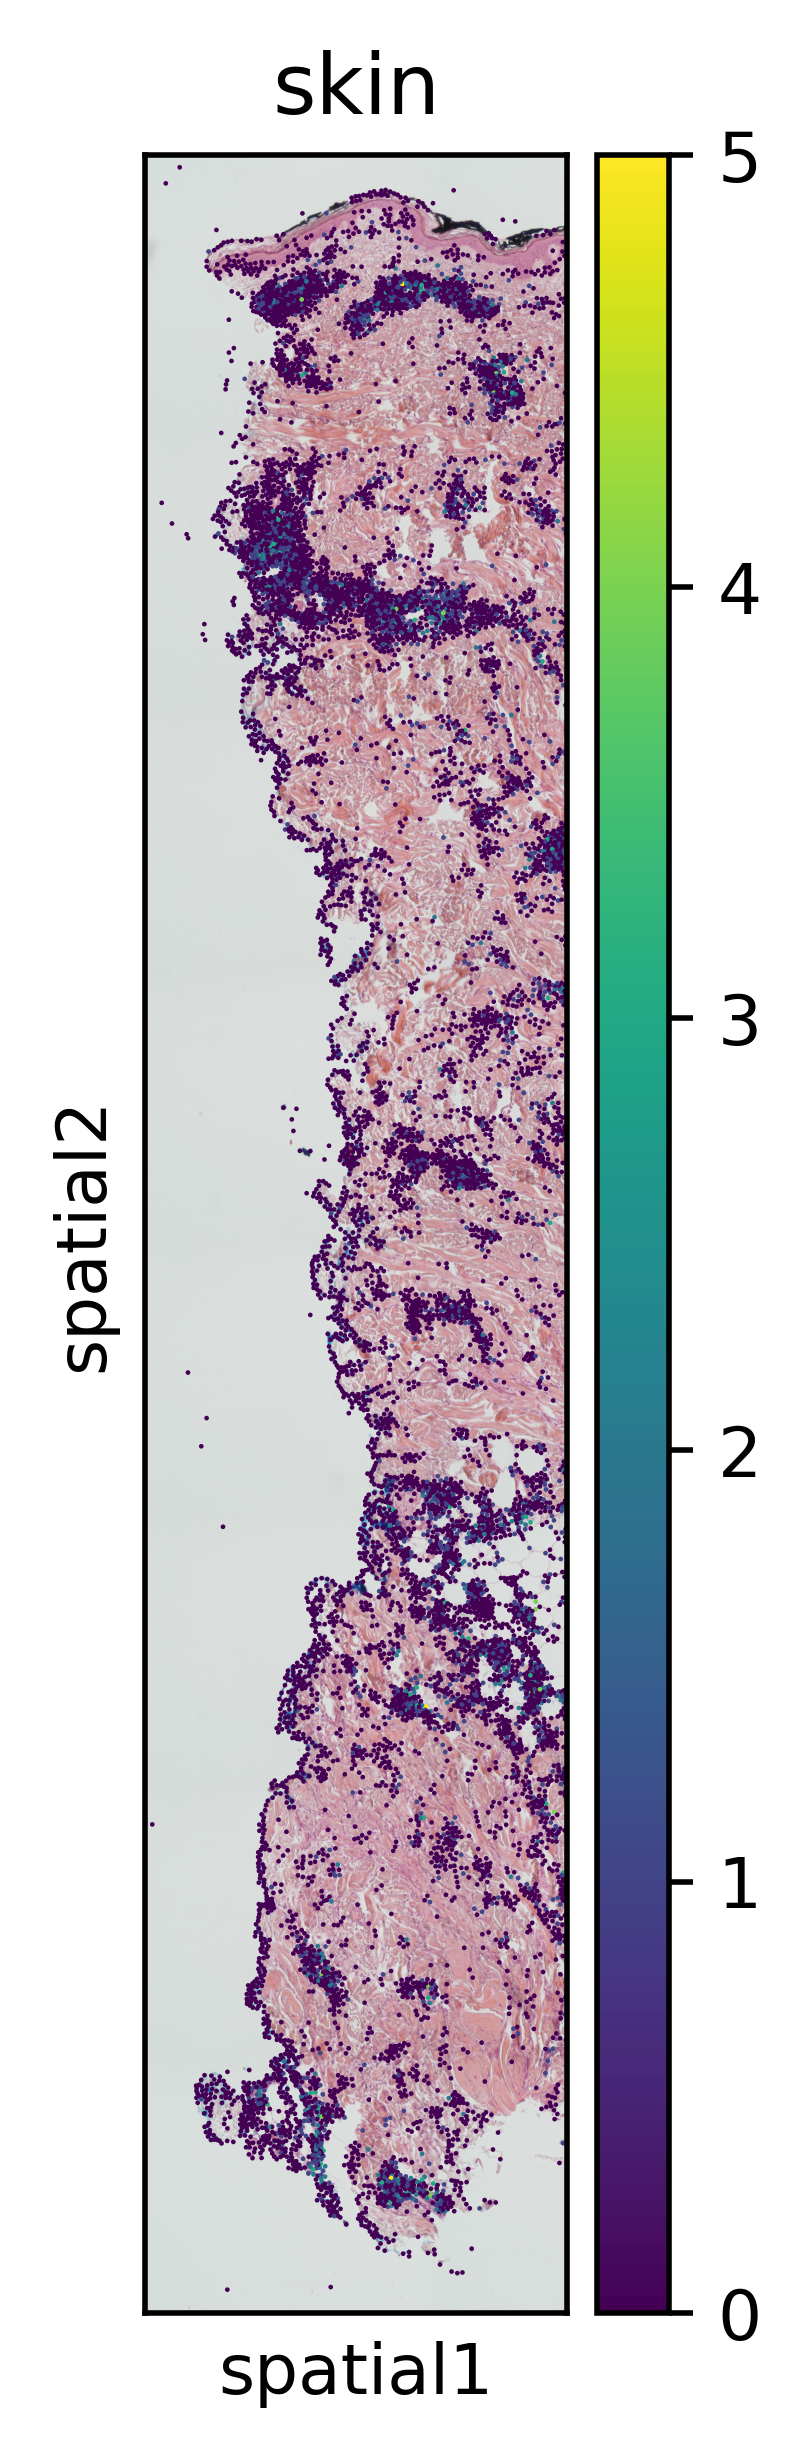

In [37]:
import squidpy as sq
sq.pl.spatial_scatter(ad_ref_skin, color="CD3D", title=f"skin", dpi=500, crop_coord= (0, 0, 3000,30000))